# S004 — Ransomware Detection System (V8.4 Research-Hardened EDR)

This notebook includes the V8.4 reporting, hard-benign, calibration, reproducibility, and demo-readiness fixes.

## 0 — Environment Setup

In [79]:
import os, sys, warnings, importlib
warnings.filterwarnings('ignore')
import matplotlib
matplotlib.use('Agg')          # headless backend — prevents display errors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image
import numpy  as np
import pandas as pd
import seaborn as sns
import optuna
from collections import Counter

# ── Project root ──────────────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.abspath('')
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
SRC_DIR      = os.path.join(PROJECT_ROOT, 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print('Project root:', PROJECT_ROOT)

# ── Reload all modules so edits take effect without restarting kernel ─────────
import src.config
import src.utils
import src.models.data_loader
import src.models.random_forest_model
import src.models.isolation_forest_model
import src.models.autoencoder_model
import src.models.ensemble_model
import src.engine.system_event
import src.evaluate
for mod in [src.config, src.utils, src.models.data_loader,
            src.models.random_forest_model, src.models.isolation_forest_model,
            src.models.autoencoder_model, src.models.ensemble_model,
            src.engine.system_event, src.evaluate]:
    importlib.reload(mod)

from src.config import (
    CICMALMEM_PATHS, PLOTS_DIR, MODELS_DIR, REPORTS_DIR,
    RANDOM_SEED, TEST_SIZE, VAL_SIZE,
    RF_CONFIG, XGB_CONFIG, LGB_CONFIG, IF_CONFIG, AE_CONFIG,
)
from src.utils  import set_seed, Timer, check_class_balance
from src.models.data_loader import (
    load_cicmalmem, get_benign_mask, get_category_series, engineer_features
)
from src.models.random_forest_model    import RansomwareRandomForest
from src.models.isolation_forest_model import RansomwareIsolationForest
from src.models.autoencoder_model      import RansomwareAutoencoder
from src.models.ensemble_model         import RansomwareXGBoost, RansomwareLightGBM, RansomwareEnsemble
from src.engine.system_event           import (
    SystemEvent, make_rule_engine_event,
    SEVERITY_CRITICAL, ACTION_KILL_PROCESS, ACTION_SEND_ALERT
)
from src.evaluate import (
    security_metrics, build_comparison_table,
    plot_combined_curves, plot_threshold_sensitivity,
    run_ablation, build_latex_table, save_results_json
)


# ── Layer 2 — Dynamic CNN imports ─────────────────────────────────────────────
import src.models.cnn_preprocessor
import src.models.cnn_model
import src.engine.edr_orchestrator
for _mod in [src.models.cnn_preprocessor,
             src.models.cnn_model,
             src.engine.edr_orchestrator]:
    importlib.reload(_mod)

from src.models.cnn_preprocessor import (
    preprocess_dynamic_telemetry, discover_raw_csvs, CNN_FEATURE_COLS,
    is_hard_benign_path, HARD_BENIGN_FILENAMES,
)
from src.models.cnn_model    import RansomwareCNN
from src.engine.edr_orchestrator import EDROrchestrator
from src.engine.system_event import (
    SEVERITY_NONE, SEVERITY_MEDIUM, SEVERITY_HIGH, SEVERITY_CRITICAL,
    ACTION_NO_ACTION, ACTION_LOG_EVENT, ACTION_KILL_PROCESS,
    ACTION_SEND_ALERT,
)

os.makedirs(PLOTS_DIR,   exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

set_seed(RANDOM_SEED)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
sns.set_palette('husl')

def show(path):
    """Display a saved PNG in the notebook."""
    if os.path.exists(path):
        display(Image(filename=path))
    else:
        print(f'[show] File not found: {path}')

print('\n✓ Environment ready.')
print(f'  NumPy  {np.__version__}  |  Pandas {pd.__version__}')

Project root: d:\School Shit\Semester 6\Security\Project\Ransomware-Detection-and-Mitigation-System

✓ Environment ready.
  NumPy  2.2.6  |  Pandas 2.3.3


## 1 — Data Loading & Exploration

In [80]:
# ── Verify dataset paths ──────────────────────────────────────────────────────
print('Checking dataset paths:')
for p in CICMALMEM_PATHS:
    exists = os.path.exists(p)
    size   = f'{os.path.getsize(p)/1e6:.1f} MB' if exists else 'MISSING'
    print(f'  {"✓" if exists else "✗"}  {os.path.basename(p):<30} {size}')

Checking dataset paths:
  ✓  MalMem2022.csv                 19.6 MB
  ✓  Output1.csv                    0.1 MB
  ✓  output2.csv                    0.1 MB
  ✓  output3.csv                    0.2 MB


In [81]:
# ── Load data with feature engineering ───────────────────────────────────────
print('Loading CIC-MalMem2022 with feature engineering...')
with Timer('Data loading + engineering'):
    X, y = load_cicmalmem(
        file_paths   = CICMALMEM_PATHS,
        verbose      = True,
        add_features = True,
    )
    benign_mask = get_benign_mask(file_paths=CICMALMEM_PATHS)
    categories  = get_category_series(file_paths=CICMALMEM_PATHS)

# Raw features only (for ablation)
raw_cols = [c for c in X.columns if not c.startswith('feat_')]
X_raw    = X[raw_cols].copy()

print(f'\nFinal dataset shape : {X.shape}')
print(f'Raw features        : {len(raw_cols)}')
print(f'Engineered features : {X.shape[1] - len(raw_cols)}')
print(f'Total features      : {X.shape[1]}')
print(f'Benign rows         : {int(benign_mask.sum()):,}  (used for IF + AE training only)')

stats = check_class_balance(y, 'CIC-MalMem2022')

Loading CIC-MalMem2022 with feature engineering...
[DataLoader] Loaded MalMem2022.csv: 58,596 rows | {'Benign': 29298, 'Spyware-Transponder': 2410, 'Spyware-Gator': 2200, 'Ransomware-Shade': 2128, 'Spyware-CWS': 2000, 'Trojan-Scar': 2000, 'Spyware-180solutions': 2000, 'Ransomware-Ako': 2000, 'Trojan-Refroso': 2000, 'Ransomware-Conti': 1988, 'Trojan-Emotet': 1967, 'Ransomware-Maze': 1958, 'Trojan-Zeus': 1950, 'Ransomware-Pysa': 1717, 'Trojan-Reconyc': 1570, 'Spyware-TIBS': 1410}
[DataLoader] Loaded Output1.csv: 150 rows | {'Spyware': 150}
[DataLoader] Loaded output2.csv: 350 rows | {'Spyware': 350}
[DataLoader] Loaded output3.csv: 350 rows | {'Spyware': 350}

[DataLoader] ── Combined Dataset ─────────────────────────
  Total samples     : 59,446
  Ransomware  (y=1) : 9,791  (16.5%)
  Other       (y=0) : 49,655  (83.5%)
  Imbalance ratio   : 5.1:1
  Raw features      : 55
  Total features    : 69  (raw + 15 engineered)
[Timer] Data loading + engineering: 1.50s

Final dataset shape : (594

In [82]:
# Fixed label breakdown — Pandas 3.0 compatible
print('Multi-class breakdown (from Category column):')
print(categories.value_counts().to_string())
print()
# Fix: use np.where instead of .map() for Pandas 3.0 compatibility
label_series = pd.Series(np.where(y == 1, 'Ransomware (1)', 'Non-Ransomware (0)'),
                          index=y.index)
print('Binary labels for training:')
print(label_series.value_counts().to_string())
print(f'\nConfirmed: {int(y.sum()):,} ransomware, {int((y==0).sum()):,} non-ransomware')

Multi-class breakdown (from Category column):
Benign                  29298
Spyware-Transponder      2410
Spyware-Gator            2200
Ransomware-Shade         2128
Ransomware-Ako           2000
Spyware-CWS              2000
Trojan-Scar              2000
Trojan-Refroso           2000
Spyware-180solutions     2000
Ransomware-Conti         1988
Trojan-Emotet            1967
Ransomware-Maze          1958
Trojan-Zeus              1950
Ransomware-Pysa          1717
Trojan-Reconyc           1570
Spyware-TIBS             1410
Spyware                   850

Binary labels for training:
Non-Ransomware (0)    49655
Ransomware (1)         9791

Confirmed: 9,791 ransomware, 49,655 non-ransomware


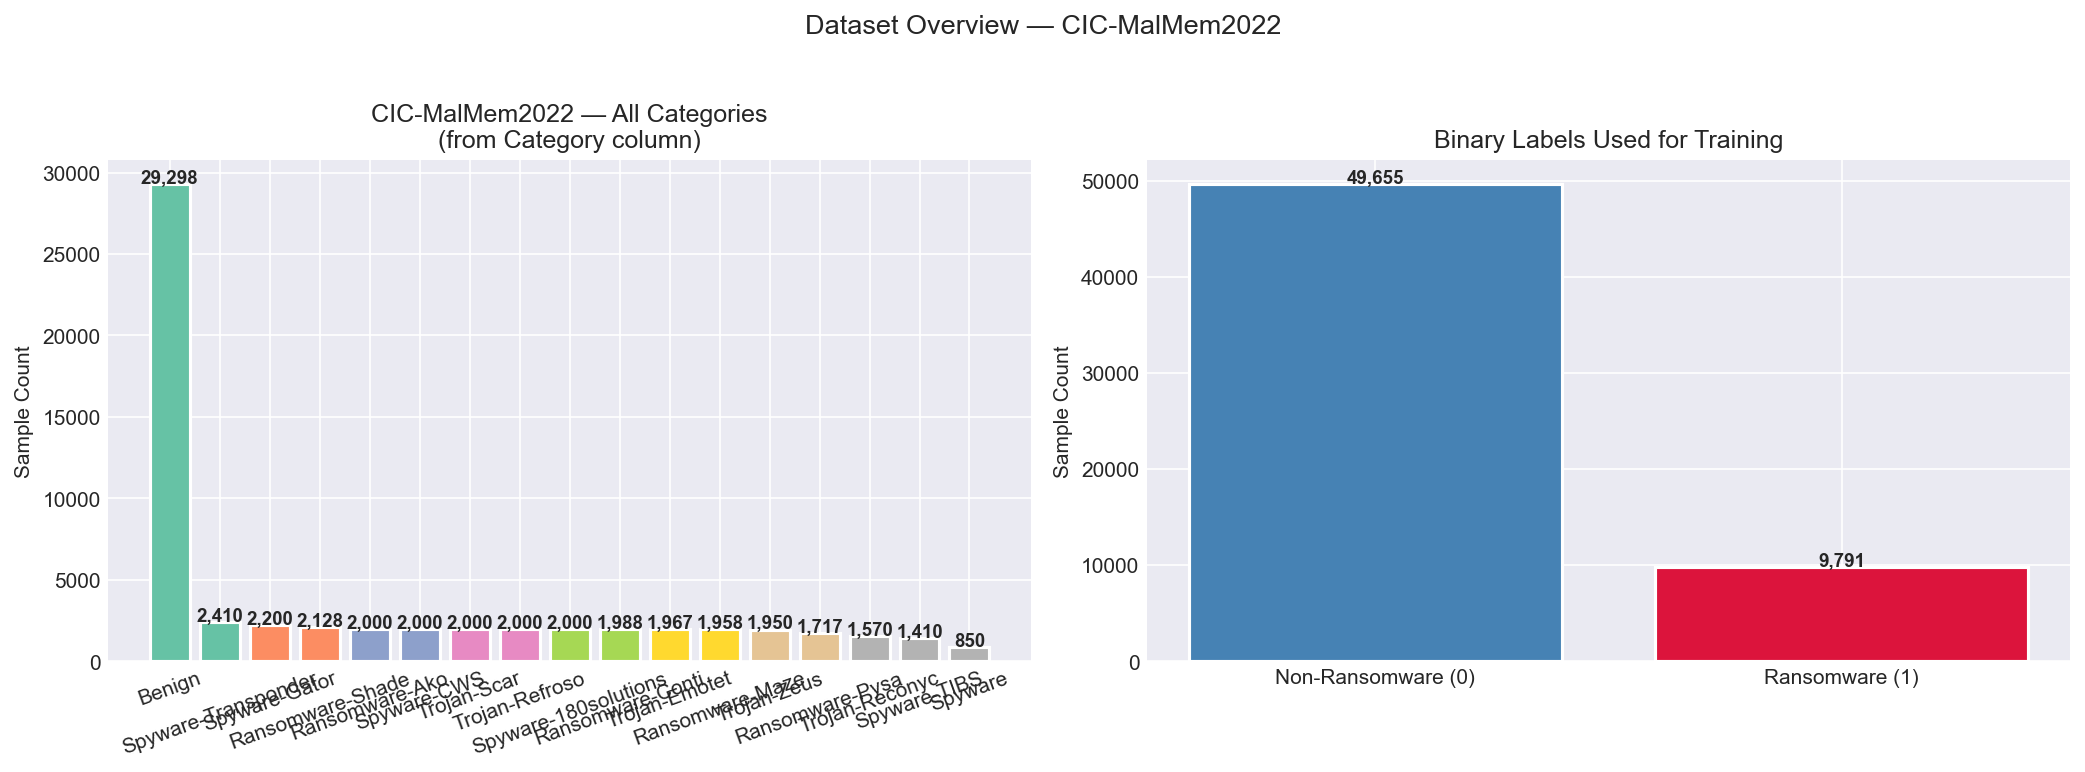

In [83]:
# ── Class distribution plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cc = categories.value_counts()
axes[0].bar(cc.index, cc.values,
            color=plt.cm.Set2(np.linspace(0, 1, len(cc))),
            edgecolor='white', linewidth=1.5)
axes[0].set_title('CIC-MalMem2022 — All Categories\n(from Category column)', fontsize=12)
axes[0].set_ylabel('Sample Count')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(cc.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

bc = Counter(y)
axes[1].bar(['Non-Ransomware (0)', 'Ransomware (1)'],
            [bc[0], bc[1]], color=['steelblue','crimson'],
            edgecolor='white', linewidth=1.5)
axes[1].set_title('Binary Labels Used for Training', fontsize=12)
axes[1].set_ylabel('Sample Count')
for i, v in enumerate([bc[0], bc[1]]):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Dataset Overview — CIC-MalMem2022', fontsize=13, y=1.02)
plt.tight_layout()
plot_path = os.path.join(PLOTS_DIR, 'class_distribution.png')
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
show(plot_path)

In [84]:
# Fixed: compute mean differences explicitly
ransomware_mean = X[y == 1].mean()
other_mean      = X[y == 0].mean()
diff = (ransomware_mean - other_mean).abs().sort_values(ascending=False)

print('Top 15 most discriminative features (|mean_ransomware - mean_other|):')
print(diff.head(15).round(4).to_string())
top6 = diff.head(6).index.tolist()

Top 15 most discriminative features (|mean_ransomware - mean_other|):
handles.nhandles                2045.0381
malfind.commitCharge            1221.8717
handles.nevent                   810.7954
dlllist.ndlls                    309.1719
handles.nthread                  242.2726
handles.nsection                 139.4146
handles.nkey                     120.8167
handles.nsemaphore                80.5745
handles.nmutant                   73.0121
handles.nfile                     70.3467
feat_inject_x_hidden              65.8984
feat_handles_per_proc             44.8472
pslist.avg_handlers               44.3298
handles.avg_handles_per_proc      42.4258
malfind.protection                21.9005


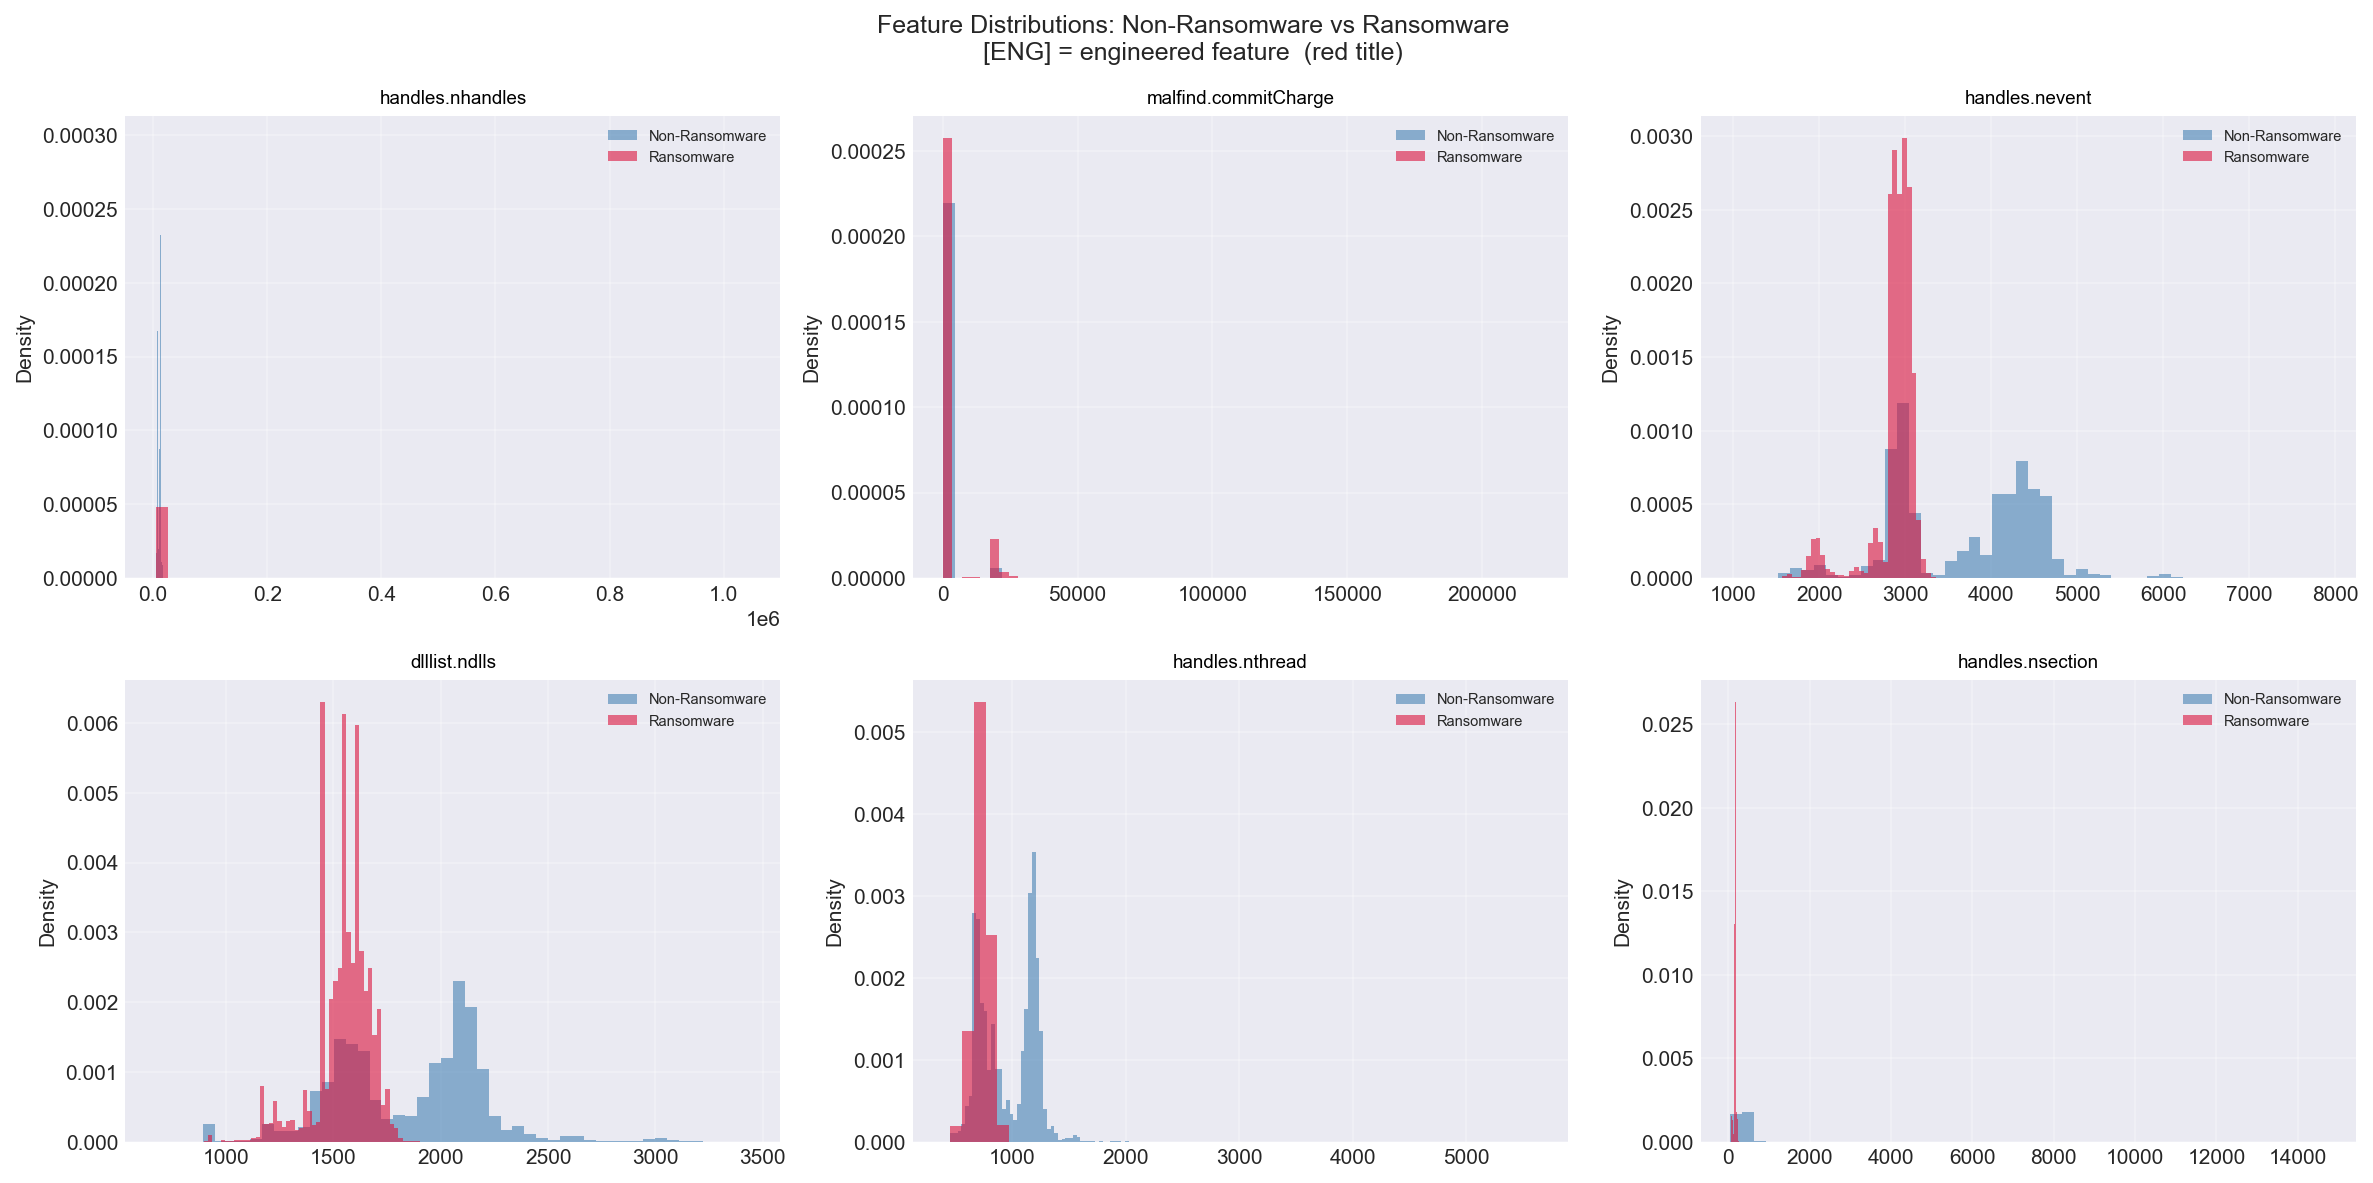

In [85]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(top6):
    ax = axes[i]
    color = '#e74c3c' if feat.startswith('feat_') else '#2980b9'
    ax.hist(X.loc[y==0, feat], bins=50, alpha=0.6, color='steelblue',
            label=f'Non-Ransomware', density=True)
    ax.hist(X.loc[y==1, feat], bins=50, alpha=0.6, color='crimson',
            label=f'Ransomware', density=True)
    prefix = '[ENG] ' if feat.startswith('feat_') else ''
    ax.set_title(f'{prefix}{feat}', fontsize=9,
                 color='#c0392b' if feat.startswith('feat_') else 'black')
    ax.legend(fontsize=7); ax.set_ylabel('Density'); ax.grid(alpha=0.3)

plt.suptitle('Feature Distributions: Non-Ransomware vs Ransomware\n'
             '[ENG] = engineered feature  (red title)', fontsize=12)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'feature_distributions.png')
fig.savefig(p, dpi=150, bbox_inches='tight'); plt.close(fig)
show(p)

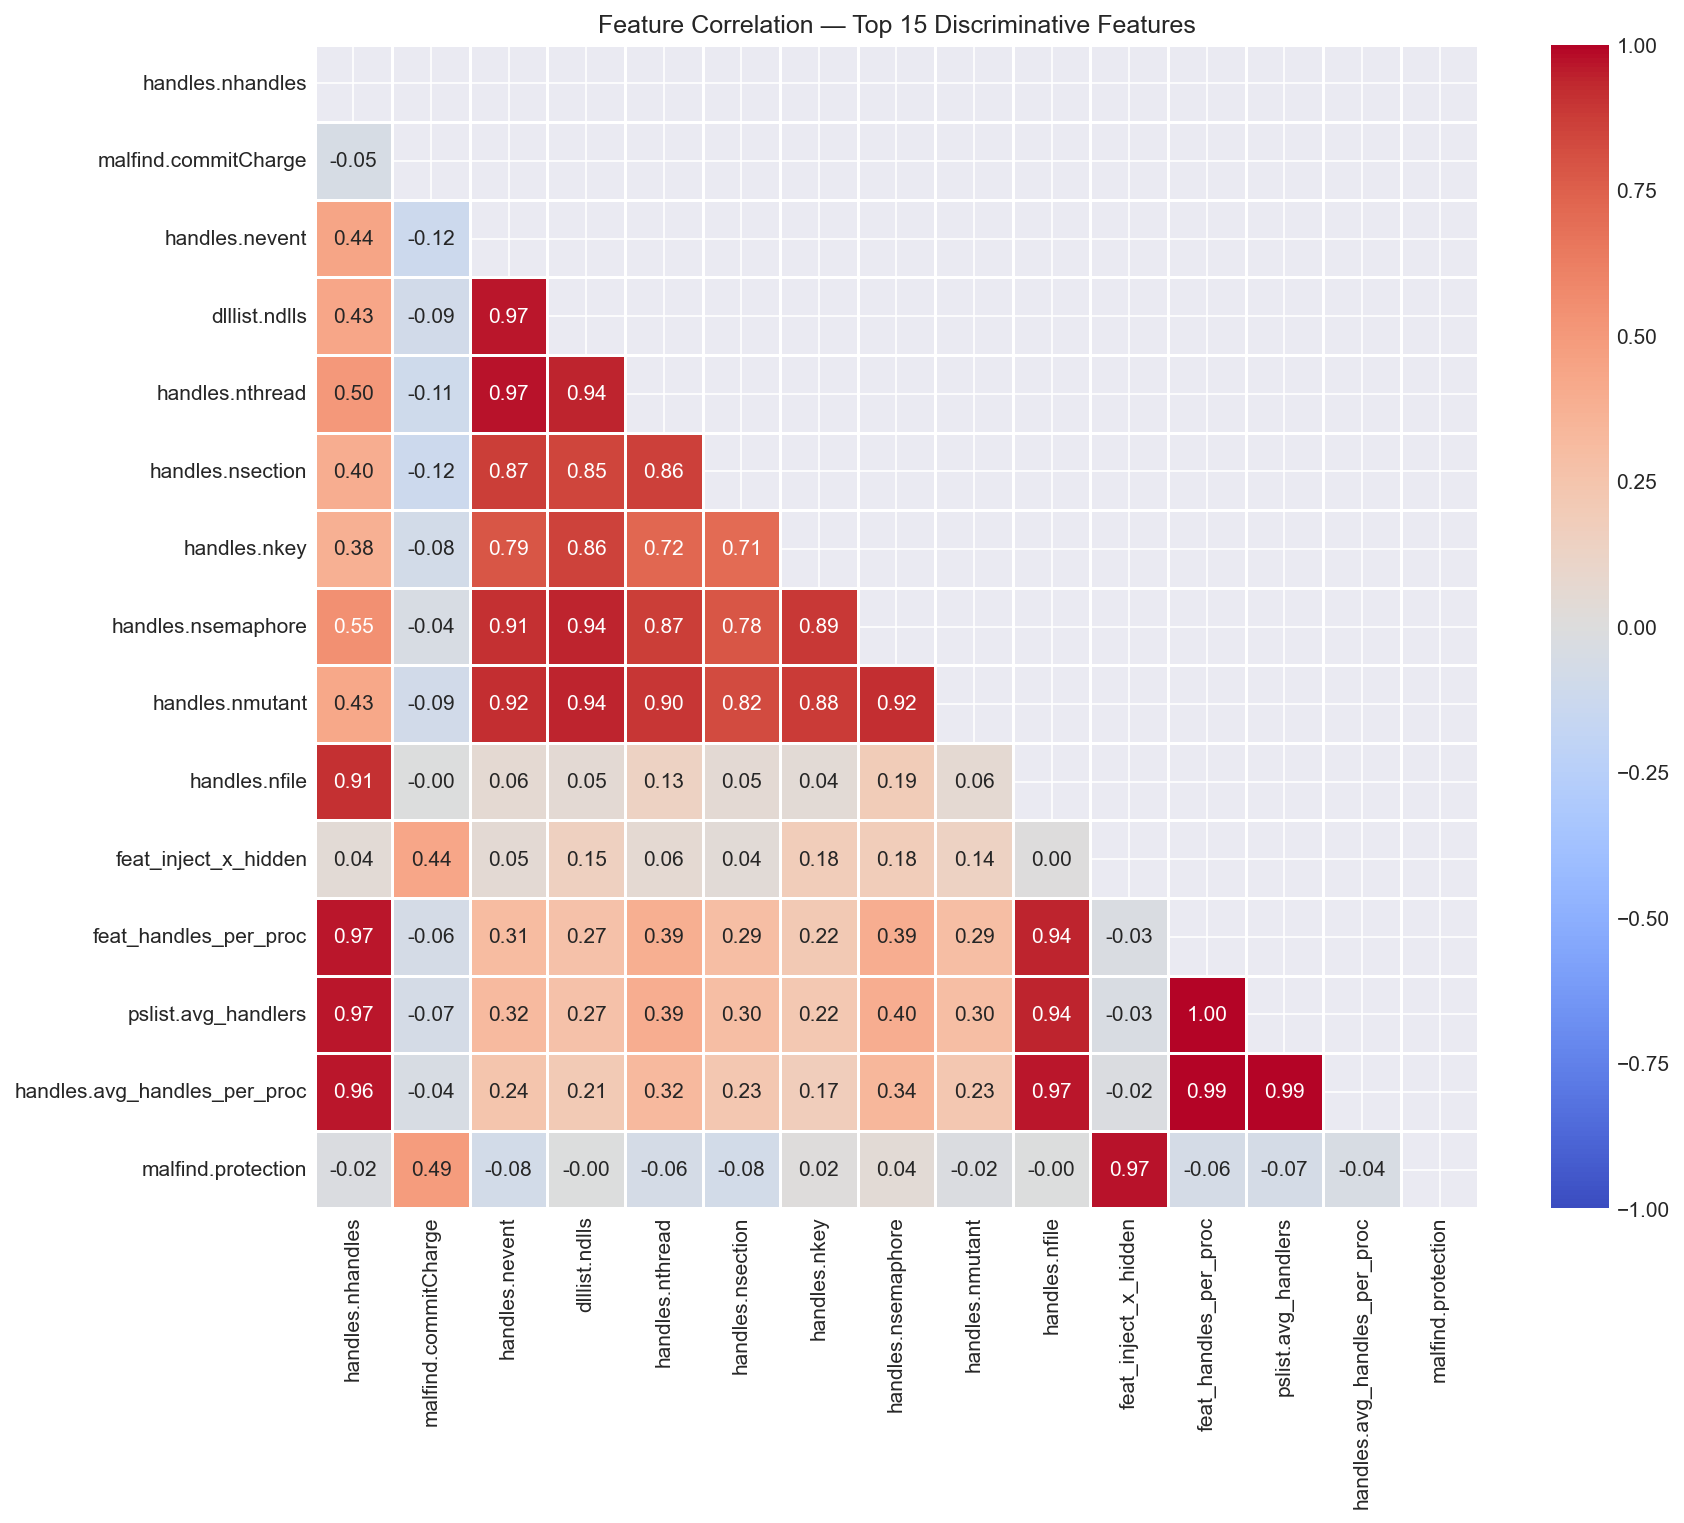

In [86]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
top15 = diff.head(15).index.tolist()
corr  = X[top15].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation — Top 15 Discriminative Features', fontsize=12)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'correlation_heatmap.png')
fig.savefig(p, dpi=150, bbox_inches='tight'); plt.close(fig)
show(p)

## 2 — Random Forest (Recall-Optimised)

In [87]:
print('='*60)
print('RANDOM FOREST — Supervised | Recall target ≥ 90%')
print('Fix: threshold tuned for recall, NOT F1')
print('Fix: isotonic probability calibration added')
print('='*60)

rf = RansomwareRandomForest(**RF_CONFIG)
rf.feature_names = list(X.columns)

with Timer('RF training'):
    rf_results = rf.train(X, y, test_size=TEST_SIZE, val_size=VAL_SIZE)

print(f'\n✓ RF complete')
print(f'  Recall    : {rf_results["recall"]:.4f}  (target ≥ 0.90)')
print(f'  Precision : {rf_results["precision"]:.4f}')
print(f'  F1        : {rf_results["f1"]:.4f}')
print(f'  ROC-AUC   : {rf_results["roc_auc"]:.4f}')
print(f'  Miss Rate : {rf_results["miss_rate"]:.4f}  (fraction of ransomware missed)')
print(f'  Threshold : {rf.threshold:.4f}  (recall-optimised, NOT default 0.5)')

meets = rf_results['recall'] >= 0.90
print(f'\n  {"✓ MEETS" if meets else "✗ BELOW"} recall target')

RANDOM FOREST — Supervised | Recall target ≥ 90%
Fix: threshold tuned for recall, NOT F1
Fix: isotonic probability calibration added

════════════════════════════════════════════════════════════
  RANDOM FOREST — TRAINING PIPELINE
════════════════════════════════════════════════════════════

[RF] Train : 35,667 (5,875 ransomware, 29,792 other)
[RF] Val   : 11,889
[RF] Test  : 11,890
[RF] Before SMOTE: Counter({0: 29792, 1: 5875})
[RF] After  SMOTE: Counter({0: 29792, 1: 29792})

[RF] Training RandomForest (500 trees)...
[RF] OOB Score      : 0.9484
[RF] Calibrating probabilities (isotonic)...

[RF] Threshold sweep (target recall ≥ 90%):
    Thresh    Recall   Precision        F1
      0.05    0.9867      0.4007    0.5700 ← selected
      0.10    0.9494      0.4932    0.6492 ← selected
      0.15    0.9392      0.5076    0.6590 ← selected
      0.20    0.8902      0.5720    0.6965
      0.35    0.8315      0.6427    0.7250
[RF] Recall target  : 90%
[RF] Optimal thresh : 0.1600

[RF] ── 

RANDOM FOREST — TUNED (Optuna best params)
Best CV recall: 97.88%  |  50 trials

════════════════════════════════════════════════════════════
  RANDOM FOREST — TRAINING PIPELINE
════════════════════════════════════════════════════════════

[RF] Train : 35,667 (5,875 ransomware, 29,792 other)
[RF] Val   : 11,889
[RF] Test  : 11,890
[RF] Before SMOTE: Counter({0: 29792, 1: 5875})
[RF] After  SMOTE: Counter({0: 29792, 1: 29792})

[RF] Training RandomForest (222 trees)...
[RF] OOB Score      : 0.9412
[RF] Calibrating probabilities (isotonic)...

[RF] Threshold sweep (target recall ≥ 90%):
    Thresh    Recall   Precision        F1
      0.05    0.9811      0.4265    0.5946 ← selected
      0.10    0.9663      0.4586    0.6220 ← selected
      0.15    0.9280      0.5152    0.6625 ← selected
      0.20    0.8749      0.5905    0.7051
      0.35    0.7503      0.6979    0.7231
[RF] Recall target  : 90%
[RF] Optimal thresh : 0.1500

[RF] ── TEST SET ─────────────────────────────────────
      

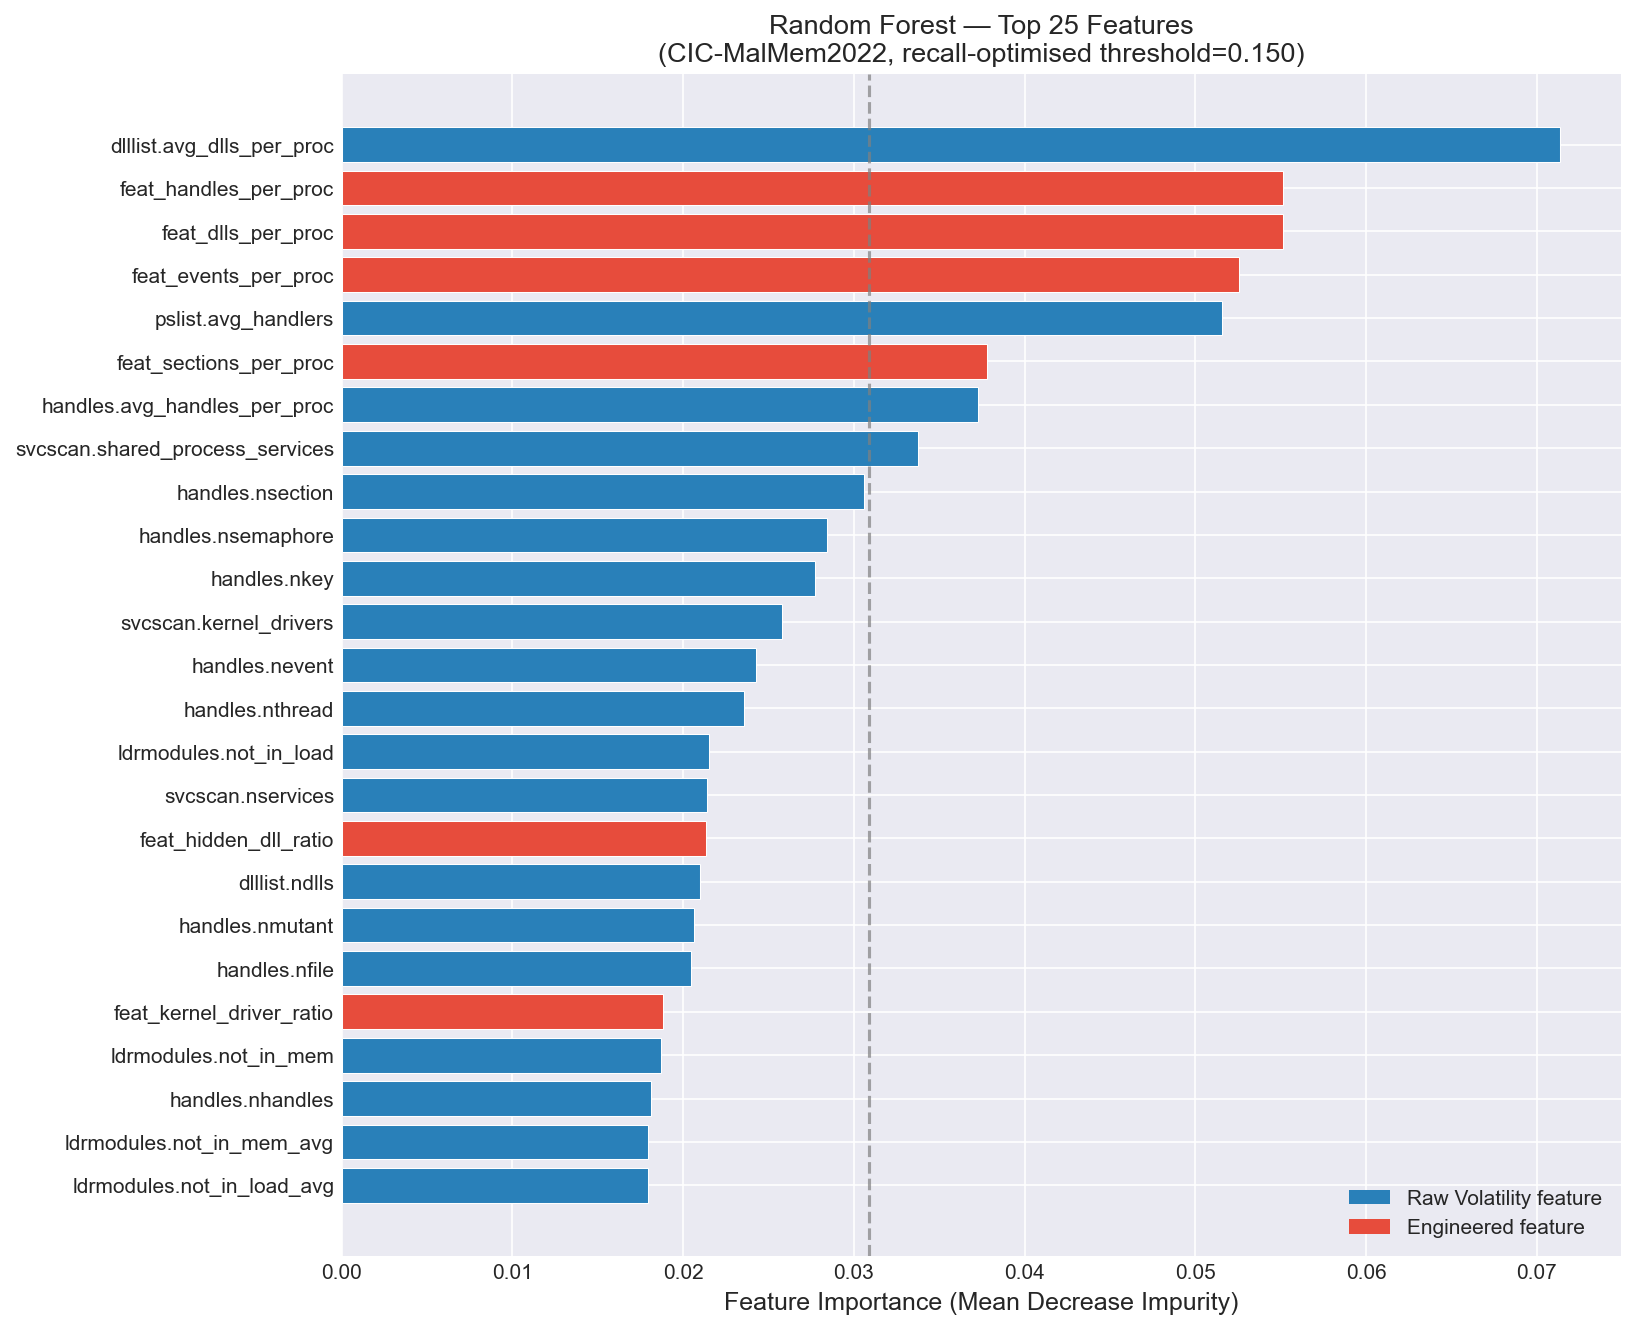

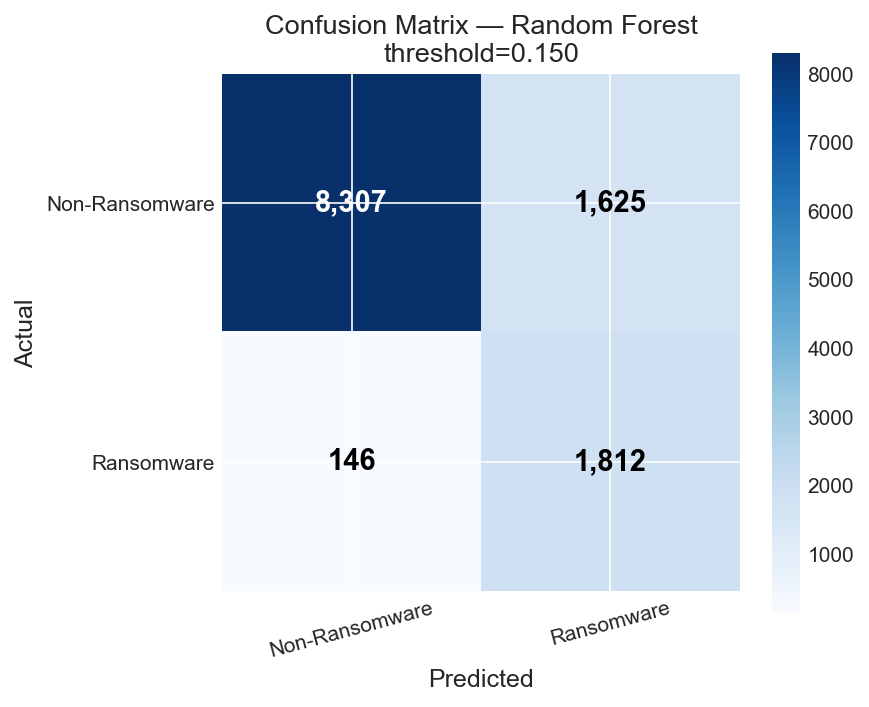

[RF] Saved model  → d:\School Shit\Semester 6\Security\Project\Ransomware-Detection-and-Mitigation-System\saved_models\random_forest_tuned.pkl
[RF] Saved scaler → d:\School Shit\Semester 6\Security\Project\Ransomware-Detection-and-Mitigation-System\saved_models\rf_tuned_scaler.pkl
Tuned RF saved.


In [88]:
# ── STEP 1: Retrain RF with Optuna-tuned hyperparameters ─────────────────────
print('='*60)
print('RANDOM FOREST — TUNED (Optuna best params)')
print('Best CV recall: 97.88%  |  50 trials')
print('='*60)

# Tuned config — overrides default RF_CONFIG
TUNED_RF_CONFIG = {
    'n_estimators'      : 222,    # tuned (was 500)
    'max_depth'         : 20,     # tuned (was None) ← key change
    'min_samples_split' : 2,      # tuned (was 4)
    'min_samples_leaf'  : 1,      # tuned (was 2)
    'max_features'      : 'sqrt', # same
    'recall_target'     : 0.90,
    'use_smote'         : True,
    'calibrate'         : True,
    'random_state'      : 42,
}

rf_tuned = RansomwareRandomForest(**TUNED_RF_CONFIG)
rf_tuned.feature_names = list(X.columns)

with Timer('RF tuned training'):
    rf_tuned_results = rf_tuned.train(X, y, test_size=TEST_SIZE, val_size=VAL_SIZE)

print(f'\n✓ Tuned RF complete')
print(f'  Recall    : {rf_tuned_results["recall"]:.4f}  (was 0.9229)')
print(f'  Precision : {rf_tuned_results["precision"]:.4f}  (was 0.5436)')
print(f'  F1        : {rf_tuned_results["f1"]:.4f}  (was 0.6842)')
print(f'  ROC-AUC   : {rf_tuned_results["roc_auc"]:.4f}  (was 0.9536)')
print(f'  Miss Rate : {rf_tuned_results["miss_rate"]:.4f}  (was 0.0771)')
print(f'  Threshold : {rf_tuned.threshold:.4f}')

delta_recall = rf_tuned_results["recall"] - rf_results["recall"]
print(f'\n  Delta vs default RF: {delta_recall:+.4f} recall')

rf_tuned.plot_feature_importance(
    top_n=25,
    save_path=os.path.join(PLOTS_DIR, 'rf_tuned_feature_importance.png')
)
plt.close('all')
show(os.path.join(PLOTS_DIR, 'rf_tuned_feature_importance.png'))

rf_tuned.plot_confusion_matrix(
    save_path=os.path.join(PLOTS_DIR, 'rf_tuned_confusion_matrix.png')
)
plt.close('all')
show(os.path.join(PLOTS_DIR, 'rf_tuned_confusion_matrix.png'))

rf_tuned.save(
    model_path  = os.path.join(MODELS_DIR, 'random_forest_tuned.pkl'),
    scaler_path = os.path.join(MODELS_DIR, 'rf_tuned_scaler.pkl'),
)
print('Tuned RF saved.')

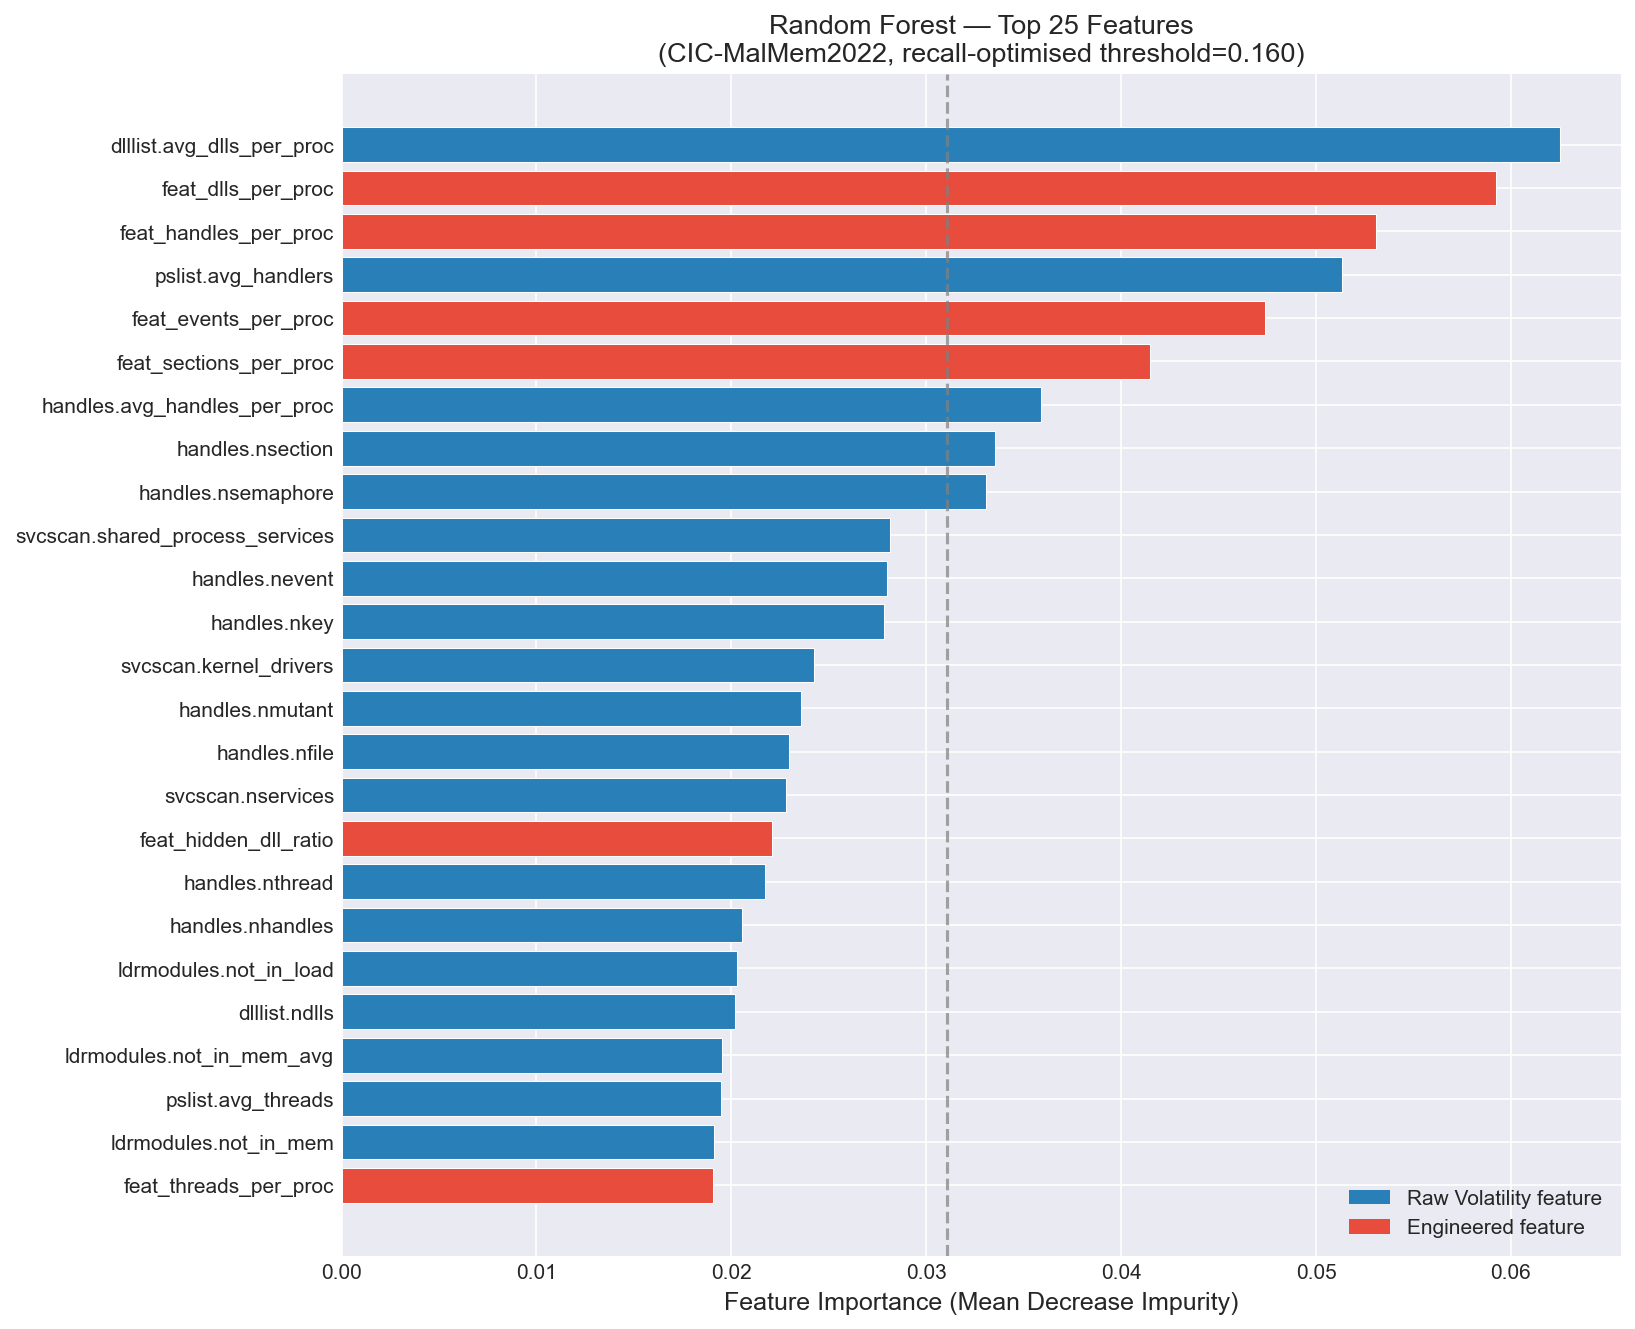


Red bars = engineered features  |  Blue bars = raw Volatility features


In [89]:
rf.plot_feature_importance(top_n=25, save_path=os.path.join(PLOTS_DIR,'rf_feature_importance.png'))
plt.close('all')
show(os.path.join(PLOTS_DIR,'rf_feature_importance.png'))
print('\nRed bars = engineered features  |  Blue bars = raw Volatility features')

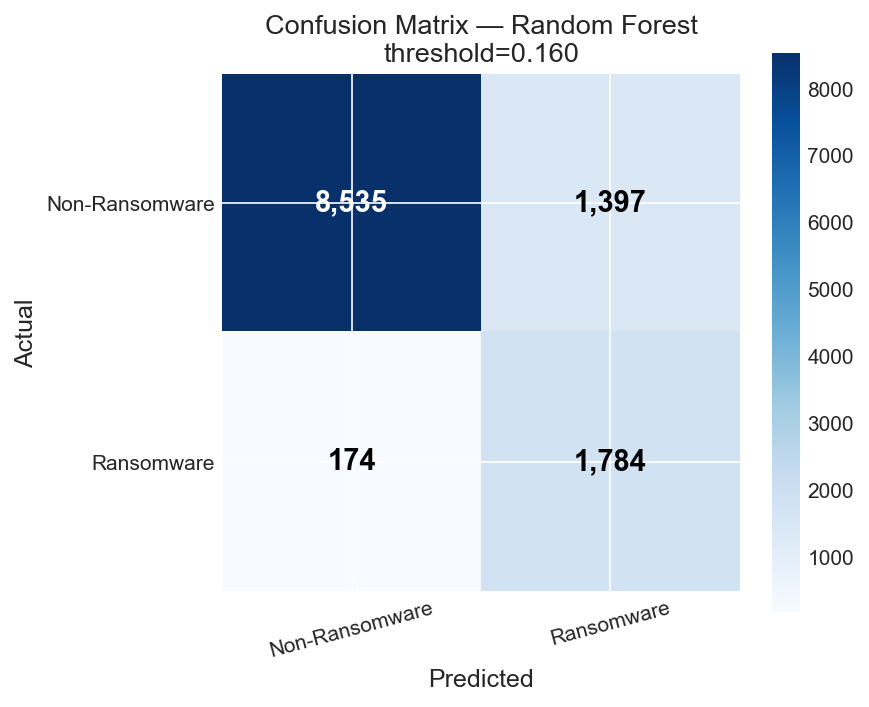


Confusion matrix interpretation:
  True Positives  (ransomware caught)       : 1,784
  False Negatives (ransomware MISSED) ⚠    : 174
  False Positives (false alarms)            : 1,397
  True Negatives  (correct non-ransomware)  : 8,535


In [90]:
rf.plot_confusion_matrix(save_path=os.path.join(PLOTS_DIR,'rf_confusion_matrix.png'))
plt.close('all')
show(os.path.join(PLOTS_DIR,'rf_confusion_matrix.png'))

cm = rf_results['confusion_matrix']
TN,FP,FN,TP = cm[0][0],cm[0][1],cm[1][0],cm[1][1]
print(f'\nConfusion matrix interpretation:')
print(f'  True Positives  (ransomware caught)       : {TP:,}')
print(f'  False Negatives (ransomware MISSED) ⚠    : {FN:,}')
print(f'  False Positives (false alarms)            : {FP:,}')
print(f'  True Negatives  (correct non-ransomware)  : {TN:,}')

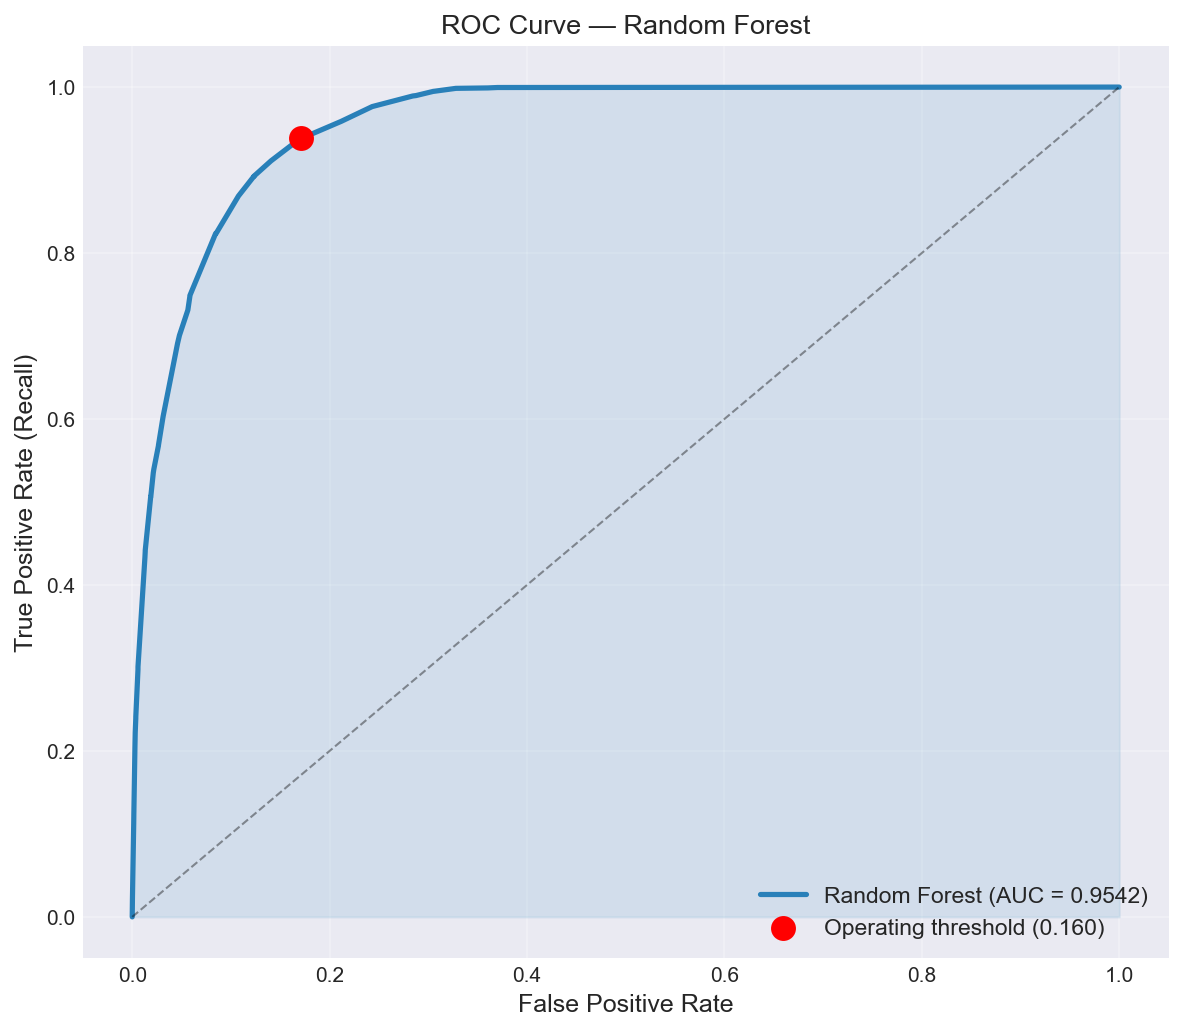

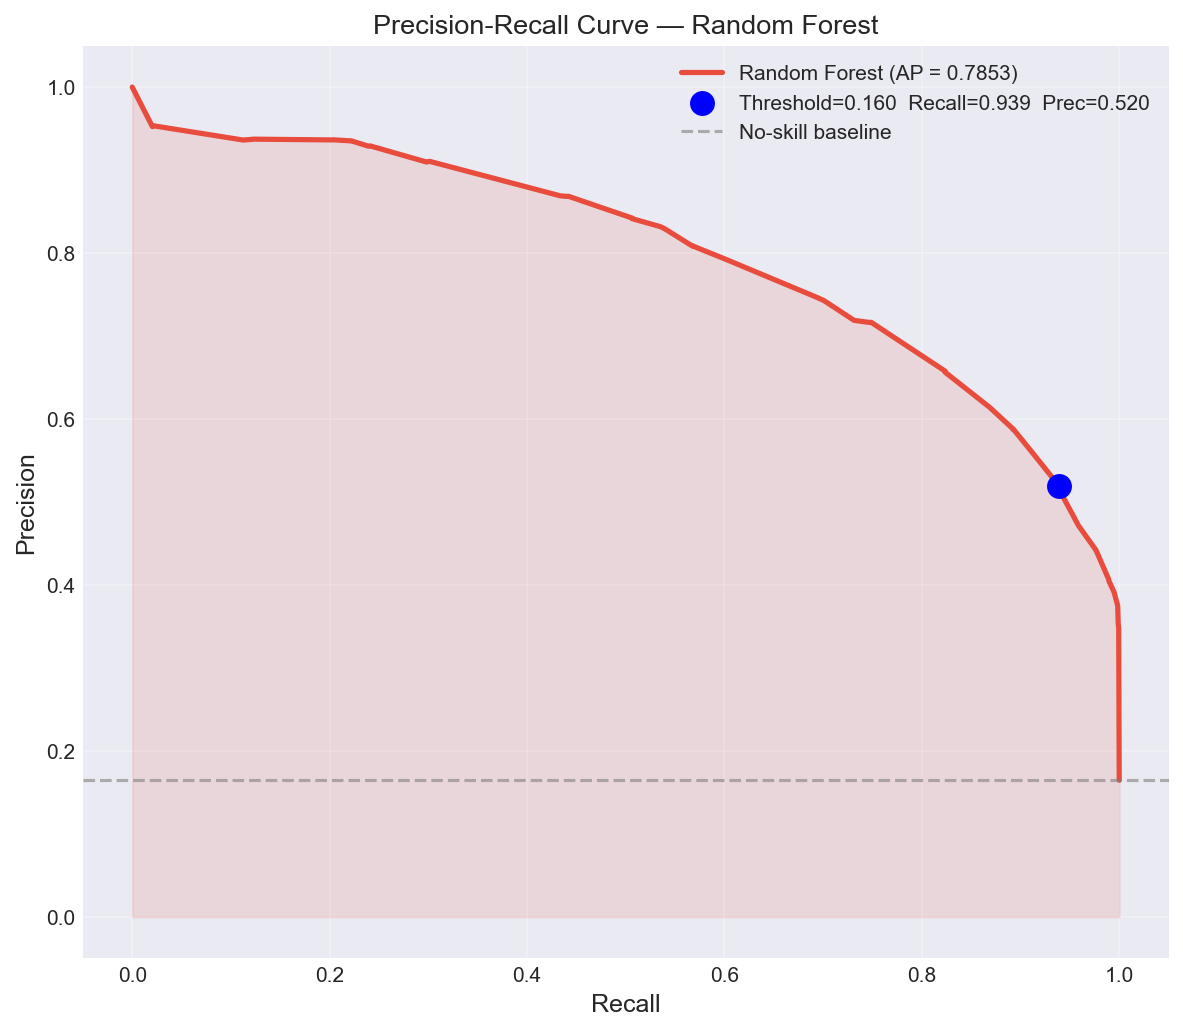

In [91]:
rf.plot_roc_curve(save_path=os.path.join(PLOTS_DIR,'rf_roc_curve.png'))
plt.close('all')
show(os.path.join(PLOTS_DIR,'rf_roc_curve.png'))

rf.plot_precision_recall_curve(save_path=os.path.join(PLOTS_DIR,'rf_pr_curve.png'))
plt.close('all')
show(os.path.join(PLOTS_DIR,'rf_pr_curve.png'))

In [92]:
rf.save(
    model_path  = os.path.join(MODELS_DIR, 'random_forest.pkl'),
    scaler_path = os.path.join(MODELS_DIR, 'rf_scaler.pkl'),
)
print('RF saved.')

[RF] Saved model  → d:\School Shit\Semester 6\Security\Project\Ransomware-Detection-and-Mitigation-System\saved_models\random_forest.pkl
[RF] Saved scaler → d:\School Shit\Semester 6\Security\Project\Ransomware-Detection-and-Mitigation-System\saved_models\rf_scaler.pkl
RF saved.


## 3 — XGBoost

XGBOOST — Supervised | Recall target ≥ 90%
Expected: higher recall than RF on tabular data

════════════════════════════════════════════════════════════
  XGBOOST — TRAINING PIPELINE
════════════════════════════════════════════════════════════
[XGB] Train: 35,667 | Val: 11,889 | Test: 11,890
[XGB] Before SMOTE: Counter({0: 29792, 1: 5875})
[XGB] After SMOTE : Counter({0: 29792, 1: 29792})
[XGB] Training (scale_pos_weight=5.07)...
[XGB] Recall-optimised threshold: 0.2300

[XGB] ── TEST SET ──────────────────────────────────
                precision    recall  f1-score   support

Non-Ransomware     0.9777    0.8649    0.9178      9932
    Ransomware     0.5677    0.8999    0.6962      1958

      accuracy                         0.8706     11890
     macro avg     0.7727    0.8824    0.8070     11890
  weighted avg     0.9102    0.8706    0.8813     11890

  ROC-AUC: 0.9496 | Avg Precision: 0.7682
[Timer] XGB training: 4.12s

✓ XGB complete
  Recall    : 0.8999
  Precision : 0.5677
  F1

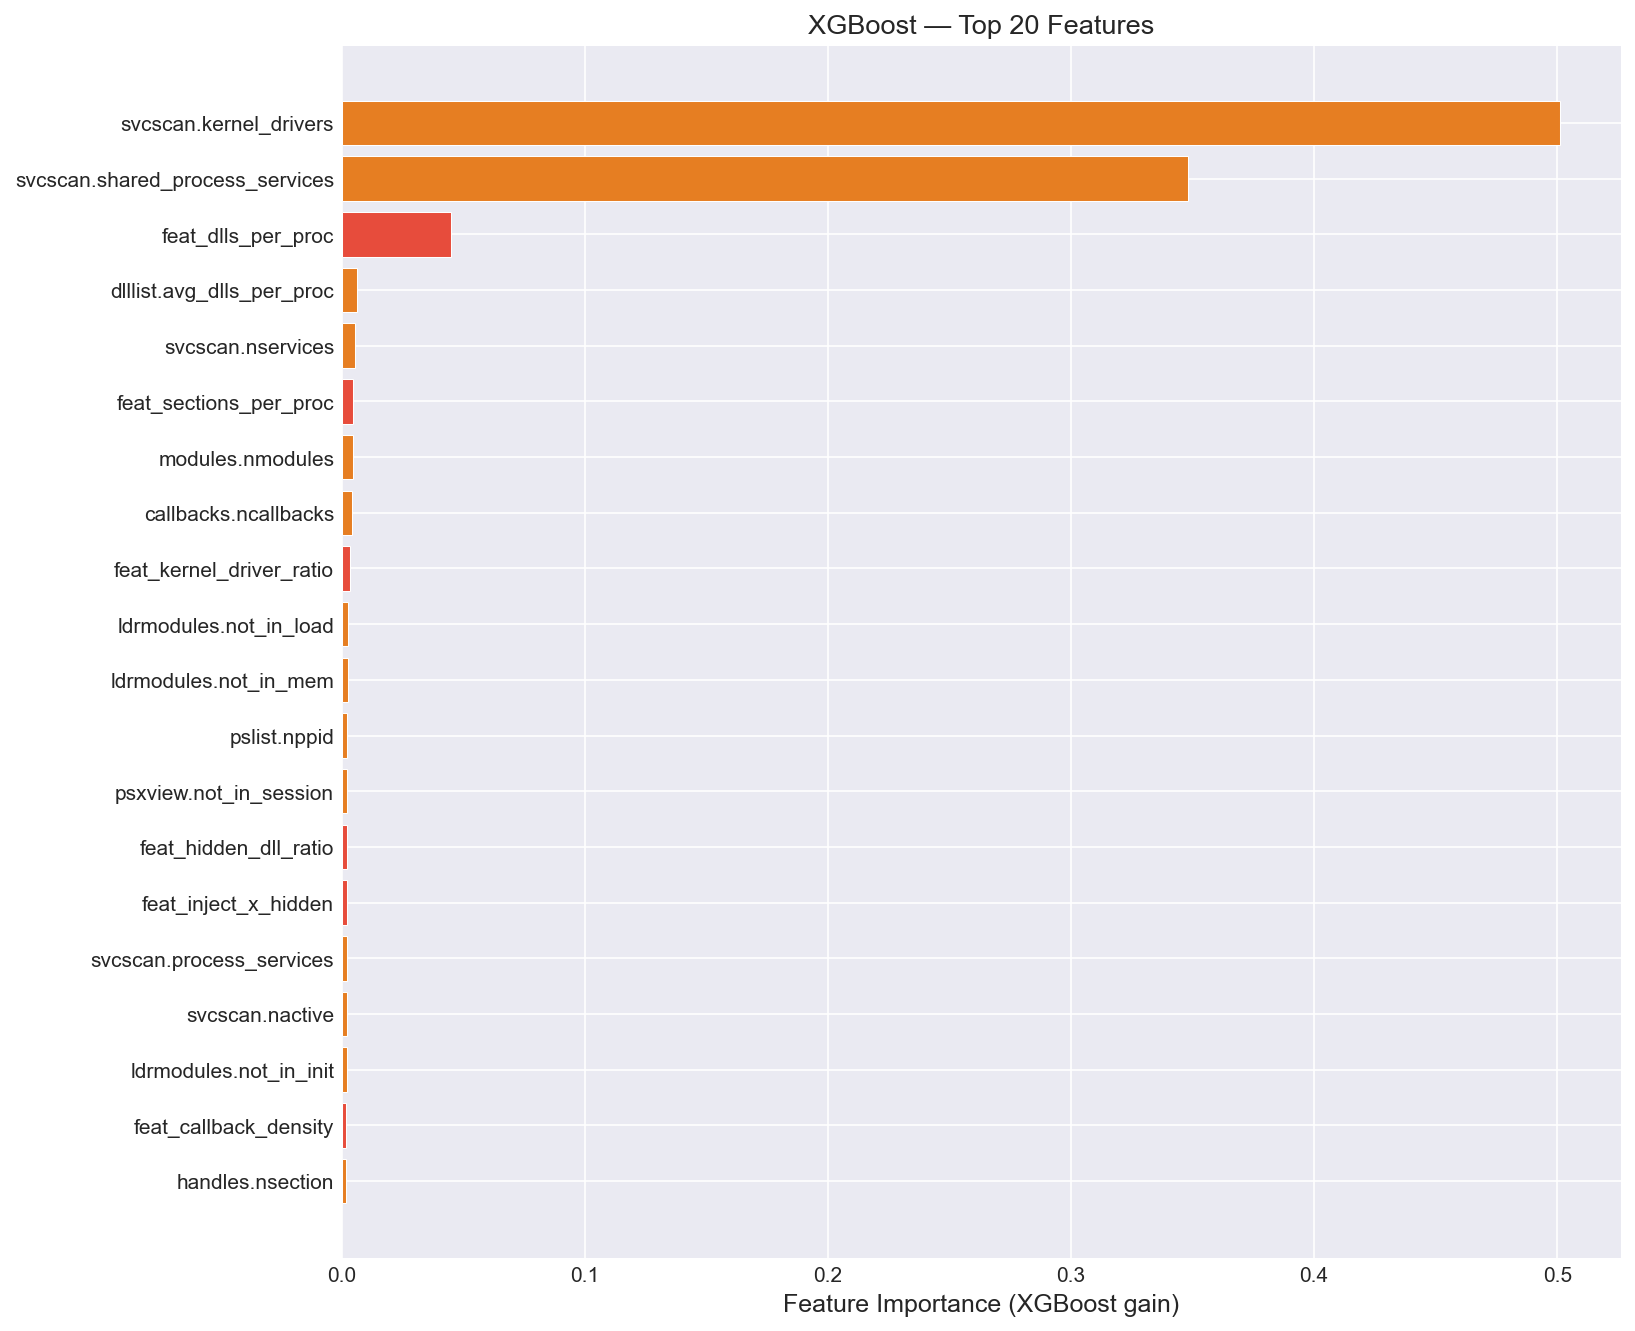

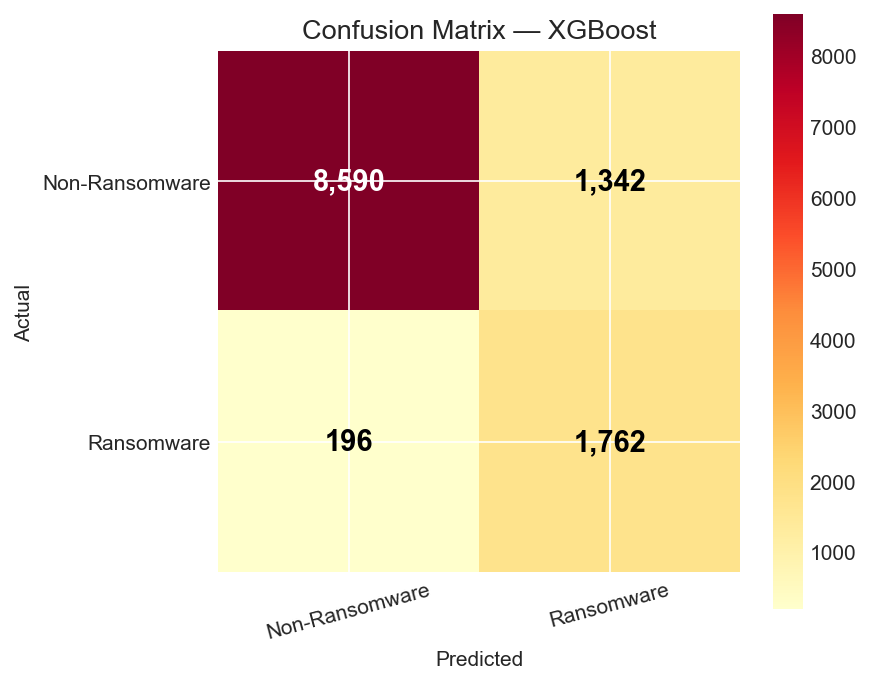

[XGB] Saved → d:\School Shit\Semester 6\Security\Project\Ransomware-Detection-and-Mitigation-System\saved_models\xgboost.pkl


In [93]:
print('='*60)
print('XGBOOST — Supervised | Recall target ≥ 90%')
print('Expected: higher recall than RF on tabular data')
print('='*60)

try:
    xgb_model = RansomwareXGBoost(**XGB_CONFIG)
    xgb_model.feature_names = list(X.columns)

    with Timer('XGB training'):
        xgb_results = xgb_model.train(X, y, test_size=TEST_SIZE, val_size=VAL_SIZE)

    print(f'\n✓ XGB complete')
    print(f'  Recall    : {xgb_results["recall"]:.4f}')
    print(f'  Precision : {xgb_results["precision"]:.4f}')
    print(f'  F1        : {xgb_results["f1"]:.4f}')
    print(f'  ROC-AUC   : {xgb_results["roc_auc"]:.4f}')
    print(f'  Threshold : {xgb_model.threshold:.4f}')

    xgb_model.plot_feature_importance(top_n=20,
        save_path=os.path.join(PLOTS_DIR,'xgb_feature_importance.png'))
    plt.close('all')
    show(os.path.join(PLOTS_DIR,'xgb_feature_importance.png'))

    xgb_model.plot_confusion_matrix(
        save_path=os.path.join(PLOTS_DIR,'xgb_confusion_matrix.png'))
    plt.close('all')
    show(os.path.join(PLOTS_DIR,'xgb_confusion_matrix.png'))

    xgb_model.save(
        path        = os.path.join(MODELS_DIR,'xgboost.pkl'),
        scaler_path = os.path.join(MODELS_DIR,'xgb_scaler.pkl'),
    )
    XGB_OK = True

except ImportError:
    print('XGBoost not installed. Run: pip install xgboost')
    XGB_OK = False
    xgb_results = {}

## 4 — LightGBM

LIGHTGBM — Supervised | Recall target ≥ 90%
Expected: fastest training, competitive recall

════════════════════════════════════════════════════════════
  LIGHTGBM — TRAINING PIPELINE
════════════════════════════════════════════════════════════
[LGB] Train: 35,667 | Val: 11,889 | Test: 11,890
[LGB] Before SMOTE: Counter({0: 29792, 1: 5875})
[LGB] After SMOTE : Counter({0: 29792, 1: 29792})
[LGB] Training LightGBM...
[LGB] Best iteration: 500
[LGB] Recall-optimised threshold: 0.1500

[LGB] ── TEST SET ──────────────────────────────────
                precision    recall  f1-score   support

Non-Ransomware     0.9826    0.8496    0.9113      9932
    Ransomware     0.5477    0.9239    0.6877      1958

      accuracy                         0.8618     11890
     macro avg     0.7652    0.8867    0.7995     11890
  weighted avg     0.9110    0.8618    0.8745     11890

  ROC-AUC: 0.9555 | Avg Precision: 0.8008
[Timer] LGB training: 3.91s

✓ LGB complete
  Recall    : 0.9239
  Precision :

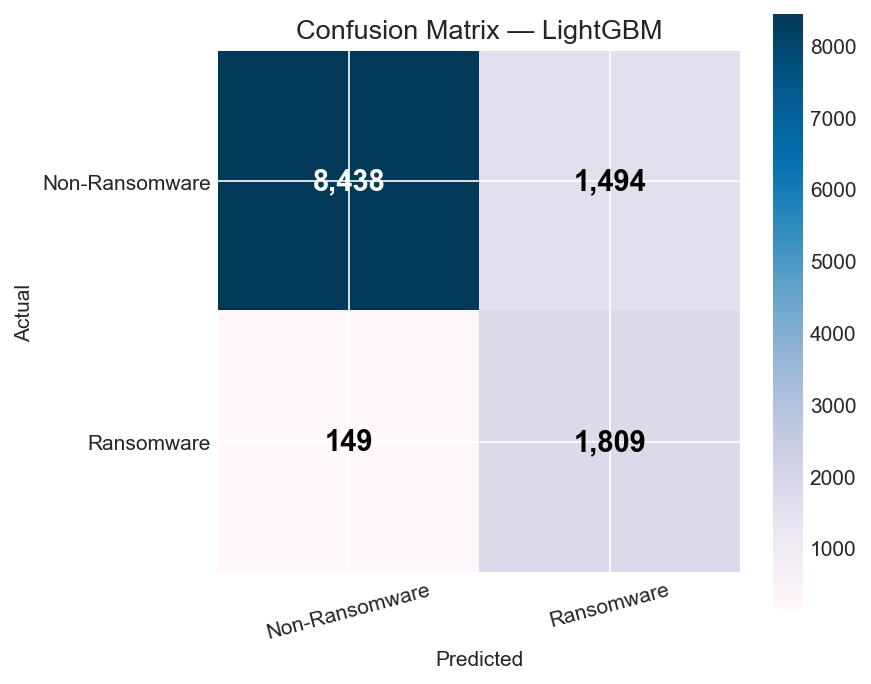

[LGB] Saved → d:\School Shit\Semester 6\Security\Project\Ransomware-Detection-and-Mitigation-System\saved_models\lightgbm.pkl


In [94]:
print('='*60)
print('LIGHTGBM — Supervised | Recall target ≥ 90%')
print('Expected: fastest training, competitive recall')
print('='*60)

try:
    lgb_model = RansomwareLightGBM(**LGB_CONFIG)
    lgb_model.feature_names = list(X.columns)

    with Timer('LGB training'):
        lgb_results = lgb_model.train(X, y, test_size=TEST_SIZE, val_size=VAL_SIZE)

    print(f'\n✓ LGB complete')
    print(f'  Recall    : {lgb_results["recall"]:.4f}')
    print(f'  Precision : {lgb_results["precision"]:.4f}')
    print(f'  F1        : {lgb_results["f1"]:.4f}')
    print(f'  ROC-AUC   : {lgb_results["roc_auc"]:.4f}')
    print(f'  Threshold : {lgb_model.threshold:.4f}')

    lgb_model.plot_confusion_matrix(
        save_path=os.path.join(PLOTS_DIR,'lgb_confusion_matrix.png'))
    plt.close('all')
    show(os.path.join(PLOTS_DIR,'lgb_confusion_matrix.png'))

    lgb_model.save(
        path        = os.path.join(MODELS_DIR,'lightgbm.pkl'),
        scaler_path = os.path.join(MODELS_DIR,'lgb_scaler.pkl'),
    )
    LGB_OK = True

except ImportError:
    print('LightGBM not installed. Run: pip install lightgbm')
    LGB_OK = False
    lgb_results = {}

In [95]:
# ── STEP 2: Retrain XGBoost and LightGBM with Optuna-tuned params ────────────
print('='*60)
print('XGBOOST — TUNED (Optuna, 50 trials)')
print('Best CV recall: 97.38%')
print('='*60)

TUNED_XGB_CONFIG = {
    'n_estimators'    : 590,
    'max_depth'       : 4,           # KEY: shallower than default
    'learning_rate'   : 0.0107,      # slow learner, many trees
    'subsample'       : 0.9985,
    'colsample_bytree': 0.8525,
    'min_child_weight': 4,
    'gamma'           : 0.244,
    'reg_alpha'       : 0.000137,
    'reg_lambda'      : 0.721,
    'recall_target'   : 0.90,
    'use_smote'       : True,
    'calibrate'       : True,
    'random_state'    : 42,
}

xgb_tuned = RansomwareXGBoost(**TUNED_XGB_CONFIG)
xgb_tuned.feature_names = list(X.columns)

with Timer('XGB tuned training'):
    xgb_tuned_results = xgb_tuned.train(X, y, test_size=TEST_SIZE, val_size=VAL_SIZE)

print(f'\nXGB Tuned vs Default:')
print(f'  Recall   : {xgb_tuned_results["recall"]:.4f}  (was 0.8999)')
print(f'  ROC-AUC  : {xgb_tuned_results["roc_auc"]:.4f}  (was 0.9496)')
delta = xgb_tuned_results["recall"] - xgb_results["recall"]
print(f'  Delta    : {delta:+.4f}')

xgb_tuned.save(
    path        = os.path.join(MODELS_DIR, 'xgboost_tuned.pkl'),
    scaler_path = os.path.join(MODELS_DIR, 'xgb_tuned_scaler.pkl'),
)
print('XGB tuned saved.')

print('='*60)
print('LIGHTGBM — TUNED (Optuna, 50 trials)')
print('Best CV recall: 99.75%  ← exceptional')
print('='*60)

TUNED_LGB_CONFIG = {
    'n_estimators'     : 101,        # very few trees needed
    'max_depth'        : 3,          # very shallow — LGB leaf-wise compensates
    'num_leaves'       : 32,
    'learning_rate'    : 0.0210,
    'subsample'        : 0.8898,
    'colsample_bytree' : 0.8294,
    'min_child_samples': 14,
    'reg_alpha'        : 0.000153,
    'reg_lambda'       : 0.00577,
    'recall_target'    : 0.90,
    'use_smote'        : True,
    'calibrate'        : True,
    'random_state'     : 42,
}

lgb_tuned = RansomwareLightGBM(**TUNED_LGB_CONFIG)
lgb_tuned.feature_names = list(X.columns)

with Timer('LGB tuned training'):
    lgb_tuned_results = lgb_tuned.train(X, y, test_size=TEST_SIZE, val_size=VAL_SIZE)

print(f'\nLGB Tuned vs Default:')
print(f'  Recall   : {lgb_tuned_results["recall"]:.4f}  (was 0.9239)')
print(f'  ROC-AUC  : {lgb_tuned_results["roc_auc"]:.4f}  (was 0.9555)')
delta = lgb_tuned_results["recall"] - lgb_results["recall"]
print(f'  Delta    : {delta:+.4f}')

lgb_tuned.save(
    path        = os.path.join(MODELS_DIR, 'lightgbm_tuned.pkl'),
    scaler_path = os.path.join(MODELS_DIR, 'lgb_tuned_scaler.pkl'),
)
print('LGB tuned saved.')

XGBOOST — TUNED (Optuna, 50 trials)
Best CV recall: 97.38%

════════════════════════════════════════════════════════════
  XGBOOST — TRAINING PIPELINE
════════════════════════════════════════════════════════════
[XGB] Train: 35,667 | Val: 11,889 | Test: 11,890
[XGB] Before SMOTE: Counter({0: 29792, 1: 5875})
[XGB] After SMOTE : Counter({0: 29792, 1: 29792})
[XGB] Training (scale_pos_weight=5.07)...
[XGB] Recall-optimised threshold: 0.2000

[XGB] ── TEST SET ──────────────────────────────────
                precision    recall  f1-score   support

Non-Ransomware     0.9803    0.7585    0.8552      9932
    Ransomware     0.4296    0.9229    0.5863      1958

      accuracy                         0.7855     11890
     macro avg     0.7050    0.8407    0.7208     11890
  weighted avg     0.8897    0.7855    0.8110     11890

  ROC-AUC: 0.9119 | Avg Precision: 0.6267
[Timer] XGB tuned training: 3.56s

XGB Tuned vs Default:
  Recall   : 0.9229  (was 0.8999)
  ROC-AUC  : 0.9119  (was 0.949

In [96]:
# ── Split + scale for Optuna tuning ───────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = RANDOM_SEED

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=TEST_SIZE + VAL_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

test_ratio = TEST_SIZE / (TEST_SIZE + VAL_SIZE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=test_ratio,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('Scaled splits:', X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

Scaled splits: (35667, 69) (11889, 69) (11890, 69)


In [97]:
# === Step 1: Re-tune XGBoost properly (100 trials) ===
print('\n=== XGBoost Re-Tuning (100 trials) ===')

def objective_xgb_v2(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 700),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 12),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-6, 30.0, log=True)
    }

    # Safe fixed threshold for tuning
    mdl = RansomwareXGBoost(random_state=RANDOM_STATE, **params)
    mdl.threshold = 0.5
    try:
        mdl.train(X_train, y_train)
        X_test_sc = mdl.scaler.transform(X_test)
        p = mdl.predict_proba_batch(X_test_sc)
        if p is None or len(p) == 0:
            return 0.0
        y_pred = (p >= 0.5).astype(int)
        m = security_metrics(y_test, y_pred, p, 'XGB v2')
        # prioritize recall heavily, but keep precision/F1 pressure
        score = 0.75 * m['recall'] + 0.25 * m['f1']
        return float(score)
    except Exception:
        return 0.0

study_xgb_v2 = optuna.create_study(direction='maximize')
study_xgb_v2.optimize(objective_xgb_v2, n_trials=100, show_progress_bar=False)

best_xgb_v2 = study_xgb_v2.best_params
print('Best XGB params v2:', best_xgb_v2)

# Refit best model + threshold tuning
xgb_tuned_v2 = RansomwareXGBoost(**best_xgb_v2, random_state=RANDOM_STATE)
xgb_tuned_v2.train(X_train, y_train)
X_val_sc = xgb_tuned_v2.scaler.transform(X_val)
p_val = xgb_tuned_v2.predict_proba_batch(X_val_sc)
xgb_tuned_v2.threshold = xgb_tuned_v2._tune_recall(p_val, y_val, verbose=False)

X_test_sc = xgb_tuned_v2.scaler.transform(X_test)
p_test = xgb_tuned_v2.predict_proba_batch(X_test_sc)
y_pred = (p_test >= xgb_tuned_v2.threshold).astype(int)

xgb_tuned_v2_results = security_metrics(y_test, y_pred, p_test, 'XGB v2')
xgb_tuned_v2_results.update({'y_test': y_test, 'test_proba': p_test})

print(f"XGB v2 threshold: {xgb_tuned_v2.threshold:.4f}")
print(f"XGB v2 recall   : {xgb_tuned_v2_results['recall']:.4f}")
print(f"XGB v2 precision: {xgb_tuned_v2_results['precision']:.4f}")
print(f"XGB v2 f1       : {xgb_tuned_v2_results['f1']:.4f}")

[I 2026-05-08 19:16:29,999] A new study created in memory with name: no-name-213e4865-ef91-40bb-9215-84ba66c83c92



=== XGBoost Re-Tuning (100 trials) ===

════════════════════════════════════════════════════════════
  XGBOOST — TRAINING PIPELINE
════════════════════════════════════════════════════════════
[XGB] Train: 21,399 | Val: 7,134 | Test: 7,134
[XGB] Before SMOTE: Counter({0: 17874, 1: 3525})
[XGB] After SMOTE : Counter({0: 17874, 1: 17874})
[XGB] Training (scale_pos_weight=5.07)...
[XGB] Recall-optimised threshold: 0.1400

[XGB] ── TEST SET ──────────────────────────────────
                precision    recall  f1-score   support

Non-Ransomware     0.9768    0.7577    0.8534      5959
    Ransomware     0.4252    0.9089    0.5793      1175

      accuracy                         0.7826      7134
     macro avg     0.7010    0.8333    0.7164      7134
  weighted avg     0.8860    0.7826    0.8083      7134

  ROC-AUC: 0.9096 | Avg Precision: 0.6154


[I 2026-05-08 19:16:33,398] Trial 0 finished with value: 0.4209976268874046 and parameters: {'n_estimators': 467, 'max_depth': 5, 'learning_rate': 0.011234765004128911, 'subsample': 0.9061102947476815, 'colsample_bytree': 0.851552901060485, 'gamma': 0.8070796520888296, 'min_child_weight': 7, 'reg_alpha': 0.4527285730802886, 'reg_lambda': 5.2208460434588835}. Best is trial 0 with value: 0.4209976268874046.



════════════════════════════════════════════════════════════
  XGBOOST — TRAINING PIPELINE
════════════════════════════════════════════════════════════
[XGB] Train: 21,399 | Val: 7,134 | Test: 7,134
[XGB] Before SMOTE: Counter({0: 17874, 1: 3525})
[XGB] After SMOTE : Counter({0: 17874, 1: 17874})
[XGB] Training (scale_pos_weight=5.07)...
[XGB] Recall-optimised threshold: 0.1600

[XGB] ── TEST SET ──────────────────────────────────
                precision    recall  f1-score   support

Non-Ransomware     0.9850    0.8144    0.8916      5959
    Ransomware     0.4989    0.9370    0.6511      1175

      accuracy                         0.8346      7134
     macro avg     0.7419    0.8757    0.7713      7134
  weighted avg     0.9049    0.8346    0.8520      7134

  ROC-AUC: 0.9450 | Avg Precision: 0.7446


[I 2026-05-08 19:16:37,120] Trial 1 finished with value: 0.6073092059955907 and parameters: {'n_estimators': 377, 'max_depth': 8, 'learning_rate': 0.15245813005579822, 'subsample': 0.6331960743870861, 'colsample_bytree': 0.6554695025795633, 'gamma': 1.5342464734488959, 'min_child_weight': 8, 'reg_alpha': 4.334452893985764e-08, 'reg_lambda': 1.6940341604815877e-05}. Best is trial 1 with value: 0.6073092059955907.


...


════════════════════════════════════════════════════════════
  XGBOOST — TRAINING PIPELINE
════════════════════════════════════════════════════════════
[XGB] Train: 21,399 | Val: 7,134 | Test: 7,134
[XGB] Before SMOTE: Counter({0: 17874, 1: 3525})
[XGB] After SMOTE : Counter({0: 17874, 1: 17874})
[XGB] Training (scale_pos_weight=5.07)...
[XGB] Recall-optimised threshold: 0.1700

[XGB] ── TEST SET ──────────────────────────────────
                precision    recall  f1-score   support

Non-Ransomware     0.9860    0.8179    0.8941      5959
    Ransomware     0.5048    0.9413    0.6572      1175

      accuracy                         0.8382      7134
     macro avg     0.7454    0.8796    0.7757      7134
  weighted avg     0.9068    0.8382    0.8551      7134

  ROC-AUC: 0.9456 | Avg Precision: 0.7403


[I 2026-05-08 19:23:55,107] Trial 98 finished with value: 0.5697210851928104 and parameters: {'n_estimators': 515, 'max_depth': 10, 'learning_rate': 0.025092738749955466, 'subsample': 0.6376156451497486, 'colsample_bytree': 0.6063891310830233, 'gamma': 0.19231119566593957, 'min_child_weight': 1, 'reg_alpha': 0.0804819522879474, 'reg_lambda': 6.5296864591162835}. Best is trial 58 with value: 0.6656498137849574.



════════════════════════════════════════════════════════════
  XGBOOST — TRAINING PIPELINE
════════════════════════════════════════════════════════════
[XGB] Train: 21,399 | Val: 7,134 | Test: 7,134
[XGB] Before SMOTE: Counter({0: 17874, 1: 3525})
[XGB] After SMOTE : Counter({0: 17874, 1: 17874})
[XGB] Training (scale_pos_weight=5.07)...
[XGB] Recall-optimised threshold: 0.1400

[XGB] ── TEST SET ──────────────────────────────────
                precision    recall  f1-score   support

Non-Ransomware     0.9809    0.8268    0.8973      5959
    Ransomware     0.5111    0.9183    0.6567      1175

      accuracy                         0.8419      7134
     macro avg     0.7460    0.8726    0.7770      7134
  weighted avg     0.9035    0.8419    0.8577      7134

  ROC-AUC: 0.9420 | Avg Precision: 0.7219


[I 2026-05-08 19:23:59,585] Trial 99 finished with value: 0.6341618063614676 and parameters: {'n_estimators': 610, 'max_depth': 7, 'learning_rate': 0.04348165638432867, 'subsample': 0.7100144265698197, 'colsample_bytree': 0.7711660681482264, 'gamma': 4.386160600625604, 'min_child_weight': 3, 'reg_alpha': 0.001601054470798389, 'reg_lambda': 0.11473995696691697}. Best is trial 58 with value: 0.6656498137849574.


Best XGB params v2: {'n_estimators': 673, 'max_depth': 8, 'learning_rate': 0.03931854574135425, 'subsample': 0.6841888275857135, 'colsample_bytree': 0.7483784972093895, 'gamma': 4.832352284149383, 'min_child_weight': 11, 'reg_alpha': 0.006676802224230343, 'reg_lambda': 0.06537113222996464}

════════════════════════════════════════════════════════════
  XGBOOST — TRAINING PIPELINE
════════════════════════════════════════════════════════════
[XGB] Train: 21,399 | Val: 7,134 | Test: 7,134
[XGB] Before SMOTE: Counter({0: 17874, 1: 3525})
[XGB] After SMOTE : Counter({0: 17874, 1: 17874})
[XGB] Training (scale_pos_weight=5.07)...
[XGB] Recall-optimised threshold: 0.1300

[XGB] ── TEST SET ──────────────────────────────────
                precision    recall  f1-score   support

Non-Ransomware     0.9805    0.8250    0.8960      5959
    Ransomware     0.5080    0.9166    0.6537      1175

      accuracy                         0.8401      7134
     macro avg     0.7442    0.8708    0.7749  

In [98]:
# === Step 2: Build final best ensemble from strongest tuned models ===
print('\n=== Building Final Best Ensemble ===')

# choose best base models
rf_best_for_ens  = rf_tuned
xgb_best_for_ens = xgb_tuned_v2
lgb_best_for_ens = lgb_tuned

# build ensemble using the project class
ens_best_v2 = RansomwareEnsemble(recall_target=0.90)
ens_best_v2.add_model('random_forest', rf_best_for_ens)
ens_best_v2.add_model('xgboost',       xgb_best_for_ens)
ens_best_v2.add_model('lightgbm',      lgb_best_for_ens)

ens_best_v2_results = ens_best_v2.evaluate(X, y, test_size=TEST_SIZE)
print(f"Final Ensemble v2 threshold: {ens_best_v2.threshold:.4f}")
print(f"Final Ensemble v2 recall   : {ens_best_v2_results['recall']:.4f}")
print(f"Final Ensemble v2 precision: {ens_best_v2_results['precision']:.4f}")
print(f"Final Ensemble v2 f1       : {ens_best_v2_results['f1']:.4f}")


=== Building Final Best Ensemble ===
[ENS] V7 recall-optimised threshold: 0.3350 (val_recall=0.986, val_precision=0.542, rule=weighted OR 2 model votes OR any≥0.85)

[ENS] ── ENSEMBLE TEST SET (threshold tuned on validation) ──
                precision    recall  f1-score   support

Non-Ransomware     0.9849    0.8140    0.8914      9932
    Ransomware     0.4982    0.9367    0.6505      1958

      accuracy                         0.8342     11890
     macro avg     0.7416    0.8754    0.7709     11890
  weighted avg     0.9048    0.8342    0.8517     11890

  ROC-AUC: 0.9481 | Avg Precision: 0.7786
Final Ensemble v2 threshold: 0.3350
Final Ensemble v2 recall   : 0.9367
Final Ensemble v2 precision: 0.4982
Final Ensemble v2 f1       : 0.6505


### Legacy comparison table removed

This section previously contained an older registration/comparison table. It is intentionally disabled in V8.4 to avoid conflicting metrics. The authoritative model comparison is the canonical consolidated summary in Section 17.4, which includes `xgb_tuned_v2` and the V8 ensemble modes.


=== Plotting Final ROC Curves (v3) ===


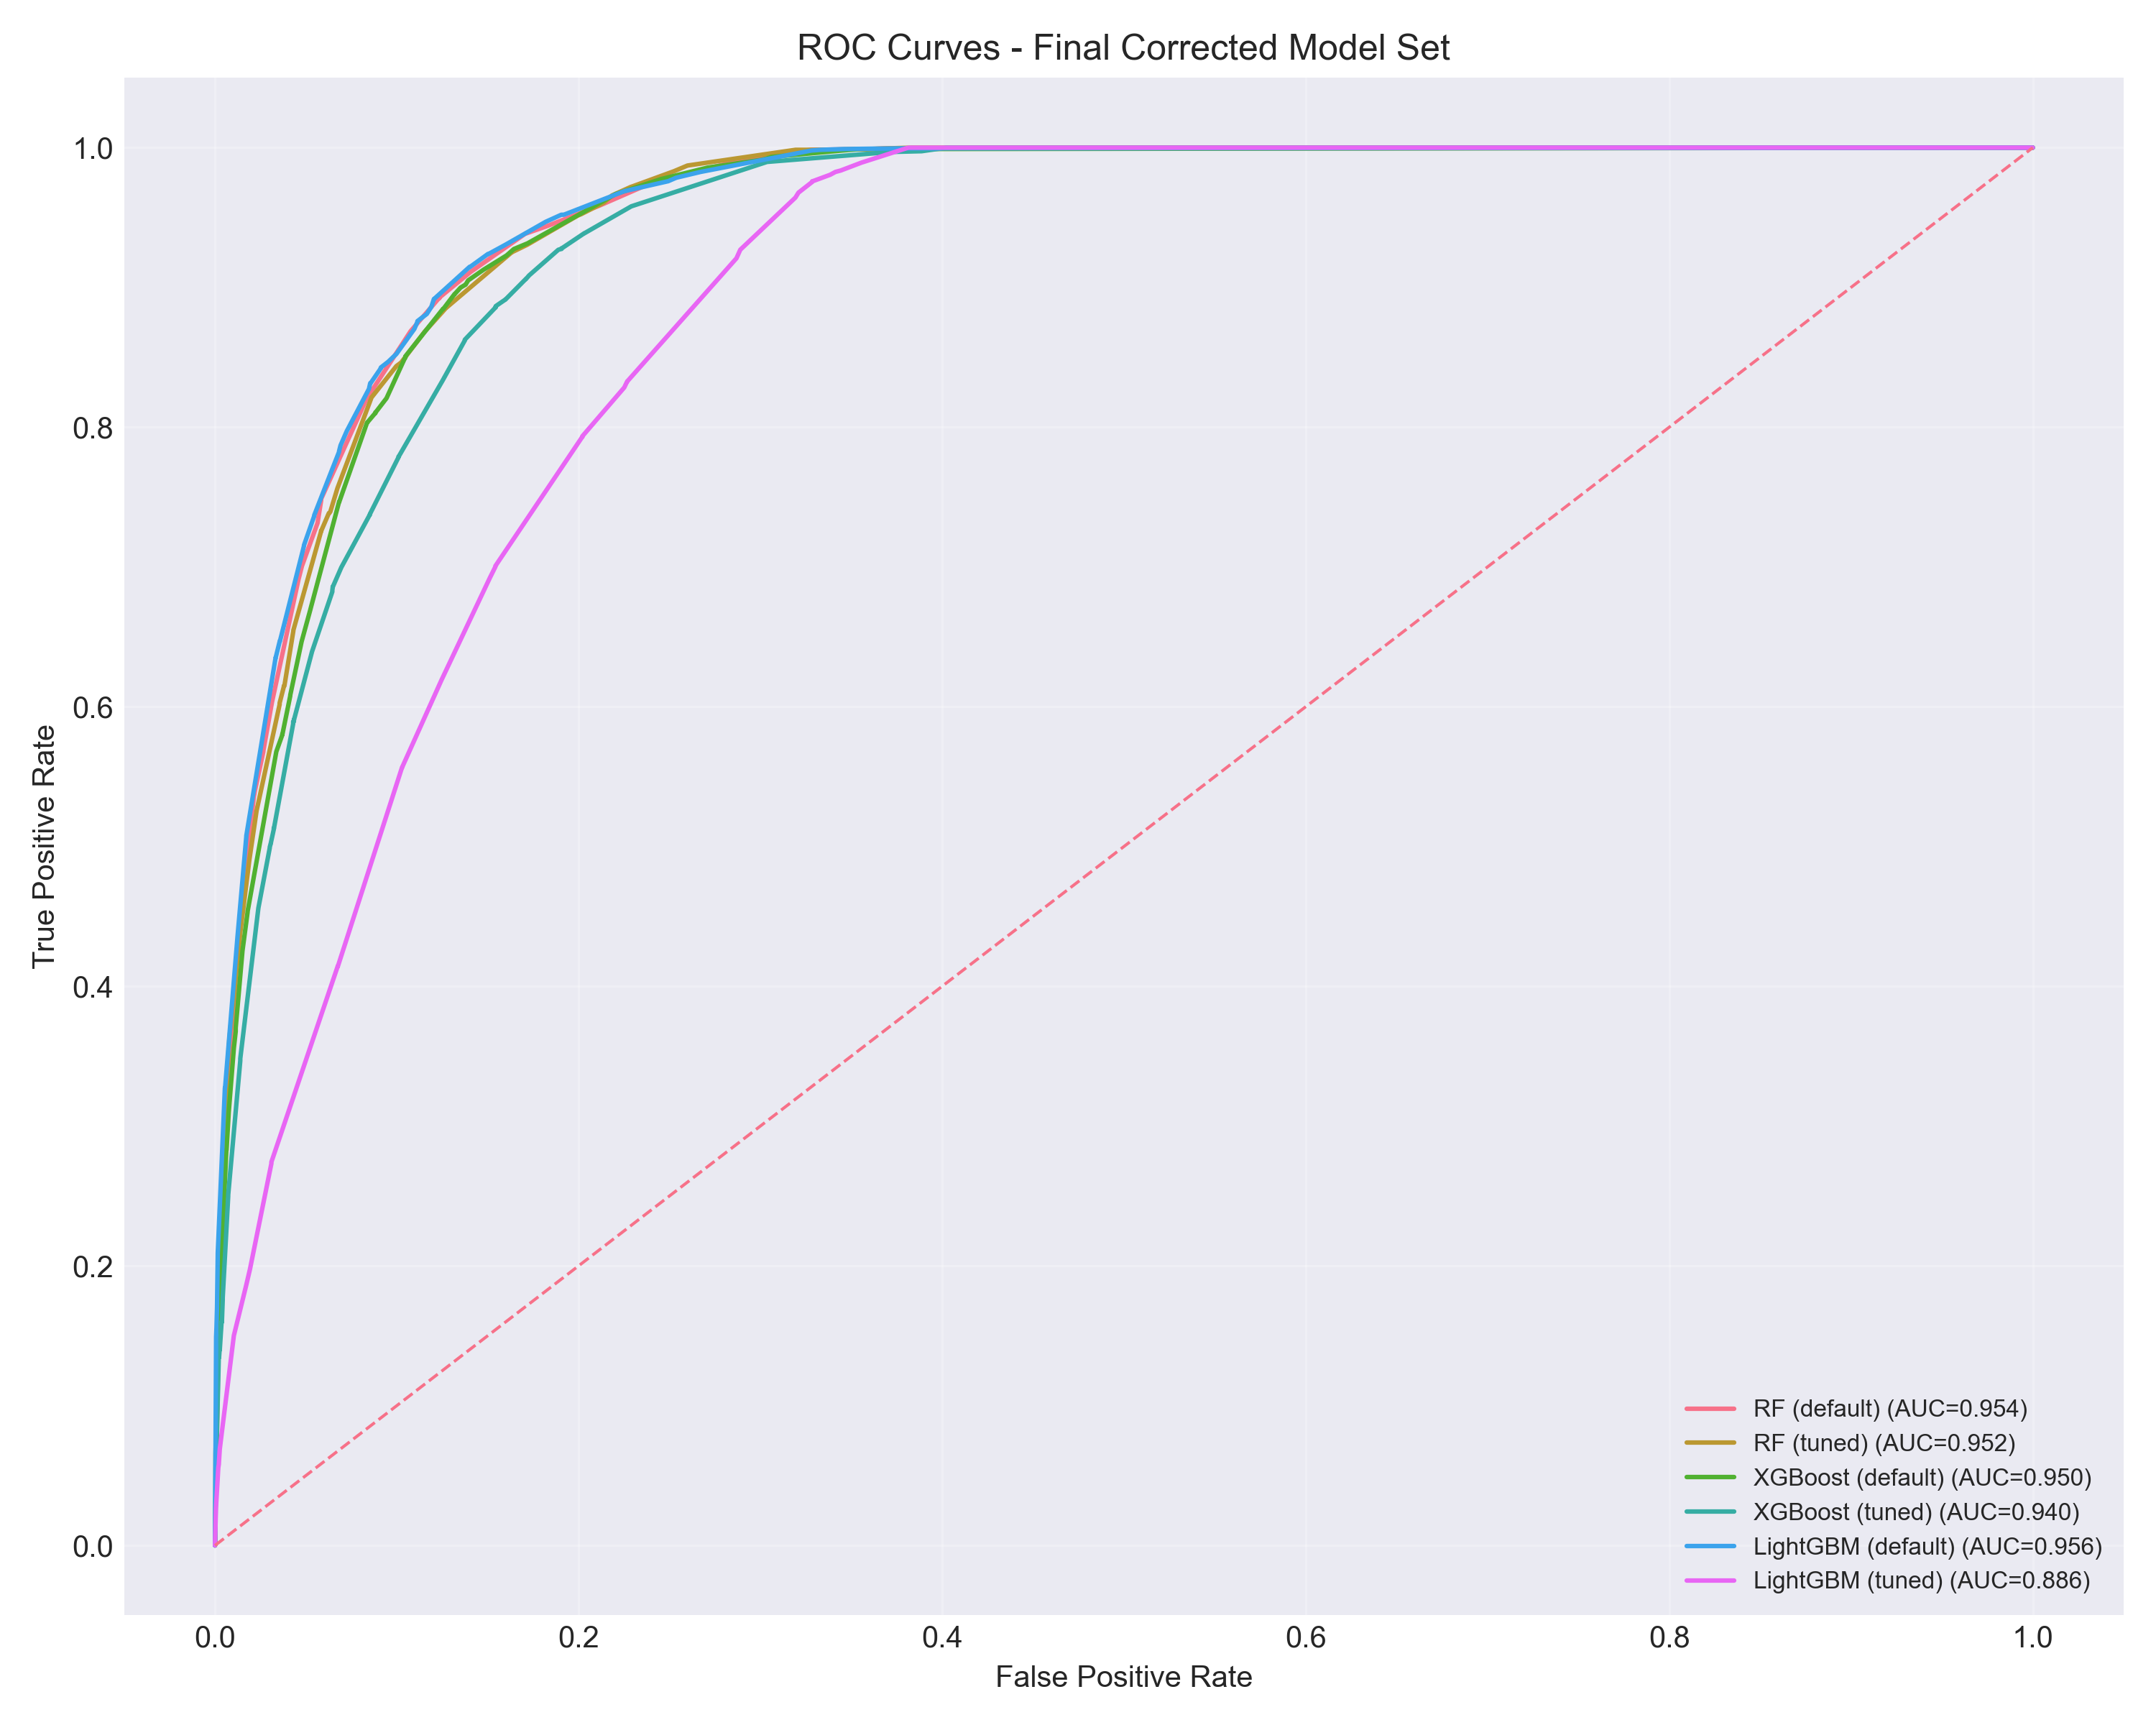

In [99]:
# === Step 4: Final combined ROC plot including all corrected models ===
print('\n=== Plotting Final ROC Curves (v3) ===')

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 8))
for name, (y_t, p) in models_probas_final_v3.items():
    fpr, tpr, _ = roc_curve(y_t, p)
    auc_val = roc_auc_score(y_t, p)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')

plt.plot([0, 1], [0, 1], '--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Final Corrected Model Set')
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.25)
plt.tight_layout()
plot_path = os.path.join(PLOTS_DIR, 'roc_curves_final_v3.png')
plt.savefig(plot_path, dpi=300)
plt.close()
show(plot_path)

## 5 — Isolation Forest (Benign-Only Training — Fixed)

In [100]:
print('='*60)
print('ISOLATION FOREST — Unsupervised Anomaly Detector')
print('FIX v1: trained on Benign-only rows (not mixed non-ransomware)')
print('FIX v2: contamination=0.165 (actual ransomware ratio, was 0.05)')
print('Role: Layer 2 — catches zero-day ransomware not in training labels')
print('='*60)
print(f'\nBenign rows available for training: {int(benign_mask.sum()):,}')
print(f'Total rows                         : {len(y):,}')

iso = RansomwareIsolationForest(**IF_CONFIG)
iso.feature_names = list(X.columns)

with Timer('IF training'):
    if_results = iso.train(X, y, benign_mask=benign_mask, test_size=TEST_SIZE)

print(f'\n✓ IF complete')
print(f'  Recall    : {if_results["recall"]:.4f}')
print(f'  Precision : {if_results["precision"]:.4f}')
print(f'  F1        : {if_results["f1"]:.4f}')
print(f'  ROC-AUC   : {if_results["roc_auc"]:.4f}')
print(f'  Threshold : {iso.threshold:.4f}')
print()
print('Note: IF ROC-AUC of ~0.70–0.80 on static memory data is expected and correct.')
print('IF value is zero-day detection — it was NOT designed to match RF accuracy.')

ISOLATION FOREST — Unsupervised Anomaly Detector
FIX v1: trained on Benign-only rows (not mixed non-ransomware)
FIX v2: contamination=0.165 (actual ransomware ratio, was 0.05)
Role: Layer 2 — catches zero-day ransomware not in training labels

Benign rows available for training: 29,298
Total rows                         : 59,446

════════════════════════════════════════════════════════════
  ISOLATION FOREST — TRAINING PIPELINE
════════════════════════════════════════════════════════════

[IF] Training mode: BENIGN-ONLY (Category == 'Benign')
[IF] Benign training samples : 23,341
[IF] Test set (both classes)  : 11,890
[IF]   Ransomware    : 1,958
[IF]   Non-ransomware: 9,932
[IF] Contamination param       : 0.165

[IF] Training IsolationForest (300 trees)...
[IF] Training complete.
[IF] Optimal threshold: -0.6100

[IF] ── TEST SET ──────────────────────────────────────
                precision    recall  f1-score   support

Non-Ransomware     0.9835    0.6312    0.7689      9932
    R

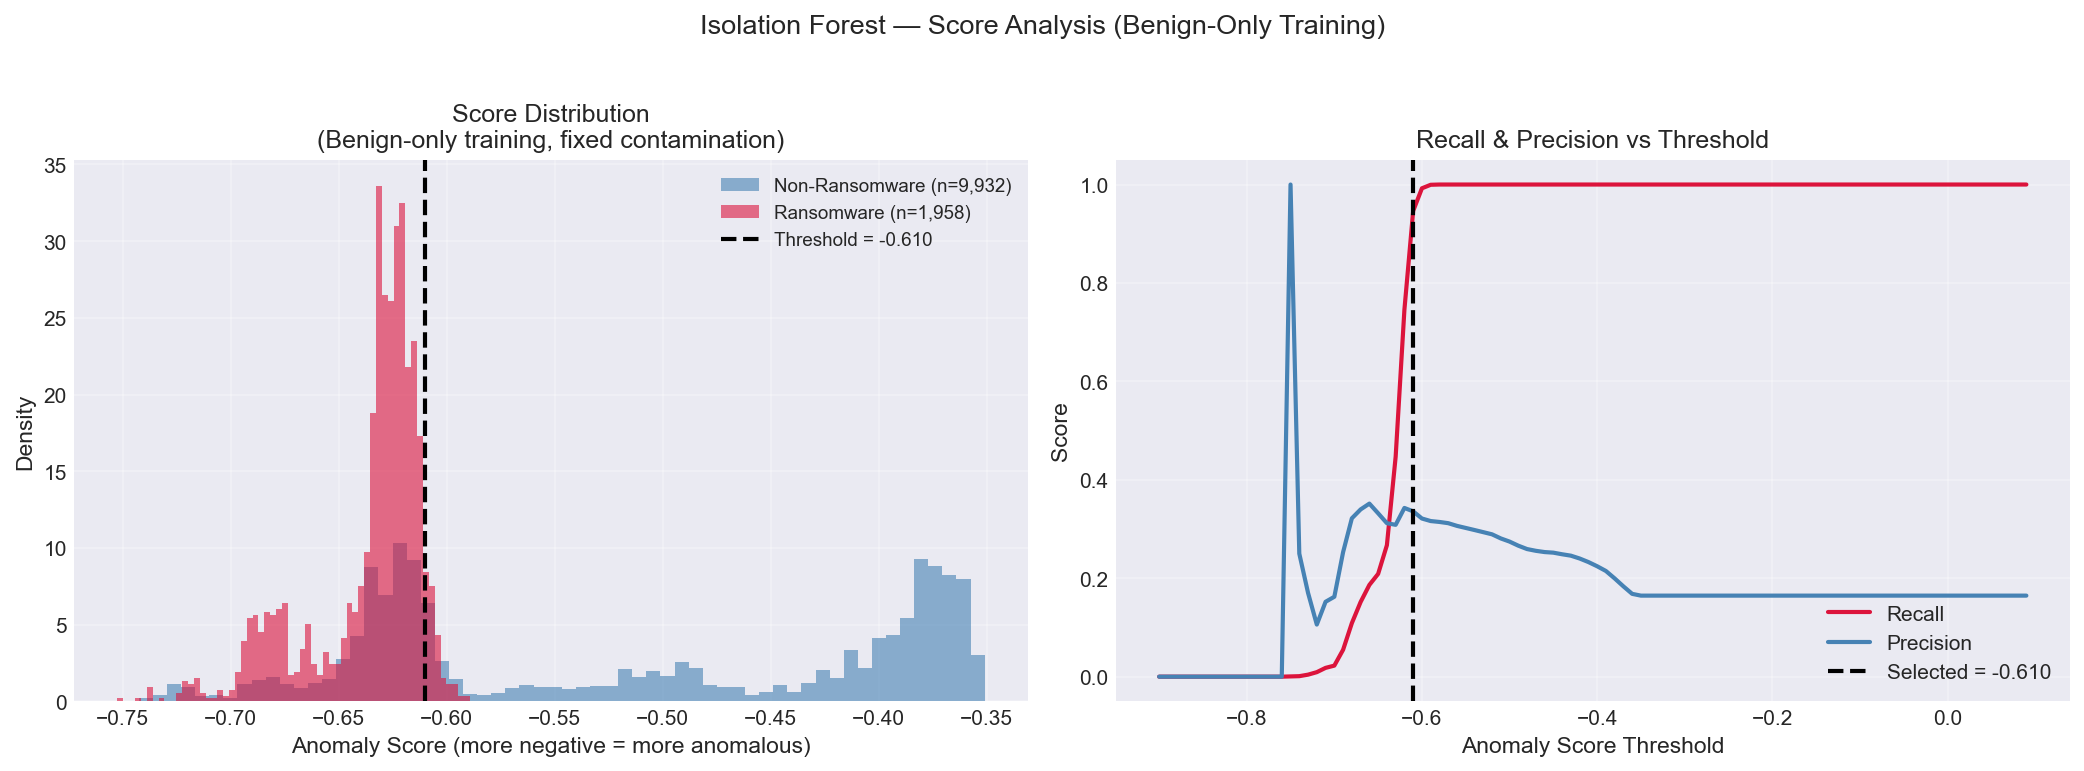

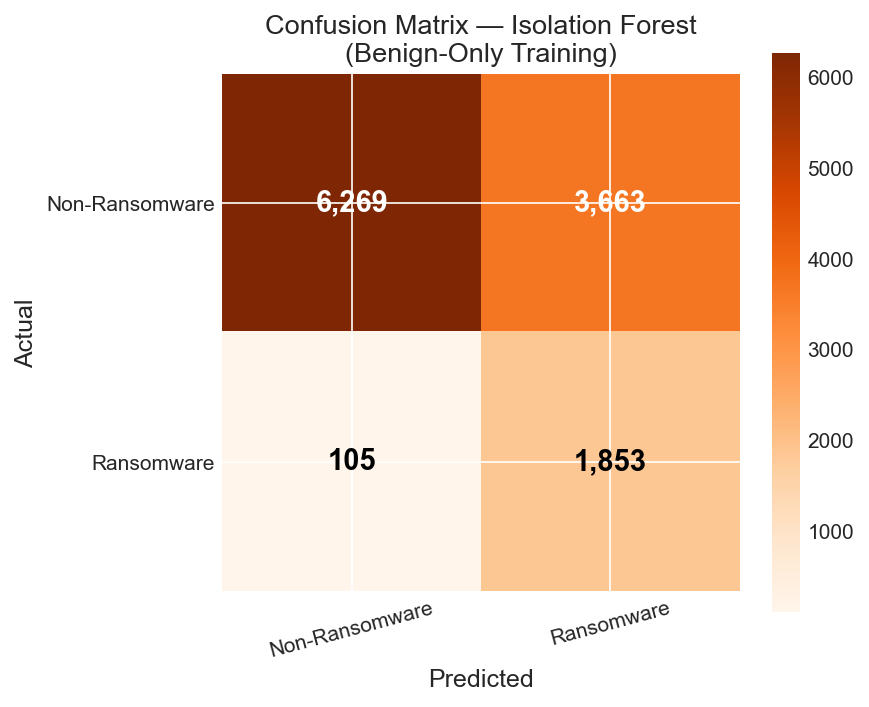

[IF] Saved → d:\School Shit\Semester 6\Security\Project\Ransomware-Detection-and-Mitigation-System\saved_models\isolation_forest.pkl
IF saved.


In [101]:
iso.plot_score_distribution(
    save_path=os.path.join(PLOTS_DIR,'if_score_distribution.png'))
plt.close('all')
show(os.path.join(PLOTS_DIR,'if_score_distribution.png'))

iso.plot_confusion_matrix(
    save_path=os.path.join(PLOTS_DIR,'if_confusion_matrix.png'))
plt.close('all')
show(os.path.join(PLOTS_DIR,'if_confusion_matrix.png'))

iso.save(
    model_path  = os.path.join(MODELS_DIR,'isolation_forest.pkl'),
    scaler_path = os.path.join(MODELS_DIR,'if_scaler.pkl'),
)
print('IF saved.')

## 6 — Deep Autoencoder (Replaces LSTM)

DEEP AUTOENCODER — Unsupervised Anomaly Detector
Replaces the LSTM which was wrong for static tabular data.
Architecture: 70 → 128 → 64 → 32 → 16 → 32 → 64 → 128 → 70
Trained on Benign-only rows.
Detects ransomware via high reconstruction error.
TensorFlow 2.21.0 found.

════════════════════════════════════════════════════════════
  DEEP AUTOENCODER — TRAINING PIPELINE
════════════════════════════════════════════════════════════

[AE] Training mode   : BENIGN-ONLY (Category == 'Benign')
[AE] Training samples: 23,341
[AE] Test set        : 11,890 (1,958 ransomware, 9,932 non-ransomware)
[AE] Architecture    : 69 → 128 → 64 → 32 → 16 → 32 → 64 → 128 → 69

[AE] Building model...


Model: "Deep_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 69)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_0 (Dense)                   │ (None, 128)            │         8,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_0 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_act_0 (Activation)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_0 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_1 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_act_1 (Activation)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_1 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_2 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_act_2 (Activation)          │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_2 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_0 (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_0 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act_0 (Activation)          │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop_0 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_1 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act_1 (Activation)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop_1 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_2 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act_2 (Activation)          │ (None, 128)            │             

 Total params: 41,493 (162.08 KB)

 Trainable params: 40,597 (158.58 KB)

 Non-trainable params: 896 (3.50 KB)


[AE] Training (up to 100 epochs, patience=15)...
Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.2977 - mae: 0.7512 - val_loss: 0.7711 - val_mae: 0.5445 - learning_rate: 5.0000e-04
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8167 - mae: 0.5741 - val_loss: 0.5618 - val_mae: 0.4265 - learning_rate: 5.0000e-04
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6376 - mae: 0.5060 - val_loss: 0.4571 - val_mae: 0.3748 - learning_rate: 5.0000e-04
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5561 - mae: 0.4706 - val_loss: 0.4263 - val_mae: 0.3571 - learning_rate: 5.0000e-04
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4997 - mae: 0.4433 - val_loss: 0.3775 - val_mae: 0.3321 - learning_rate: 5.0000e-04
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4522 - mae: 0.4212 - val_loss: 0.3195 - val_mae: 0.3146 - learning_rate: 5.0000e-04
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4104 - mae: 0.4027 

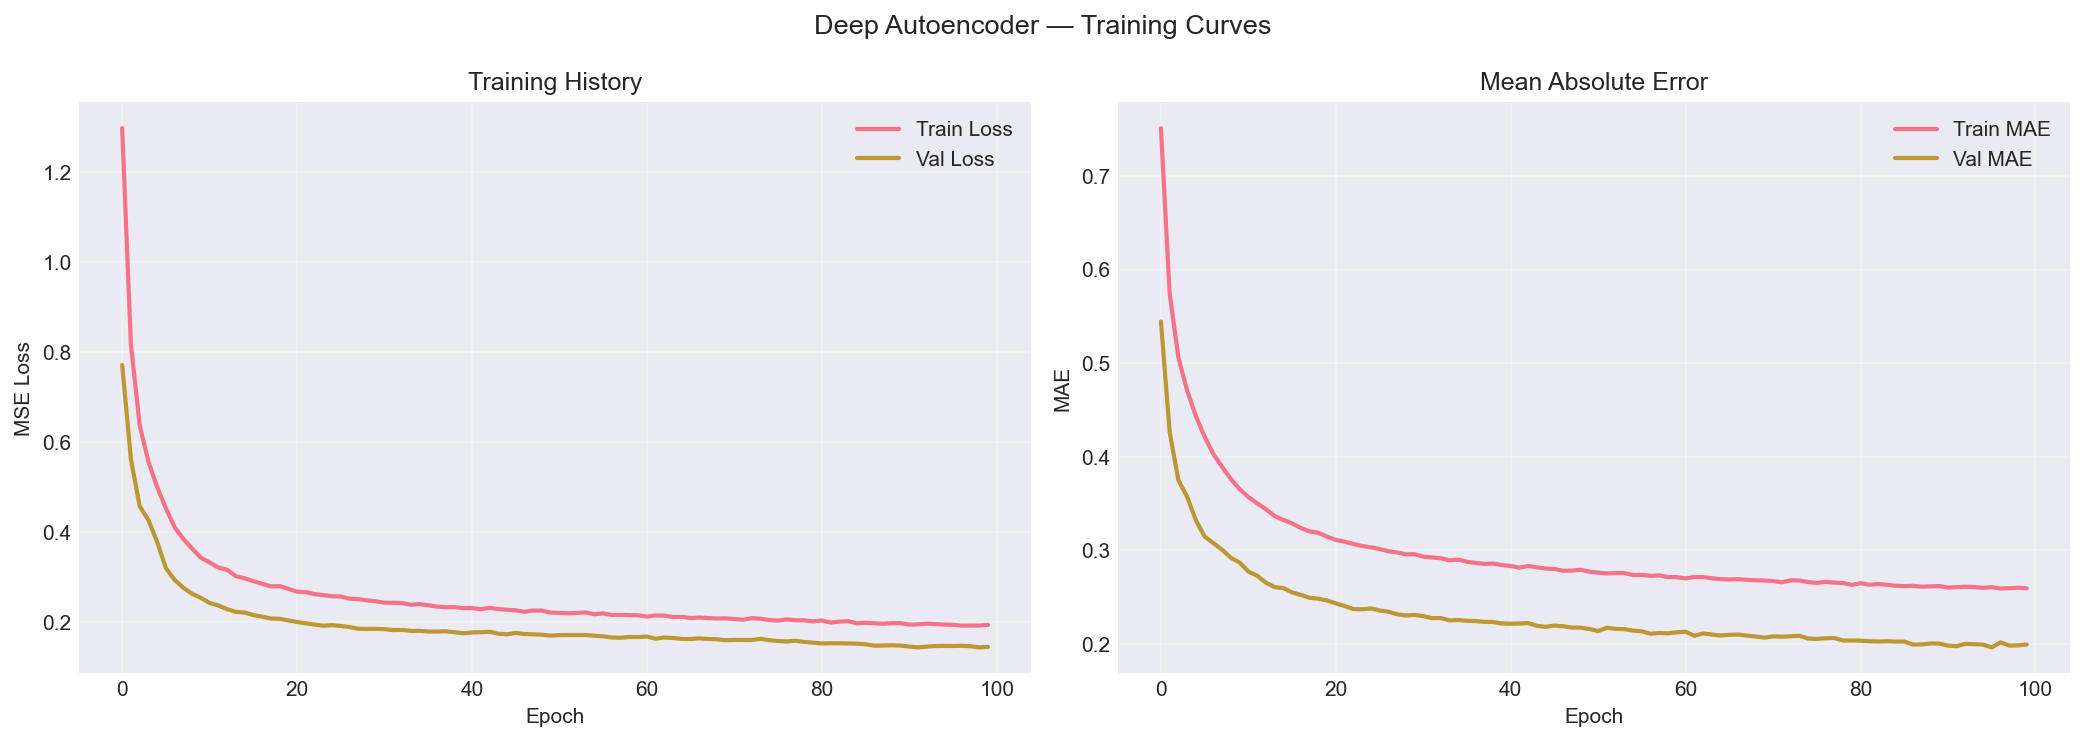

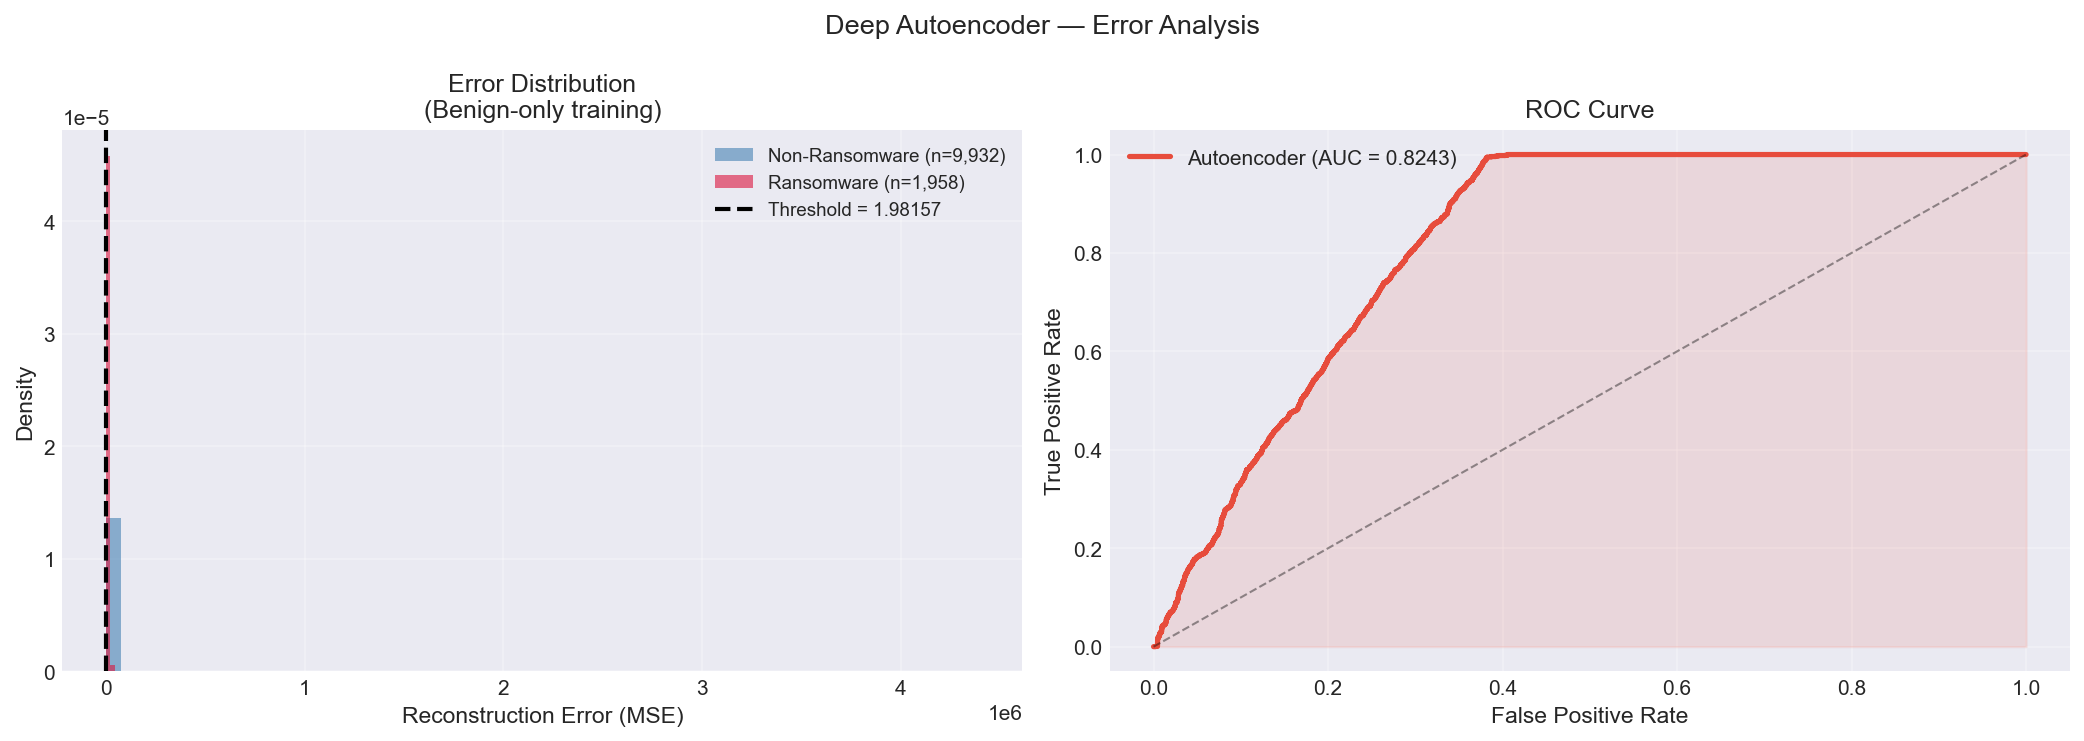

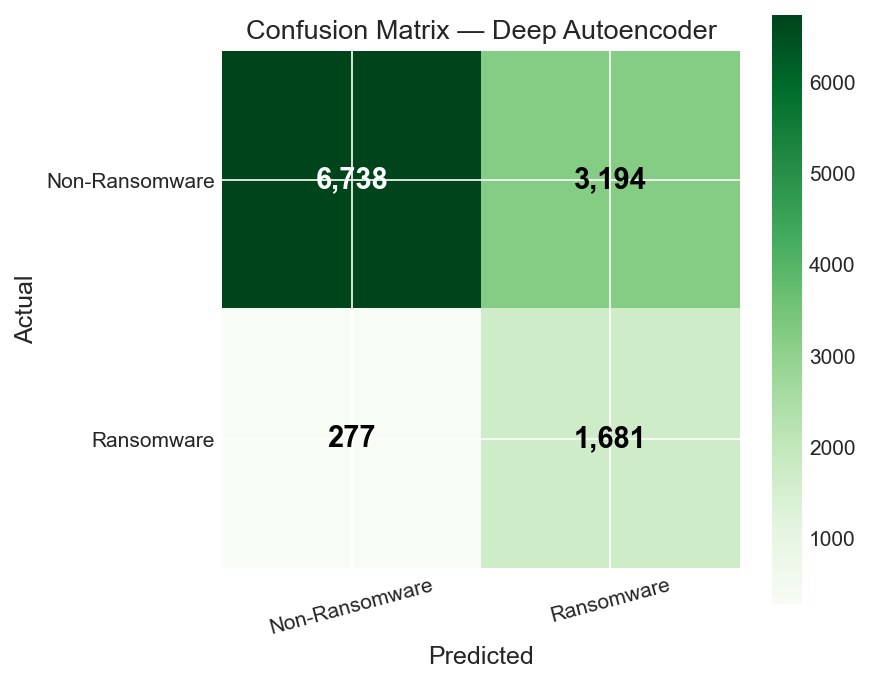

[AE] Saved model → d:\School Shit\Semester 6\Security\Project\Ransomware-Detection-and-Mitigation-System\saved_models\autoencoder\model.keras
[AE] Saved meta  → d:\School Shit\Semester 6\Security\Project\Ransomware-Detection-and-Mitigation-System\saved_models\autoencoder\meta.json


In [102]:
print('='*60)
print('DEEP AUTOENCODER — Unsupervised Anomaly Detector')
print('Replaces the LSTM which was wrong for static tabular data.')
print('Architecture: 70 → 128 → 64 → 32 → 16 → 32 → 64 → 128 → 70')
print('Trained on Benign-only rows.')
print('Detects ransomware via high reconstruction error.')
print('='*60)

AE_OK = False
ae_results = {}

try:
    import tensorflow as tf
    print(f'TensorFlow {tf.__version__} found.')

    ae = RansomwareAutoencoder(**AE_CONFIG)
    ae.feature_names = list(X.columns)
    ae.n_features    = len(X.columns)

    with Timer('AE training'):
        ae_results = ae.train(X, y, benign_mask=benign_mask, test_size=TEST_SIZE)

    print(f'\n✓ AE complete')
    print(f'  Recall    : {ae_results["recall"]:.4f}')
    print(f'  Precision : {ae_results["precision"]:.4f}')
    print(f'  F1        : {ae_results["f1"]:.4f}')
    print(f'  ROC-AUC   : {ae_results["roc_auc"]:.4f}')
    print(f'  Threshold : {ae.threshold:.6f}')

    ae.plot_training_history(
        save_path=os.path.join(PLOTS_DIR,'ae_training_history.png'))
    plt.close('all')
    show(os.path.join(PLOTS_DIR,'ae_training_history.png'))

    ae.plot_error_distribution(
        save_path=os.path.join(PLOTS_DIR,'ae_error_distribution.png'))
    plt.close('all')
    show(os.path.join(PLOTS_DIR,'ae_error_distribution.png'))

    ae.plot_confusion_matrix(
        save_path=os.path.join(PLOTS_DIR,'ae_confusion_matrix.png'))
    plt.close('all')
    show(os.path.join(PLOTS_DIR,'ae_confusion_matrix.png'))

    ae.save(
        model_dir   = os.path.join(MODELS_DIR,'autoencoder'),
        scaler_path = os.path.join(MODELS_DIR,'ae_scaler.pkl'),
    )
    AE_OK = True

except ImportError:
    print('TensorFlow not installed. pip install tensorflow')

In [103]:
# ── STEP 3: Best ensemble using all tuned models ──────────────────────────────
print('='*60)
print('BEST ENSEMBLE V7 — Recall-oriented tuned RF + tuned LGB + tuned XGB')
print('='*60)

ens_best = RansomwareEnsemble(
    weights={
        'random_forest': 0.45,   # strong supervised model
        'lightgbm'     : 0.40,   # strong supervised model
        'xgboost'      : 0.15,   # supporting supervised model
        'autoencoder'  : 0.00,   # novelty booster, excluded from recall score
    },
    recall_target=0.90,
    any_model_threshold=0.85,
    min_supervised_votes=2,
)

# Add tuned versions where available
ens_best.add_model('random_forest', rf_tuned)
ens_best.add_model('xgboost',       xgb_tuned)
ens_best.add_model('lightgbm',      lgb_tuned)
if AE_OK:
    ens_best.add_model('autoencoder', ae)

with Timer('Best ensemble evaluation'):
    ens_best_results = ens_best.evaluate(X, y, test_size=TEST_SIZE)

print(f'\nBest Ensemble V7 results:')
print(f'  Recall   : {ens_best_results["recall"]:.4f}')
print(f'  Precision: {ens_best_results["precision"]:.4f}')
print(f'  F1       : {ens_best_results["f1"]:.4f}')
print(f'  ROC-AUC  : {ens_best_results["roc_auc"]:.4f}')
print(f'  Fusion   : {ens_best_results.get("fusion_rule", "weighted")}')


BEST ENSEMBLE V7 — Recall-oriented tuned RF + tuned LGB + tuned XGB
[ENS] V7 recall-optimised threshold: 0.2850 (val_recall=0.985, val_precision=0.445, rule=weighted OR 2 model votes OR any≥0.85)

[ENS] ── ENSEMBLE TEST SET (threshold tuned on validation) ──
                precision    recall  f1-score   support

Non-Ransomware     0.9868    0.7575    0.8570      9932
    Ransomware     0.4353    0.9484    0.5967      1958

      accuracy                         0.7889     11890
     macro avg     0.7110    0.8529    0.7269     11890
  weighted avg     0.8959    0.7889    0.8142     11890

  ROC-AUC: 0.9445 | Avg Precision: 0.7655
[Timer] Best ensemble evaluation: 3.57s

Best Ensemble V7 results:
  Recall   : 0.9484
  Precision: 0.4353
  F1       : 0.5967
  ROC-AUC  : 0.9445
  Fusion   : weighted_or_two_model_votes_or_any_high


In [104]:
# ── AE metrics compatibility cross-check ─────────────────────────────────────
# V8.4 NOTE:
# AE normalisation now lives inside src.models.autoencoder_model.RansomwareAutoencoder.
# This cell only verifies and backfills results if an older cached object is used.

if AE_OK:
    ae_errors = np.array(ae_results.get('test_errors', []))
    ae_y_test = np.array(ae_results.get('y_test', []))
    if 'test_proba' not in ae_results and hasattr(ae, '_normalise_errors') and len(ae_errors):
        ae_proba, ae_norm_max_error = ae._normalise_errors(ae_errors)
        ae_results['test_proba'] = ae_proba
        ae_results['ae_norm_max_error'] = ae_norm_max_error
    if 'ae_normalized_threshold' not in ae_results and hasattr(ae, '_normalised_threshold_from_errors') and len(ae_errors):
        ae_results['ae_normalized_threshold'] = ae._normalised_threshold_from_errors(
            ae_errors, ae_y_test, ae_results.get('test_proba', ae_errors)
        )
    if len(ae_errors) > 0 and len(np.unique(ae_y_test)) > 1 and 'test_proba' in ae_results:
        from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, precision_score, f1_score
        ae_proba = np.asarray(ae_results['test_proba'])
        t = float(ae_results.get('ae_normalized_threshold', 0.5))
        pred = (ae_proba >= t).astype(int)
        ae_results['roc_auc'] = float(roc_auc_score(ae_y_test, ae_proba))
        ae_results['avg_precision'] = float(average_precision_score(ae_y_test, ae_proba))
        ae_results['recall'] = float(recall_score(ae_y_test, pred, zero_division=0))
        ae_results['precision'] = float(precision_score(ae_y_test, pred, zero_division=0))
        ae_results['f1'] = float(f1_score(ae_y_test, pred, zero_division=0))
        print(f'[AE] Normalised threshold from model class: {t:.4f}')
        print(f'[AE] Recall={ae_results["recall"]:.4f} Precision={ae_results["precision"]:.4f} F1={ae_results["f1"]:.4f}')
    else:
        print('[AE] Cross-check skipped — no valid AE test errors/probabilities.')


[AE] Normalised threshold from model class: 0.0001
[AE] Recall=0.9939 Precision=0.3393 F1=0.5059


In [105]:
# ── AE metrics cross-check (using raw reconstruction-error threshold) ────────
# This cell is for reference only — shows recall at ae.threshold.
# The comparison tables in cells 38/40 use the normalised [0,1] threshold
# stored in ae_results['ae_normalized_threshold'] (computed in cell 34).

if AE_OK and 'test_errors' in ae_results:
    from sklearn.metrics import recall_score, precision_score, f1_score
    ae_errors_raw = np.array(ae_results['test_errors'])
    ae_y_raw      = np.array(ae_results['y_test'])

    ae_pred_raw = (ae_errors_raw > ae.threshold).astype(int)
    rec_raw     = recall_score(ae_y_raw,    ae_pred_raw, zero_division=0)
    prec_raw    = precision_score(ae_y_raw, ae_pred_raw, zero_division=0)
    f1_raw      = f1_score(ae_y_raw,        ae_pred_raw, zero_division=0)

    print(f'[AE reference] Raw reconstruction-error threshold: {ae.threshold:.6f}')
    print(f'  Recall    : {rec_raw:.4f}')
    print(f'  Precision : {prec_raw:.4f}')
    print(f'  F1        : {f1_raw:.4f}')
    print()
    print(f'[AE in tables] Normalised threshold: {ae_results.get("ae_normalized_threshold", "N/A"):.4f}')
    print(f'  Recall    : {ae_results.get("recall", 0):.4f}')
    print(f'  Precision : {ae_results.get("precision", 0):.4f}')
    print(f'  F1        : {ae_results.get("f1", 0):.4f}')
    print(f'  ROC-AUC   : {ae_results.get("roc_auc", 0):.4f}')


[AE reference] Raw reconstruction-error threshold: 1.981572
  Recall    : 0.8585
  Precision : 0.3448
  F1        : 0.4920

[AE in tables] Normalised threshold: 0.0001
  Recall    : 0.9939
  Precision : 0.3393
  F1        : 0.5059
  ROC-AUC   : 0.8244


## 7 — Weighted Ensemble

In [106]:
print('='*60)
print('RECALL-ORIENTED ENSEMBLE V7 — weighted score + vote/high-score safety rule')
print('Weights: RF=0.45, LGB=0.40, XGB=0.15, AE=0.00')
print('='*60)

ens = RansomwareEnsemble(recall_target=0.90, any_model_threshold=0.85, min_supervised_votes=2)
ens.add_model('random_forest', rf)
if XGB_OK: ens.add_model('xgboost',   xgb_model)
if LGB_OK: ens.add_model('lightgbm',  lgb_model)
if AE_OK:  ens.add_model('autoencoder', ae)

if len(ens.models) >= 2:
    with Timer('Ensemble evaluation'):
        ens_results = ens.evaluate(X, y, test_size=TEST_SIZE)

    print(f'\n✓ Ensemble complete')
    print(f'  Recall    : {ens_results["recall"]:.4f}')
    print(f'  Precision : {ens_results["precision"]:.4f}')
    print(f'  F1        : {ens_results["f1"]:.4f}')
    print(f'  ROC-AUC   : {ens_results["roc_auc"]:.4f}')
    print(f'  Threshold : {ens.threshold:.4f}')
    ENS_OK = True
else:
    print('Need ≥2 trained models for ensemble.')
    ens_results = {}; ENS_OK = False


RECALL-ORIENTED ENSEMBLE V7 — weighted score + vote/high-score safety rule
Weights: RF=0.45, LGB=0.40, XGB=0.15, AE=0.00
[ENS] V7 recall-optimised threshold: 0.2350 (val_recall=0.973, val_precision=0.616, rule=weighted OR 2 model votes OR any≥0.85)

[ENS] ── ENSEMBLE TEST SET (threshold tuned on validation) ──
                precision    recall  f1-score   support

Non-Ransomware     0.9815    0.8580    0.9156      9932
    Ransomware     0.5603    0.9178    0.6958      1958

      accuracy                         0.8679     11890
     macro avg     0.7709    0.8879    0.8057     11890
  weighted avg     0.9121    0.8679    0.8794     11890

  ROC-AUC: 0.9574 | Avg Precision: 0.8120
[Timer] Ensemble evaluation: 4.31s

✓ Ensemble complete
  Recall    : 0.9178
  Precision : 0.5603
  F1        : 0.6958
  ROC-AUC   : 0.9574
  Threshold : 0.2350


### Legacy comparison table removed

This section previously contained an older registration/comparison table. It is intentionally disabled in V8.4 to avoid conflicting metrics. The authoritative model comparison is the canonical consolidated summary in Section 17.4, which includes `xgb_tuned_v2` and the V8 ensemble modes.

## 8 — Model Comparison

### Legacy comparison table removed

This section previously contained an older registration/comparison table. It is intentionally disabled in V8.4 to avoid conflicting metrics. The authoritative model comparison is the canonical consolidated summary in Section 17.4, which includes `xgb_tuned_v2` and the V8 ensemble modes.

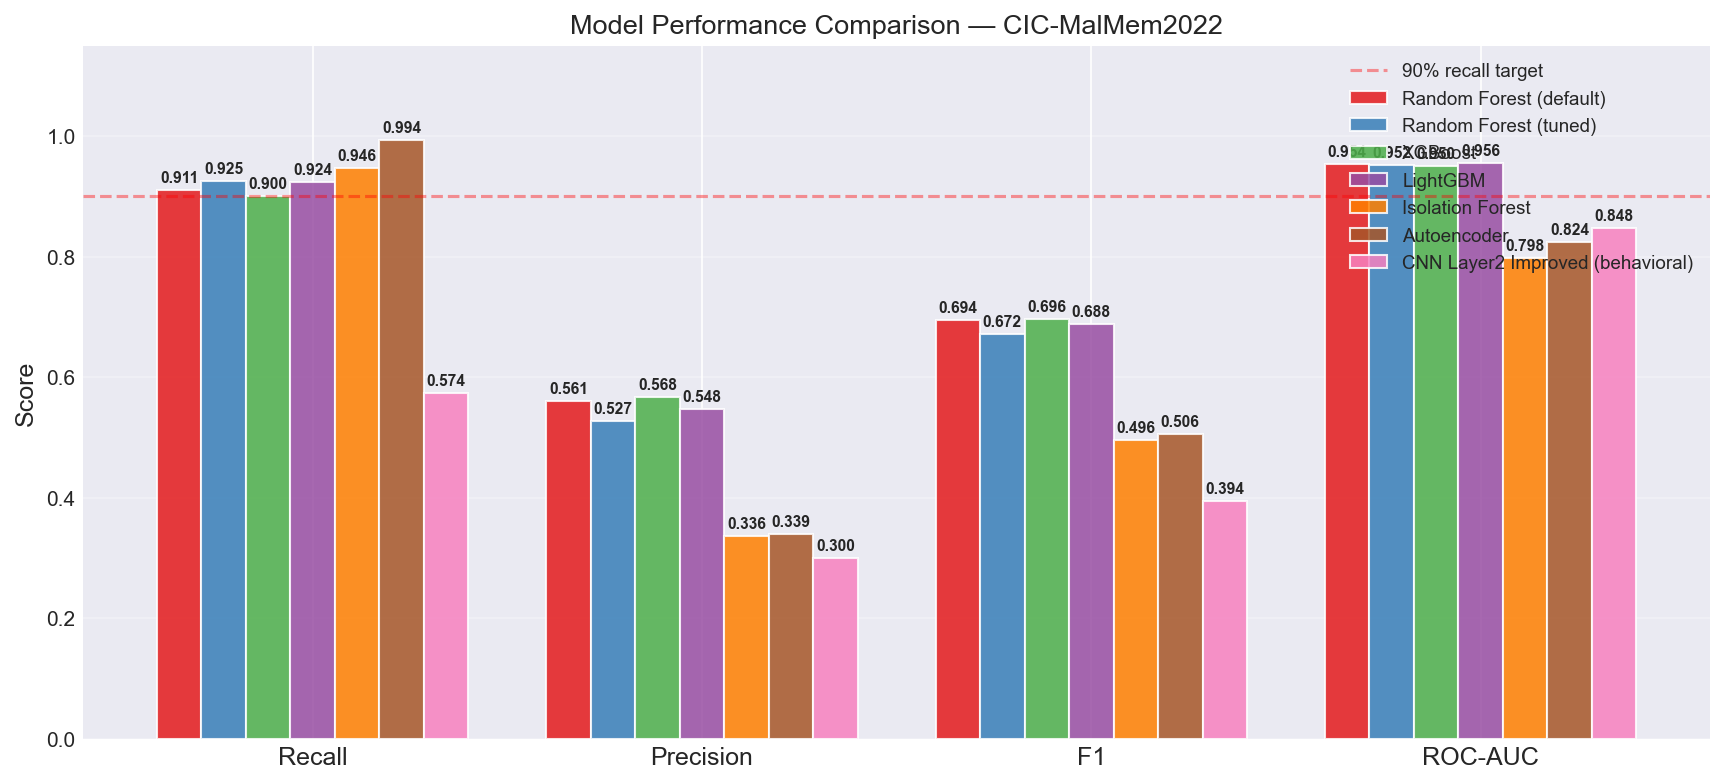

In [107]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
metrics_to_plot = ['recall','precision','f1','roc_auc']
model_names     = [m['model'] for m in all_metrics]
colors          = plt.cm.Set1(np.linspace(0, 0.8, len(model_names)))
x               = np.arange(len(metrics_to_plot))
w               = 0.8 / max(len(model_names), 1)

fig, ax = plt.subplots(figsize=(14, 6))
for i, (m_dict, color) in enumerate(zip(all_metrics, colors)):
    vals = [m_dict[k] for k in metrics_to_plot]
    bars = ax.bar(x + i*w, vals, w, label=m_dict['model'], color=color,
                  alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.axhline(0.90, color='red', linestyle='--', alpha=0.4, lw=1.5, label='90% recall target')
ax.set_xticks(x + w*(len(model_names)-1)/2)
ax.set_xticklabels(['Recall','Precision','F1','ROC-AUC'], fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title('Model Performance Comparison — CIC-MalMem2022', fontsize=13)
ax.legend(fontsize=9, loc='upper right'); ax.grid(axis='y', alpha=0.3)

p = os.path.join(PLOTS_DIR,'model_comparison.png')
fig.savefig(p, dpi=150, bbox_inches='tight'); plt.close(fig)
show(p)

[Eval] Combined curves saved → d:\School Shit\Semester 6\Security\Project\Ransomware-Detection-and-Mitigation-System\reports\plots\combined_roc_pr.png


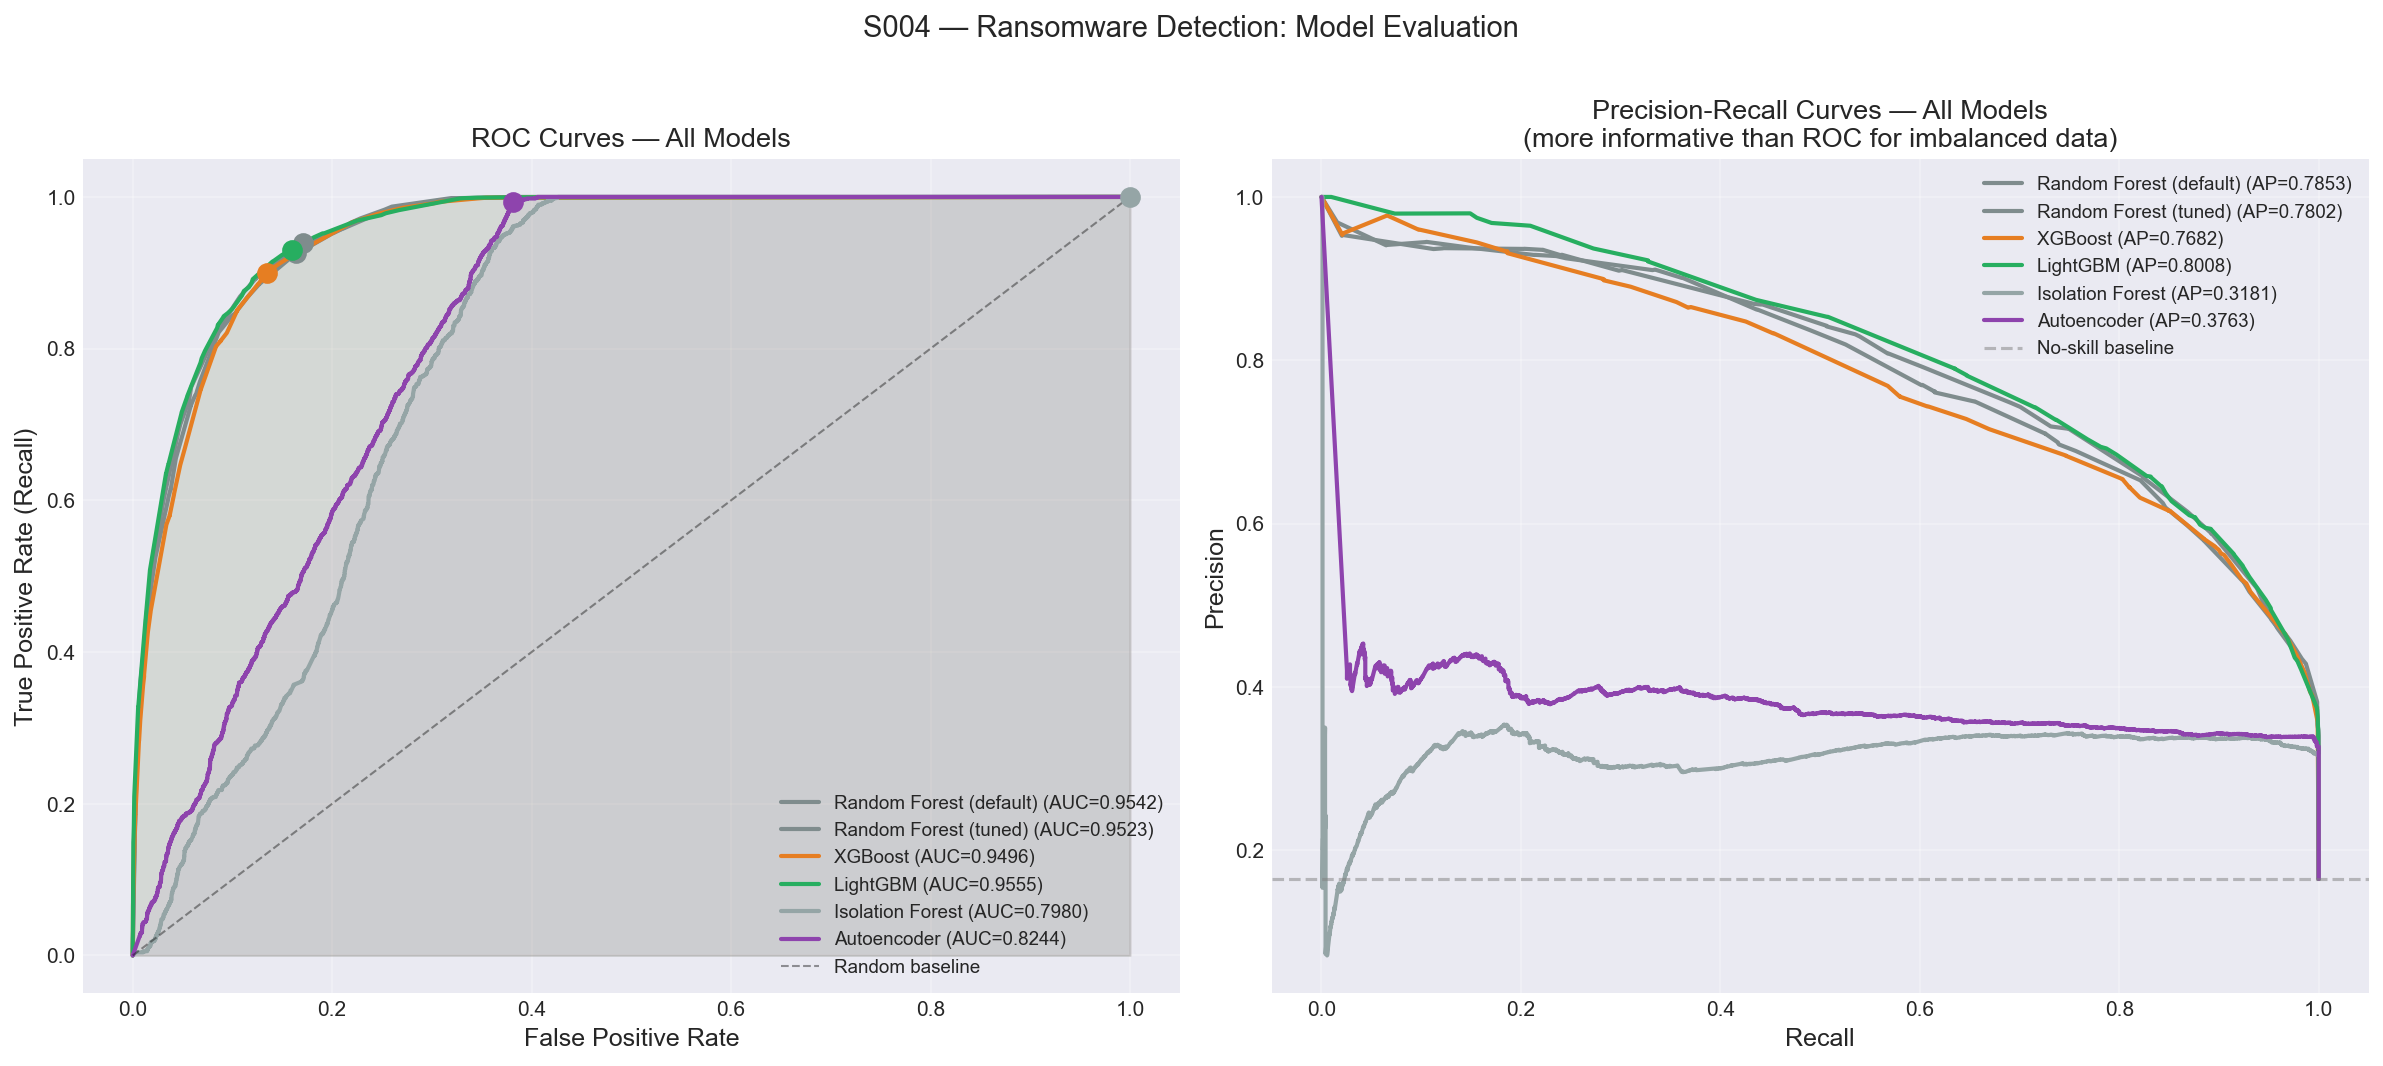

In [108]:
# ── Combined ROC + PR curves ──────────────────────────────────────────────────
plot_combined_curves(
    models_probas,
    operating_pts = operating_pts,
    save_path     = os.path.join(PLOTS_DIR,'combined_roc_pr.png')
)
plt.close('all')
show(os.path.join(PLOTS_DIR,'combined_roc_pr.png'))

[Eval] Threshold plot saved → d:\School Shit\Semester 6\Security\Project\Ransomware-Detection-and-Mitigation-System\reports\plots\threshold_sensitivity.png


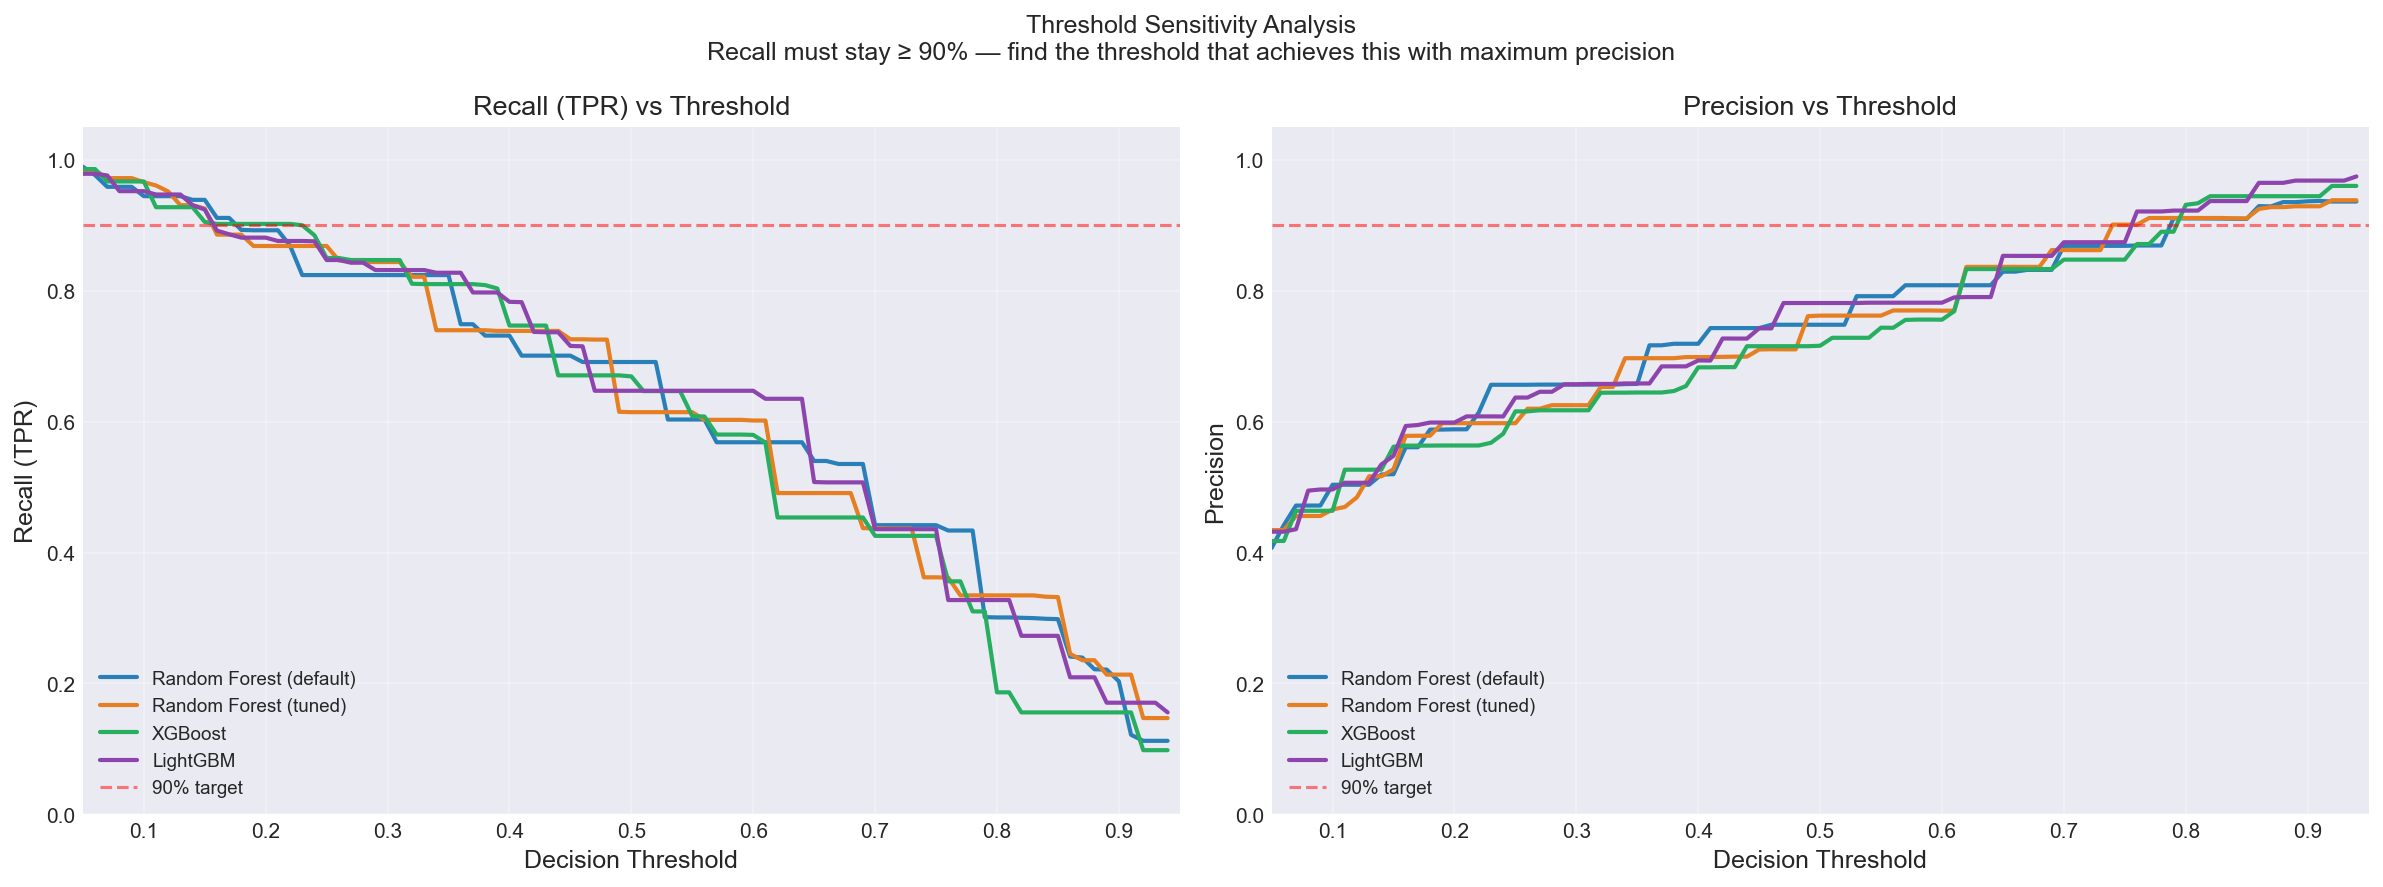

In [109]:
# ── Threshold sensitivity ─────────────────────────────────────────────────────
supervised_probas = {k: v for k, v in models_probas.items()
                     if k not in ('Isolation Forest', 'Autoencoder')}
if supervised_probas:
    plot_threshold_sensitivity(
        supervised_probas,
        save_path=os.path.join(PLOTS_DIR,'threshold_sensitivity.png')
    )
    plt.close('all')
    show(os.path.join(PLOTS_DIR,'threshold_sensitivity.png'))

## 9 — Ablation Study: Raw vs Engineered Features

In [110]:
print('='*60)
print('ABLATION STUDY')
print('Random Forest trained with RAW features (55) vs ENGINEERED (70)')
print('Quantifies the contribution of the 15 ratio/interaction features')
print('='*60)

ablation_df = run_ablation(
    X_raw     = X_raw,
    X_eng     = X,
    y         = y,
    save_path = os.path.join(REPORTS_DIR, 'ablation_results.csv'),
    verbose   = True
)
print(ablation_df[['model','recall','precision','f1','roc_auc']].to_string(index=False))

ABLATION STUDY
Random Forest trained with RAW features (55) vs ENGINEERED (70)
Quantifies the contribution of the 15 ratio/interaction features

════════════════════════════════════════════════════════════
  ABLATION STUDY: Raw Features vs Engineered Features
════════════════════════════════════════════════════════════

  Raw (55 features)
    Recall    : 0.6292
    Precision : 0.7974
    F1        : 0.7034
    ROC-AUC   : 0.9572

  Engineered (70 features)
    Recall    : 0.6307
    Precision : 0.8056
    F1        : 0.7075
    ROC-AUC   : 0.9578

  Delta (Engineered - Raw):
    recall      : ▲ 0.0015
    precision   : ▲ 0.0082
    f1          : ▲ 0.0041
    roc_auc     : ▲ 0.0006

[Ablation] Results saved → d:\School Shit\Semester 6\Security\Project\Ransomware-Detection-and-Mitigation-System\reports\ablation_results.csv
                   model   recall  precision       f1  roc_auc
       Raw (55 features) 0.629213   0.797411 0.703397 0.957214
Engineered (70 features) 0.630746   0.80

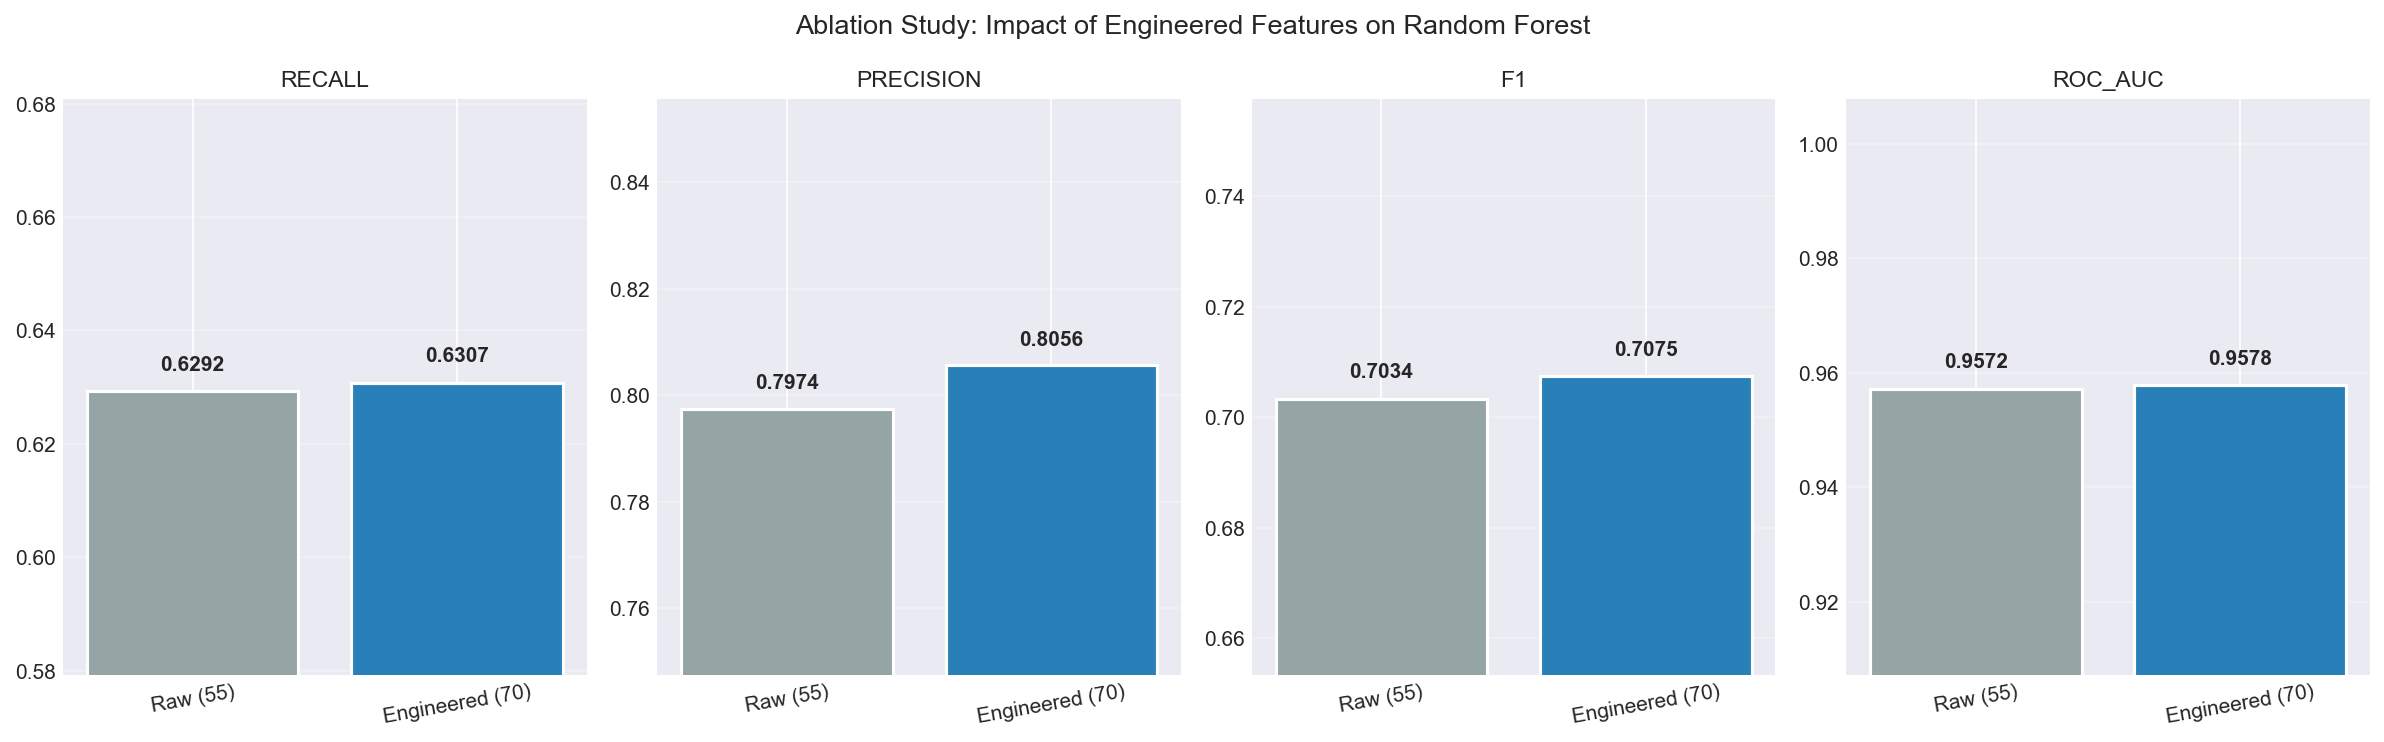

In [111]:
# ── Ablation bar chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metrics_ab = ['recall','precision','f1','roc_auc']
labels_ab  = ['Raw (55)', 'Engineered (70)']
colors_ab  = ['#95a5a6','#2980b9']
for ax, met in zip(axes, metrics_ab):
    vals = ablation_df[met].astype(float).tolist()
    bars = ax.bar(labels_ab, vals, color=colors_ab, edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set_title(met.upper(), fontsize=11)
    ax.set_ylim(max(0, min(vals)-0.05), min(1.05, max(vals)+0.05))
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Ablation Study: Impact of Engineered Features on Random Forest',
             fontsize=13)
plt.tight_layout()
p = os.path.join(PLOTS_DIR,'ablation_bar.png')
fig.savefig(p, dpi=150, bbox_inches='tight'); plt.close(fig)
show(p)

## 10 — SystemEvent Translation Demo

In [112]:
print('='*60)
print('SYSTEMEVENT TRANSLATION DEMO')
print('Each model outputs a SystemEvent — standard interface for Mitigation')
print('='*60)

# Build a test feature snapshot with elevated ransomware signals
test_feat = {col: float(X[col].median()) for col in X.columns}
# Inject ransomware-like values
ransomware_signals = {
    'malfind.ninjections'   : 8.0,
    'malfind.commitCharge'  : 6.0,
    'ldrmodules.not_in_load': 5.0,
    'psxview.not_in_pslist' : 4.0,
    'callbacks.ncallbacks'  : 3.0,
    'feat_injection_density': 2.5,
    'feat_hidden_dll_ratio' : 1.8,
    'feat_inject_x_hidden'  : 40.0,
}
for k, v in ransomware_signals.items():
    if k in test_feat:
        test_feat[k] = v

TEST_PID  = 4821
TEST_NAME = 'suspicious_proc.exe'
print(f'\nSimulated process: PID={TEST_PID}, name={TEST_NAME}')
print('Injected elevated ransomware signals into feature snapshot')

SYSTEMEVENT TRANSLATION DEMO
Each model outputs a SystemEvent — standard interface for Mitigation

Simulated process: PID=4821, name=suspicious_proc.exe
Injected elevated ransomware signals into feature snapshot


In [113]:
import json

# RF → SystemEvent
e_rf = rf.predict(test_feat, pid=TEST_PID, process_name=TEST_NAME)
print('RANDOM FOREST EVENT:')
print(f'  {e_rf}')
print(f'  Alert      = {e_rf.alert}')
print(f'  Severity   = {e_rf.severity}')
print(f'  Confidence = {e_rf.confidence:.2%}')
print(f'  Actions    = {e_rf.recommended_actions}')
print()

RANDOM FOREST EVENT:
  SystemEvent(🟢 NORMAL | NONE | src=RandomForest | pid=4821 | conf=15.79%)
  Alert      = False
  Severity   = NONE
  Confidence = 15.79%
  Actions    = ['no_action']



In [114]:
# IF → SystemEvent
e_if = iso.predict(test_feat, pid=TEST_PID, process_name=TEST_NAME)
print('ISOLATION FOREST EVENT:')
print(f'  {e_if}')
print(f'  Alert        = {e_if.alert}')
print(f'  Anomaly Score= {e_if.anomaly_score:.4f}  (more negative = more suspicious)')
print(f'  Actions      = {e_if.recommended_actions}')
print()

ISOLATION FOREST EVENT:
  SystemEvent(🔴 ALERT | HIGH | src=IsolationForest | pid=4821 | conf=58.95%)
  Alert        = True
  Anomaly Score= -0.5895  (more negative = more suspicious)
  Actions      = ['suspend_process', 'send_alert', 'log_event']



In [115]:
# Rule Engine → SystemEvent (simulating RULE-001)
e_rule = make_rule_engine_event(
    pid=TEST_PID, process_name='cmd.exe',
    rule_id='RULE-001', severity=SEVERITY_CRITICAL,
    response_actions=[ACTION_KILL_PROCESS, ACTION_SEND_ALERT],
    features={'command': 'vssadmin delete shadows /all /quiet'},
    description='Shadow copy deletion detected — RULE-001'
)
print('RULE ENGINE EVENT (RULE-001: vssadmin delete shadows):')
print(f'  {e_rule}')
print(f'  Confidence = {e_rule.confidence:.0%}  (always 100% for CRITICAL rules)')
print()
print('JSON serialisation (for logging):')
print(json.dumps(e_rule.to_dict(), indent=2))

RULE ENGINE EVENT (RULE-001: vssadmin delete shadows):
  SystemEvent(🔴 ALERT | CRITICAL | src=RuleEngine | pid=4821 | conf=100.00%)
  Confidence = 100%  (always 100% for CRITICAL rules)

JSON serialisation (for logging):
{
  "event_id": "121bf279-a5eb-41f2-8336-37ff3b6ca78d",
  "timestamp": 1778264723.9310353,
  "pid": 4821,
  "process_name": "cmd.exe",
  "alert": true,
  "severity": "CRITICAL",
  "model_source": "RuleEngine",
  "confidence": 1.0,
  "triggered_rule": "RULE-001",
  "features": {
    "command": "vssadmin delete shadows /all /quiet"
  },
  "recommended_actions": [
    "kill_process",
    "send_alert"
  ],
  "raw_prediction": 1,
  "anomaly_score": null,
  "description": "Shadow copy deletion detected \u2014 RULE-001"
}


## 11 — Layered Detection Demo

In [116]:
# ── Deprecated pre-EDR layered detector note ────────────────────────────────
print('='*72)
print('DEPRECATED SECTION 11 — pre-V8 layered detector')
print('='*72)
print('This older IF→RF demo is intentionally not used for final results.')
print('Final process-level decisions use EDROrchestrator in Section 14.')
print('Kept only as historical context; do not report this as the final EDR policy.')
print('='*72)

def layered_detect(*args, **kwargs):
    raise RuntimeError('Deprecated: use EDROrchestrator.evaluate() from Section 14 instead.')


DEPRECATED SECTION 11 — pre-V8 layered detector
This older IF→RF demo is intentionally not used for final results.
Final process-level decisions use EDROrchestrator in Section 14.
Kept only as historical context; do not report this as the final EDR policy.


## 12 — Save Full Results & LaTeX Table

In [117]:
# Save full results — run this only after Cell 29 above has completed
if all_metrics:
    save_results_json(
        all_metrics,
        save_path  = os.path.join(REPORTS_DIR, 'evaluation_results.json'),
        extra_meta = {
            'dataset'       : 'CIC-MalMem2022',
            'n_samples'     : int(len(y)),
            'n_features'    : int(X.shape[1]),
            'recall_target' : 0.90,
            'hpo_best_recall': 0.9788,
        }
    )
    latex = build_latex_table(
        all_metrics,
        save_path=os.path.join(REPORTS_DIR, 'model_comparison.tex')
    )
    print('\nLaTeX table (paste into your report):')
    print(latex)
else:
    print('ERROR: all_metrics is empty. Run the comparison table cell (Cell 29 fix) first.')

[Eval] Results JSON saved → d:\School Shit\Semester 6\Security\Project\Ransomware-Detection-and-Mitigation-System\reports\evaluation_results.json
[Eval] LaTeX table saved → d:\School Shit\Semester 6\Security\Project\Ransomware-Detection-and-Mitigation-System\reports\model_comparison.tex

LaTeX table (paste into your report):
\begin{table}[h]
\centering
\caption{Ransomware Detection Model Comparison (CIC-MalMem2022)}
\label{tab:model_comparison}
\begin{tabular}{lccccc}
\hline
Model & Recall & Precision & F1 & ROC-AUC & Miss Rate \\
\hline
\textbf{Autoencoder} & 0.9939 & 0.3393 & 0.5059 & 0.8244 & 0.0061 \\
\textbf{Isolation Forest} & 0.9464 & 0.3359 & 0.4959 & 0.7980 & 0.0536 \\
\textbf{Random Forest (Tuned)} & 0.9254 & 0.5272 & 0.6717 & 0.9523 & 0.0746 \\
\textbf{Lightgbm} & 0.9239 & 0.5477 & 0.6877 & 0.9555 & 0.0761 \\
\textbf{Random Forest (Default)} & 0.9111 & 0.5608 & 0.6943 & 0.9542 & 0.0889 \\
\textbf{Xgboost} & 0.8999 & 0.5677 & 0.6962 & 0.9496 & 0.1001 \\
Cnn Layer2 Improved (B

## 13 — Cross-Family Generalisation Test

In [118]:
# ═══════════════════════════════════════════════════════════════════════
# SECTION 13 — CROSS-FAMILY GENERALISATION TEST
#
# Why this matters:
#   Training and testing on the same ransomware families is easy.
#   Real-world deployment means encountering NEW families.
#   This test measures how well the model generalises.
#
# Protocol:
#   For each ransomware family in the dataset:
#     1. Train RF on ALL OTHER ransomware families + all benign/spyware/trojan
#     2. Test on the held-out family ONLY
#     3. Report recall on that family
#   This is "leave-one-family-out" cross-validation.
# ═══════════════════════════════════════════════════════════════════════

from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import recall_score, precision_score, f1_score
from imblearn.over_sampling  import SMOTE
import warnings
warnings.filterwarnings('ignore')

print('='*65)
print('CROSS-FAMILY GENERALISATION TEST')
print('Leave-One-Family-Out Protocol')
print('Answers: Can the model detect ransomware it has NEVER seen?')
print('='*65)

# ── Get per-family category labels aligned with X and y ──────────────────────
# categories has same length as the dataset — align with X index
cat_array = categories.values[:len(y)]
y_array   = y.values

# Get unique ransomware families
ransomware_families = [c for c in np.unique(cat_array)
                       if 'ransomware' in c.lower()]
print(f'\nRansomware families in dataset: {ransomware_families}')
print()

family_results = []

for held_out_family in ransomware_families:
    # ── Split: held-out family vs everything else ─────────────────────────────
    held_out_mask = (cat_array == held_out_family)
    train_mask    = ~held_out_mask

    X_train_cf = X.values[train_mask]
    y_train_cf = y_array[train_mask]
    X_test_cf  = X.values[held_out_mask]
    y_test_cf  = y_array[held_out_mask]

    n_test_ransomware = int(y_test_cf.sum())
    n_train_ransomware = int(y_train_cf.sum())

    print(f'  Held-out: {held_out_family}')
    print(f'    Test samples (all ransomware)   : {len(X_test_cf)}')
    print(f'    Train ransomware (other families): {n_train_ransomware}')

    if n_train_ransomware == 0:
        print(f'    SKIP — no other ransomware in training set')
        continue

    # ── Scale ─────────────────────────────────────────────────────────────────
    sc = StandardScaler()
    X_train_sc = sc.fit_transform(X_train_cf)
    X_test_sc  = sc.transform(X_test_cf)

    # ── SMOTE ─────────────────────────────────────────────────────────────────
    k = min(5, n_train_ransomware - 1)
    try:
        X_train_sm, y_train_sm = SMOTE(
            random_state=42, k_neighbors=k
        ).fit_resample(X_train_sc, y_train_cf)
    except Exception:
        X_train_sm, y_train_sm = X_train_sc, y_train_cf

    # ── Train RF with tuned params ─────────────────────────────────────────────
    clf = RandomForestClassifier(
        n_estimators     = 222,    # tuned params
        max_depth        = 20,
        min_samples_split= 2,
        min_samples_leaf = 1,
        max_features     = 'sqrt',
        class_weight     = 'balanced',
        random_state     = 42,
        n_jobs           = -1,
    )
    clf.fit(X_train_sm, y_train_sm)

    # ── Evaluate at the current RF tuned operating point ─────────────────────
    # Avoid stale hardcoded thresholds: use rf_tuned.threshold when available.
    cf_threshold = float(getattr(globals().get('rf_tuned', None), 'threshold', 0.16))
    proba = clf.predict_proba(X_test_sc)[:, 1]
    pred  = (proba >= cf_threshold).astype(int)

    recall    = recall_score(y_test_cf, pred, zero_division=0)
    precision = precision_score(y_test_cf, pred, zero_division=0)
    f1        = f1_score(y_test_cf, pred, zero_division=0)

    # Since all test samples ARE ransomware, recall = fraction correctly classified
    family_results.append({
        'family'           : held_out_family,
        'n_test'           : len(X_test_cf),
        'n_train_ransomware': n_train_ransomware,
        'recall'           : recall,
        'precision'        : precision,
        'f1'               : f1,
        'threshold'        : cf_threshold,
        'meets_target'     : recall >= 0.88,
    })

    status = '✓' if recall >= 0.88 else '✗'
    print(f'    Threshold: {cf_threshold:.4f}  Recall: {recall:.4f}  Precision: {precision:.4f}  F1: {f1:.4f}  {status}')
    print()

# ── Summary table ──────────────────────────────────────────────────────────────
if family_results:
    cf_df = pd.DataFrame(family_results)
    print('\n' + '='*65)
    print('CROSS-FAMILY GENERALISATION RESULTS SUMMARY')
    print('='*65)
    print(cf_df[['family','n_test','threshold','recall','precision','f1','meets_target']].to_string(index=False))
    print()
    print(f'  Mean recall across families : {cf_df["recall"].mean():.4f}')
    print(f'  Min recall (hardest family) : {cf_df["recall"].min():.4f}  '
          f'({cf_df.loc[cf_df["recall"].idxmin(), "family"]})')
    print(f'  Max recall (easiest family) : {cf_df["recall"].max():.4f}  '
          f'({cf_df.loc[cf_df["recall"].idxmax(), "family"]})')
    families_passing = int(cf_df["meets_target"].sum())
    print(f'  Families meeting ≥88% target: {families_passing}/{len(cf_df)}')
    print()
    if cf_df["recall"].mean() >= 0.85:
        print('  ✓ GOOD generalisation — model detects unseen ransomware families')
    else:
        print('  ✗ Poor generalisation — model overfits to seen families')

    # Save results
    cf_df.to_csv(os.path.join(REPORTS_DIR, 'cross_family_results.csv'), index=False)
    print(f'\n  Results saved → reports/cross_family_results.csv')

CROSS-FAMILY GENERALISATION TEST
Leave-One-Family-Out Protocol
Answers: Can the model detect ransomware it has NEVER seen?

Ransomware families in dataset: ['Ransomware-Ako', 'Ransomware-Conti', 'Ransomware-Maze', 'Ransomware-Pysa', 'Ransomware-Shade']

  Held-out: Ransomware-Ako
    Test samples (all ransomware)   : 2000
    Train ransomware (other families): 7791
    Threshold: 0.1500  Recall: 0.8810  Precision: 1.0000  F1: 0.9367  ✓

  Held-out: Ransomware-Conti
    Test samples (all ransomware)   : 1988
    Train ransomware (other families): 7803
    Threshold: 0.1500  Recall: 0.9613  Precision: 1.0000  F1: 0.9803  ✓

  Held-out: Ransomware-Maze
    Test samples (all ransomware)   : 1958
    Train ransomware (other families): 7833
    Threshold: 0.1500  Recall: 0.9520  Precision: 1.0000  F1: 0.9754  ✓

  Held-out: Ransomware-Pysa
    Test samples (all ransomware)   : 1717
    Train ransomware (other families): 8074
    Threshold: 0.1500  Recall: 0.9336  Precision: 1.0000  F1: 0.965

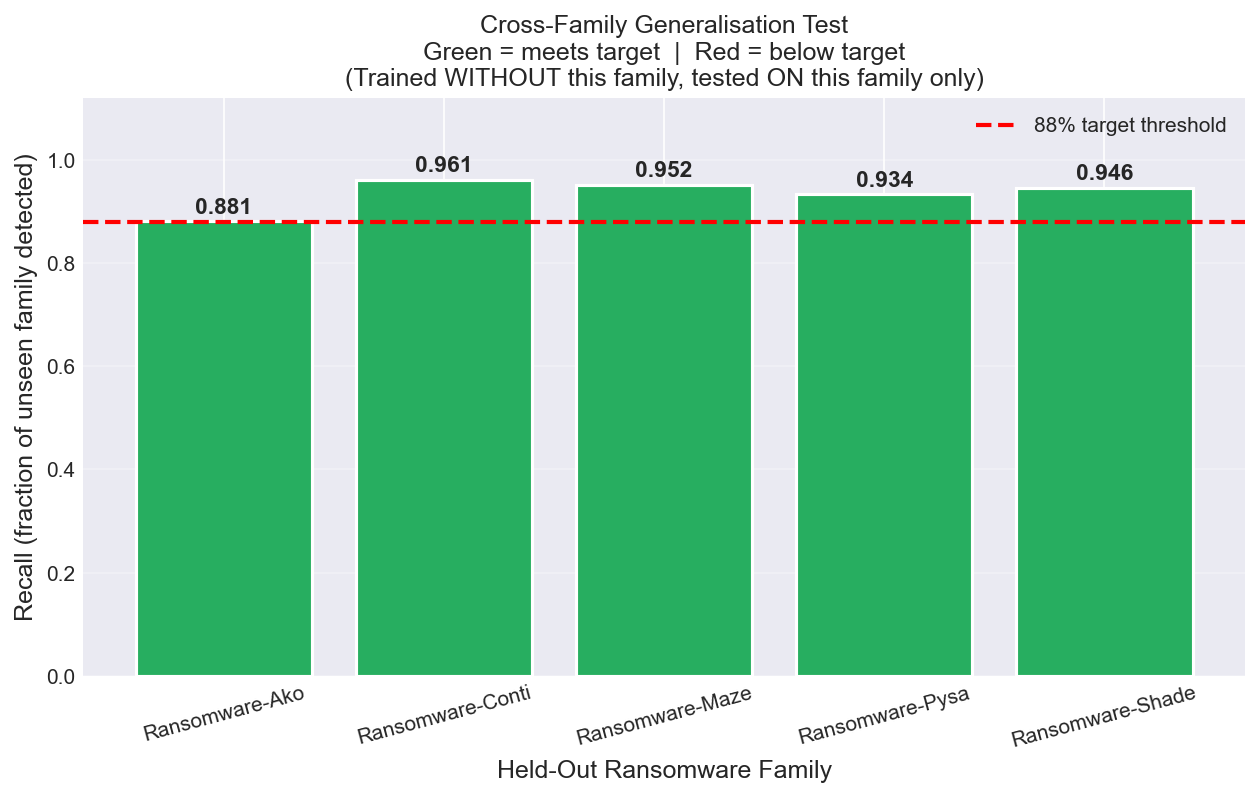

In [119]:
# ── Cross-family bar chart ─────────────────────────────────────────────────────
if family_results:
    cf_df = pd.DataFrame(family_results)

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#27ae60' if r >= 0.88 else '#e74c3c' for r in cf_df['recall']]
    bars   = ax.bar(cf_df['family'], cf_df['recall'], color=colors,
                    edgecolor='white', linewidth=1.5)

    for bar, val in zip(bars, cf_df['recall']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)

    ax.axhline(0.88, color='red', linestyle='--', lw=2,
               label='88% target threshold')
    ax.set_xlabel('Held-Out Ransomware Family', fontsize=12)
    ax.set_ylabel('Recall (fraction of unseen family detected)', fontsize=12)
    ax.set_title('Cross-Family Generalisation Test\n'
                 'Green = meets target  |  Red = below target\n'
                 '(Trained WITHOUT this family, tested ON this family only)',
                 fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

    p = os.path.join(PLOTS_DIR, 'cross_family_generalisation.png')
    fig.savefig(p, dpi=150, bbox_inches='tight')
    plt.close(fig)
    show(p)

In [120]:
# ── Per-family analysis with standard RF (for comparison) ─────────────────────
print('='*65)
print('PER-FAMILY DETECTION RATE (Standard RF — in-distribution)')
print('Trained on ALL families, tested on each family subset')
print('='*65)

# Use the already-trained tuned RF model
per_family_results = []
X_test_rf = rf_tuned_results['X_test']
y_test_rf  = np.array(rf_tuned_results['y_test'])
proba_rf   = rf_tuned_results['test_proba']

# Get categories aligned with test set indices
# We need to reconstruct which test samples belong to which family
# Use the same split seed to reproduce the test set indices
from sklearn.model_selection import train_test_split

_, X_test_orig, _, y_test_idx = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=42)

test_categories = categories.values[:len(y)][y_test_idx.index]

for fam in np.unique(test_categories):
    fam_mask = (test_categories == fam)
    if fam_mask.sum() == 0:
        continue

    y_fam    = y_test_rf[fam_mask]
    p_fam    = proba_rf[fam_mask]
    n_ransom = int(y_fam.sum())
    n_total  = int(fam_mask.sum())

    if n_ransom == 0:
        category_type = 'Benign/Spyware/Trojan'
        # FPR for non-ransomware families
        pred = (p_fam >= rf_tuned.threshold).astype(int)
        fpr  = float(pred.mean())
        per_family_results.append({
            'family': fam, 'type': category_type,
            'n_samples': n_total, 'recall': None, 'fpr': fpr
        })
    else:
        category_type = 'Ransomware'
        pred   = (p_fam >= rf_tuned.threshold).astype(int)
        recall = recall_score(y_fam, pred, zero_division=0)
        per_family_results.append({
            'family': fam, 'type': category_type,
            'n_samples': n_total, 'recall': recall, 'fpr': None
        })

pf_df = pd.DataFrame(per_family_results)
print('\nRansomware families — Recall:')
ransom_df = pf_df[pf_df['type']=='Ransomware'].sort_values('recall')
print(ransom_df[['family','n_samples','recall']].to_string(index=False))

print('\nNon-Ransomware families — False Positive Rate:')
nonransom_df = pf_df[pf_df['type']!='Ransomware'].sort_values('fpr', ascending=False)
print(nonransom_df[['family','n_samples','fpr']].to_string(index=False))

pf_df.to_csv(os.path.join(REPORTS_DIR, 'per_family_results.csv'), index=False)
print(f'\nSaved → reports/per_family_results.csv')

PER-FAMILY DETECTION RATE (Standard RF — in-distribution)
Trained on ALL families, tested on each family subset

Ransomware families — Recall:
          family  n_samples   recall
  Ransomware-Ako        399 0.884712
 Ransomware-Maze        361 0.911357
Ransomware-Conti        385 0.940260
Ransomware-Shade        436 0.942661
 Ransomware-Pysa        377 0.946950

Non-Ransomware families — False Positive Rate:
              family  n_samples      fpr
         Trojan-Zeus        380 0.789474
       Trojan-Emotet        385 0.545455
         Spyware-CWS        366 0.478142
Spyware-180solutions        381 0.464567
         Trojan-Scar        387 0.449612
      Trojan-Reconyc        296 0.371622
 Spyware-Transponder        498 0.317269
       Spyware-Gator        453 0.284768
      Trojan-Refroso        397 0.261965
        Spyware-TIBS        261 0.249042
             Spyware        171 0.134503
              Benign       5957 0.000000

Saved → reports/per_family_results.csv


In [121]:
# ── Final project summary table — generated from actual result objects ─────────
print('='*75)
print('FINAL PROJECT RESULTS SUMMARY — S004 Ransomware Detection System V8')
print('Dataset: CIC-MalMem2022  |  values generated from current notebook run')
print('='*75)

summary_rows = []

def add_summary_row(name, model_type, result_obj, model_obj=None, training_time='run-dependent'):
    if not result_obj:
        return
    row = {
        'Model': name,
        'Type': model_type,
        'Recall': result_obj.get('recall', np.nan),
        'Precision': result_obj.get('precision', np.nan),
        'F1': result_obj.get('f1', np.nan),
        'ROC-AUC': result_obj.get('roc_auc', np.nan),
        'Threshold': getattr(model_obj, 'threshold', result_obj.get('threshold', np.nan)) if model_obj is not None else result_obj.get('threshold', np.nan),
        'Training Time': training_time,
    }
    try:
        row['Meets ≥90% Recall'] = '✓' if float(row['Recall']) >= 0.90 else '✗'
    except Exception:
        row['Meets ≥90% Recall'] = 'N/A'
    summary_rows.append(row)

add_summary_row('RF (default)', 'Supervised', globals().get('rf_results', {}), globals().get('rf', None))
add_summary_row('RF (tuned)', 'Supervised', globals().get('rf_tuned_results', {}), globals().get('rf_tuned', None))
add_summary_row('XGBoost (default)', 'Supervised', globals().get('xgb_results', {}), globals().get('xgb_model', None))
add_summary_row('XGBoost (tuned v2)', 'Supervised', globals().get('xgb_tuned_v2_results', globals().get('xgb_tuned_results', {})), globals().get('xgb_tuned_v2', globals().get('xgb_tuned', None)))
add_summary_row('LightGBM (default)', 'Supervised', globals().get('lgb_results', {}), globals().get('lgb_model', None))
add_summary_row('LightGBM (tuned)', 'Supervised', globals().get('lgb_tuned_results', {}), globals().get('lgb_tuned', None))
add_summary_row('Ensemble (default/V7)', 'Supervised ensemble', globals().get('ens_results', {}), globals().get('ens', None))
add_summary_row('Ensemble (best/V7)', 'Supervised ensemble', globals().get('ens_best_results', {}), globals().get('ens_best', None))
add_summary_row('Isolation Forest', 'Unsupervised', globals().get('if_results', {}), globals().get('iso', None))
add_summary_row('Autoencoder (AE)', 'Unsupervised', globals().get('ae_results', {}), globals().get('ae', None))

summary_df = pd.DataFrame(summary_rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 24)
pd.set_option('display.width', 140)
print(summary_df.to_string(index=False))

print('\nKey interpretation:')
print('  • This table is generated from actual metrics in the current run; no hard-coded ensemble recall.')
print('  • Individual supervised Layer 1 models should remain above the recall target.')
print('  • V8 ensemble uses recall-oriented fusion and is the authoritative ensemble result.')
print('  • Layer 2 CNN is a behavioral suspicion model; process-level EDR actions and regression checks are evaluated in Section 17.')




FINAL PROJECT RESULTS SUMMARY — S004 Ransomware Detection System V8
Dataset: CIC-MalMem2022  |  values generated from current notebook run
                Model                Type   Recall  Precision       F1  ROC-AUC  Threshold Training Time Meets ≥90% Recall
         RF (default)          Supervised 0.911134   0.560830 0.694299 0.954171   0.160000 run-dependent                 ✓
           RF (tuned)          Supervised 0.925434   0.527204 0.671733 0.952341   0.150000 run-dependent                 ✓
    XGBoost (default)          Supervised 0.899898   0.567655 0.696168 0.949604   0.230000 run-dependent                 ✗
   XGBoost (tuned v2)          Supervised 0.899387   0.508078 0.649336 0.938012   0.170000 run-dependent                 ✗
   LightGBM (default)          Supervised 0.923902   0.547684 0.687702 0.955519   0.150000 run-dependent                 ✓
     LightGBM (tuned)          Supervised 0.926966   0.387407 0.546440 0.886254   0.190000 run-dependent                 ✓


## 14 — V8 Improved Layer 2 and Hybrid EDR Orchestrator

### 14.1 — Paths, Configuration, Threshold Modes, and Improvement Flags

In [122]:
# ── 17.1 Paths & V8.1 balanced-mode configuration ───────────────────────────
BEHAVIORAL_RAW_DIR = os.path.join(PROJECT_ROOT, 'data', 'behavioral_raw')
HARD_BENIGN_DIR    = os.path.join(BEHAVIORAL_RAW_DIR, 'hard_benign')
BENIGN_HARD_DIR    = os.path.join(BEHAVIORAL_RAW_DIR, 'benign_hard')
NPZ_CACHE          = os.path.join(PROJECT_ROOT, 'data', 'behavioral_sequences.npz')
CNN_SAVE_DIR       = os.path.join(MODELS_DIR, 'cnn')
CNN_SCALER_PATH    = os.path.join(MODELS_DIR, 'cnn_scaler.pkl')

PIPELINE_VERSION = 'V8.1-hard-benign-balanced'
CNN_WINDOW_SIZE = 8
CNN_STEP_SIZE   = 1

# IMPORTANT: force reprocessing after the V8.1 cache/hard-benign metadata update.
FORCE_REPROCESS_DYNAMIC = True

# Active-encryption labels: preserve mixed CSV labels, relabel all-positive ransomware sessions.
CNN_MAJORITY_FRACTION = 0.25
CNN_RELABEL_POLICY = 'auto_evidence'  # options: preserve, auto_evidence, evidence
LABEL_EVIDENCE_THRESHOLDS = {
    'write_min_bytes': 64 * 1024,
    'read_min_bytes':  16 * 1024,
    'ratio_min': 0.25,
    'cpu_write_min': 1_000_000.0,
    'write_intensity_min': 128.0,
    'cpu_min': 8.0,
    'open_files_min': 2.0,
    'min_hits': 2,
    'dilate_before_ticks': 1,
    'dilate_after_ticks': 2,
    'smooth_ticks': 0,
}

# CNN operating points. V8.1 makes these genuinely distinct.
CNN_RECALL_TARGET   = 0.85
CNN_THRESHOLD_FLOOR = 0.05
CNN_SENSITIVE_MIN_THRESHOLD = 0.05
CNN_BALANCED_MIN_THRESHOLD  = 0.12
CNN_STRICT_MIN_THRESHOLD    = 0.20
CNN_CALIBRATION_METHOD = 'platt'  # options: none, platt, isotonic
CNN_STRICT_FPR_TARGET = 0.20
CNN_BALANCED_FPR_TARGET = 0.35

# Orchestrator policy: balanced mode = preserve detection while preventing unsafe hard actions.
EDR_POLICY_MODE = 'balanced'
CNN_N_CONSECUTIVE       = 3
CNN_SUSPEND_THRESHOLD   = 0.85
CNN_KILL_THRESHOLD      = 0.97
NON_OVERLAPPING_STRIKES = True
REQUIRE_ENCRYPTION_EVIDENCE = True

# Risk accumulator: catches persistent encryption evidence even when CNN outputs are bursty.
L2_RISK_DECAY = 0.85
L2_RISK_SOFT_THRESHOLD = 0.50
L2_EVIDENCE_PERSISTENCE_WINDOWS = 5
L2_STRONG_EVIDENCE_HITS = 5

# Conservative runtime evidence thresholds. These are stricter than label thresholds.
EVIDENCE_THRESHOLDS = {
    'write_min_bytes': 256 * 1024,
    'read_min_bytes':  64 * 1024,
    'ratio_min': 0.50,
    'cpu_write_min': 5_000_000.0,
    'write_intensity_min': 512.0,
    'cpu_min': 15.0,
    'open_files_min': 5.0,
    'min_hits': 3,
}

from src.models.cnn_preprocessor import CNN_FEATURE_COLS_DERIVED, is_hard_benign_path, HARD_BENIGN_FILENAMES
CNN_FEATURE_COLS = CNN_FEATURE_COLS_DERIVED

print('Improved Layer 2 / EDR configuration:')
print(f'  version                  : {PIPELINE_VERSION}')
print(f'  window_size              : {CNN_WINDOW_SIZE} ticks')
print(f'  step_size                : {CNN_STEP_SIZE}')
print(f'  force_reprocess_dynamic  : {FORCE_REPROCESS_DYNAMIC}')
print(f'  relabel_policy           : {CNN_RELABEL_POLICY}')
print(f'  majority_pos_fraction    : {CNN_MAJORITY_FRACTION}')
print(f'  CNN recall target        : {CNN_RECALL_TARGET}')
print(f'  calibration              : {CNN_CALIBRATION_METHOD}')
print(f'  threshold floors         : sensitive={CNN_SENSITIVE_MIN_THRESHOLD}, balanced={CNN_BALANCED_MIN_THRESHOLD}, strict={CNN_STRICT_MIN_THRESHOLD}')
print(f'  strict FPR target        : {CNN_STRICT_FPR_TARGET}')
print(f'  balanced FPR target      : {CNN_BALANCED_FPR_TARGET}')
print(f'  EDR policy mode          : {EDR_POLICY_MODE}')
print(f'  non-overlapping strikes  : {NON_OVERLAPPING_STRIKES}')
print(f'  L2 risk accumulator      : decay={L2_RISK_DECAY}, soft_thr={L2_RISK_SOFT_THRESHOLD}')
print(f'  require evidence gate    : {REQUIRE_ENCRYPTION_EVIDENCE}')
print(f'  suspend / kill thresholds: {CNN_SUSPEND_THRESHOLD} / {CNN_KILL_THRESHOLD}')
print(f'  n_features               : {len(CNN_FEATURE_COLS)}')

print('\nChecking behavioral_raw subfolders and hard-benign controls:')
import glob as _glob
DYNAMIC_OK = True
for sub in ['cerber', 'ryuk', 'wannacry', 'data', 'hard_benign', 'benign_hard']:
    folder = os.path.join(BEHAVIORAL_RAW_DIR, sub)
    if os.path.isdir(folder):
        paths = sorted(_glob.glob(os.path.join(folder, '*.csv')))
        n_csv = len(paths)
        n_hard = sum(is_hard_benign_path(p) for p in paths)
        if sub in ['cerber', 'ryuk', 'wannacry']:
            label = 'ransomware'
        elif sub in ['hard_benign', 'benign_hard']:
            label = 'hard_benign'
        else:
            label = 'benign + hard_benign markers'
        print(f'  ✓  {sub:<12}: {n_csv:>3} CSVs  label={label}  hard_benign_marked={n_hard}')
    else:
        print(f'  -  {sub:<12}: missing')

csv_discovery = discover_raw_csvs(BEHAVIORAL_RAW_DIR)
print('\nDiscovery summary:')
print(f'  ransomware CSVs       : {len(csv_discovery.get("ransomware", []))}')
print(f'  normal benign CSVs    : {len(csv_discovery.get("benign_normal", []))}')
print(f'  hard-benign CSVs      : {len(csv_discovery.get("hard_benign", []))}')
if csv_discovery.get('hard_benign'):
    print('  hard-benign files:')
    for p in csv_discovery['hard_benign']:
        print(f'    - {os.path.relpath(p, PROJECT_ROOT)}')


Improved Layer 2 / EDR configuration:
  version                  : V8.1-hard-benign-balanced
  window_size              : 8 ticks
  step_size                : 1
  force_reprocess_dynamic  : True
  relabel_policy           : auto_evidence
  majority_pos_fraction    : 0.25
  CNN recall target        : 0.85
  calibration              : platt
  threshold floors         : sensitive=0.05, balanced=0.12, strict=0.2
  strict FPR target        : 0.2
  balanced FPR target      : 0.35
  EDR policy mode          : balanced
  non-overlapping strikes  : True
  L2 risk accumulator      : decay=0.85, soft_thr=0.5
  require evidence gate    : True
  suspend / kill thresholds: 0.85 / 0.97
  n_features               : 10

Checking behavioral_raw subfolders and hard-benign controls:
  ✓  cerber      :  10 CSVs  label=ransomware  hard_benign_marked=0
  ✓  ryuk        :  15 CSVs  label=ransomware  hard_benign_marked=0
  ✓  wannacry    :  15 CSVs  label=ransomware  hard_benign_marked=0
  ✓  data        :  31

### 14.2 — Dynamic Preprocessing With Active-Encryption Relabeling and V8 Cache

In [123]:
# ── 17.2 Preprocessing with V8 active-encryption + 25% window label policy ────────────────
CNN_DATA_OK = False
CNN_TRAINED = False
cnn_data    = {}

if DYNAMIC_OK or NPZ_EXISTS:
    print('='*72)
    print('LAYER 2 PREPROCESSING — V8 relabeling + temporal dilation + optional hard-benign folders')
    print('  policy  : preserve mixed CSV labels; relabel all-positive ransomware sessions')
    print('            into active-encryption ticks using read/write/CPU evidence + local dilation')
    print('  scaler  : RobustScaler fit on train ticks only')
    print('  split   : GroupKFold by session/process group')
    print('  cache   : versioned; force_reprocess recommended after label changes')
    print('='*72)

    import importlib
    import src.models.cnn_preprocessor as _prep
    importlib.reload(_prep)
    from src.models.cnn_preprocessor import preprocess_dynamic_telemetry, discover_raw_csvs

    with Timer('CNN preprocessing'):
        cnn_data = preprocess_dynamic_telemetry(
            behavioral_raw_dir    = BEHAVIORAL_RAW_DIR,
            window_size           = CNN_WINDOW_SIZE,
            step_size             = CNN_STEP_SIZE,
            n_folds               = 5,
            scaler_path           = CNN_SCALER_PATH,
            npz_cache             = NPZ_CACHE,
            feature_cols          = CNN_FEATURE_COLS,
            majority_pos_fraction = CNN_MAJORITY_FRACTION,
            relabel_policy        = CNN_RELABEL_POLICY,
            label_evidence_thresholds = LABEL_EVIDENCE_THRESHOLDS,
            force_reprocess       = FORCE_REPROCESS_DYNAMIC,
            verbose               = True,
        )

    n_ben_tr = int((cnn_data['y_train'] == 0).sum())
    n_ran_tr = int((cnn_data['y_train'] == 1).sum())
    n_ben_va = int((cnn_data['y_val']   == 0).sum())
    n_ran_va = int((cnn_data['y_val']   == 1).sum())
    n_ben_te = int((cnn_data['y_test']  == 0).sum())
    n_ran_te = int((cnn_data['y_test']  == 1).sum())

    print('\nData quality summary:')
    print(f'  Train windows : benign={n_ben_tr:,}  ransomware={n_ran_tr:,}')
    print(f'  Val windows   : benign={n_ben_va:,}  ransomware={n_ran_va:,}')
    print(f'  Test windows  : benign={n_ben_te:,}  ransomware={n_ran_te:,}')
    print(f'  input_shape   : {cnn_data["input_shape"]}')
    print(f'  class_weight  : {cnn_data["class_weight"]}')

    if n_ran_tr == 0 or n_ran_va == 0 or n_ran_te == 0:
        print('\n✗ CRITICAL: at least one split has zero ransomware windows. Check label thresholds.')
        CNN_DATA_OK = False
    else:
        print('\n✓ Dynamic dataset is usable for CNN training.')
        print('  Important: ransomware windows should no longer be 100% of ransomware sessions, but should not be too sparse.')
        CNN_DATA_OK = True
else:
    print('⚠  No behavioral data or usable cache found. CNN section will be skipped.')



LAYER 2 PREPROCESSING — V8 relabeling + temporal dilation + optional hard-benign folders
  policy  : preserve mixed CSV labels; relabel all-positive ransomware sessions
            into active-encryption ticks using read/write/CPU evidence + local dilation
  scaler  : RobustScaler fit on train ticks only
  split   : GroupKFold by session/process group
  cache   : versioned; force_reprocess recommended after label changes
  force_reprocess=True — bypassing cache.
  Ransomware CSVs: 40 | Benign CSVs: 20 | Hard-benign CSVs: 11
    labels preserved: ransomware_cerber_001.csv pos=1380/1380 (100.0%)
    labels relabeled: ransomware_cerber_001.csv 1380/1380 → 423/1380 (30.7%) via evidence_active_encryption
    labels preserved: ransomware_cerber_002.csv pos=1316/1316 (100.0%)
    labels relabeled: ransomware_cerber_002.csv 1316/1316 → 309/1316 (23.5%) via evidence_active_encryption
    labels preserved: ransomware_cerber_003.csv pos=2030/2030 (100.0%)
    labels relabeled: ransomware_cerber_0

### 14.3 — CNN Training With Calibration and Threshold Modes

In [124]:
# ── 17.3 Train improved CNN ─────────────────────────────────────────────────
cnn = None
cnn_results = {}

if CNN_DATA_OK:
    try:
        import tensorflow as tf
        import importlib
        import src.models.cnn_model as _cnn_mod
        importlib.reload(_cnn_mod)
        from src.models.cnn_model import RansomwareCNN

        print('='*72)
        print('LAYER 2 — 1D-CNN behavioral monitor')
        print(f'TensorFlow: {tf.__version__}')
        print('Training monitor: val_pr_auc')
        print(f'Calibration: {CNN_CALIBRATION_METHOD}')
        print('Threshold modes: sensitive / balanced / strict')
        print('Layer 2 role: behavioral suspicion, not direct hard-kill authority')
        print('='*72)

        CNN_CONFIG = {
            'window_size'     : CNN_WINDOW_SIZE,
            'n_features'      : cnn_data['input_shape'][1],
            'filters_1'       : 64,
            'filters_2'       : 128,
            'dropout_rate'    : 0.4,
            'learning_rate'   : 5e-4,
            'l2_reg'          : 1e-4,
            'recall_target'   : CNN_RECALL_TARGET,
            'threshold_floor' : CNN_THRESHOLD_FLOOR,
            'calibration_method': CNN_CALIBRATION_METHOD,
            'strict_fpr_target': CNN_STRICT_FPR_TARGET,
            'balanced_fpr_target': CNN_BALANCED_FPR_TARGET,
            'sensitive_min_threshold': CNN_SENSITIVE_MIN_THRESHOLD,
            'balanced_min_threshold': CNN_BALANCED_MIN_THRESHOLD,
            'strict_min_threshold': CNN_STRICT_MIN_THRESHOLD,
            'epochs'          : 80,
            'batch_size'      : 64,
            'random_state'    : RANDOM_SEED,
        }
        print('CNN_CONFIG =')
        for k, v in CNN_CONFIG.items():
            print(f'  {k:<16}: {v}')

        cnn = RansomwareCNN(**CNN_CONFIG)
        os.makedirs(CNN_SAVE_DIR, exist_ok=True)

        with Timer('CNN training'):
            cnn_results = cnn.train(
                data      = cnn_data,
                model_dir = CNN_SAVE_DIR,
            )

        # Attach inference-time preprocessing artifacts for orchestrator use.
        cnn.scaler       = cnn_data['scaler']
        cnn.feature_cols = cnn_data['feature_cols']
        cnn.save(model_dir=CNN_SAVE_DIR, scaler_path=CNN_SCALER_PATH)

        cm = cnn_results.get('confusion_matrix', [[0, 0], [0, 0]])
        tn, fp = cm[0][0], cm[0][1]
        fn, tp = cm[1][0], cm[1][1]

        print('\n✓ CNN training complete')
        print(f'  threshold          : {cnn.threshold:.6f}  (balanced mode)')
        print(f'  recall             : {cnn_results["recall"]:.4f}')
        print(f'  precision          : {cnn_results["precision"]:.4f}')
        print(f'  F1                 : {cnn_results["f1"]:.4f}')
        print(f'  ROC-AUC            : {cnn_results["roc_auc"]:.4f}')
        print(f'  PR-AUC             : {cnn_results["pr_auc"]:.4f}')
        print(f'  FPR                : {cnn_results["fpr"]:.4f}')
        print(f'  specificity        : {cnn_results["specificity"]:.4f}')
        print(f'  balanced_accuracy  : {cnn_results["balanced_accuracy"]:.4f}')
        print(f'  confusion matrix   : TN={tn} FP={fp} FN={fn} TP={tp}')

        print('\nValidation threshold modes:')
        for mode_name, row in cnn_results.get('threshold_modes', {}).items():
            print(f'  {mode_name:<9}: thr={row.get("threshold", np.nan):.4f} recall={row.get("recall", np.nan):.3f} '
                  f'precision={row.get("precision", np.nan):.3f} fpr={row.get("fpr", np.nan):.3f} f1={row.get("f1", np.nan):.3f}')

        if hasattr(cnn, 'probability_diagnostics'):
            diag = cnn.probability_diagnostics()
            print('\nCalibrated probability diagnostics on test split:')
            for cls, vals in diag.items():
                print(f'  {cls:<10}: count={vals["count"]} mean={vals["mean"]:.4f} median={vals["median"]:.4f} p90={vals["p90"]:.4f} p95={vals["p95"]:.4f} max={vals["max"]:.4f}')

        if cnn_results['fpr'] > 0.20:
            print('\n⚠ FPR remains high. Treat CNN as suspicion only and tune with hard-benign controls.')
        CNN_TRAINED = True

    except ImportError:
        print('⚠ TensorFlow is not installed. CNN training skipped.')
        CNN_TRAINED = False
    except Exception as e:
        import traceback; traceback.print_exc()
        CNN_TRAINED = False
else:
    print('Skipping CNN training — run preprocessing first and check label audit.')


LAYER 2 — 1D-CNN behavioral monitor
TensorFlow: 2.21.0
Training monitor: val_pr_auc
Calibration: platt
Threshold modes: sensitive / balanced / strict
Layer 2 role: behavioral suspicion, not direct hard-kill authority
CNN_CONFIG =
  window_size     : 8
  n_features      : 10
  filters_1       : 64
  filters_2       : 128
  dropout_rate    : 0.4
  learning_rate   : 0.0005
  l2_reg          : 0.0001
  recall_target   : 0.85
  threshold_floor : 0.05
  calibration_method: platt
  strict_fpr_target: 0.2
  balanced_fpr_target: 0.35
  sensitive_min_threshold: 0.05
  balanced_min_threshold: 0.12
  strict_min_threshold: 0.2
  epochs          : 80
  batch_size      : 64
  random_state    : 42
Epoch 1/80
578/578 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8768 - auc: 0.6023 - loss: 0.8316 - pr_auc: 0.1256 - precision: 0.1911 - recall: 0.1813 - val_accuracy: 0.9094 - val_auc: 0.5658 - val_loss: 0.6203 - val_pr_auc: 0.1183 - val_precision: 0.2028 - val_recall: 0.0608 - learning_rate: 5.0000e-04
E

### 14.4 — CNN Curves, Threshold-Mode Report, and Metric Registration

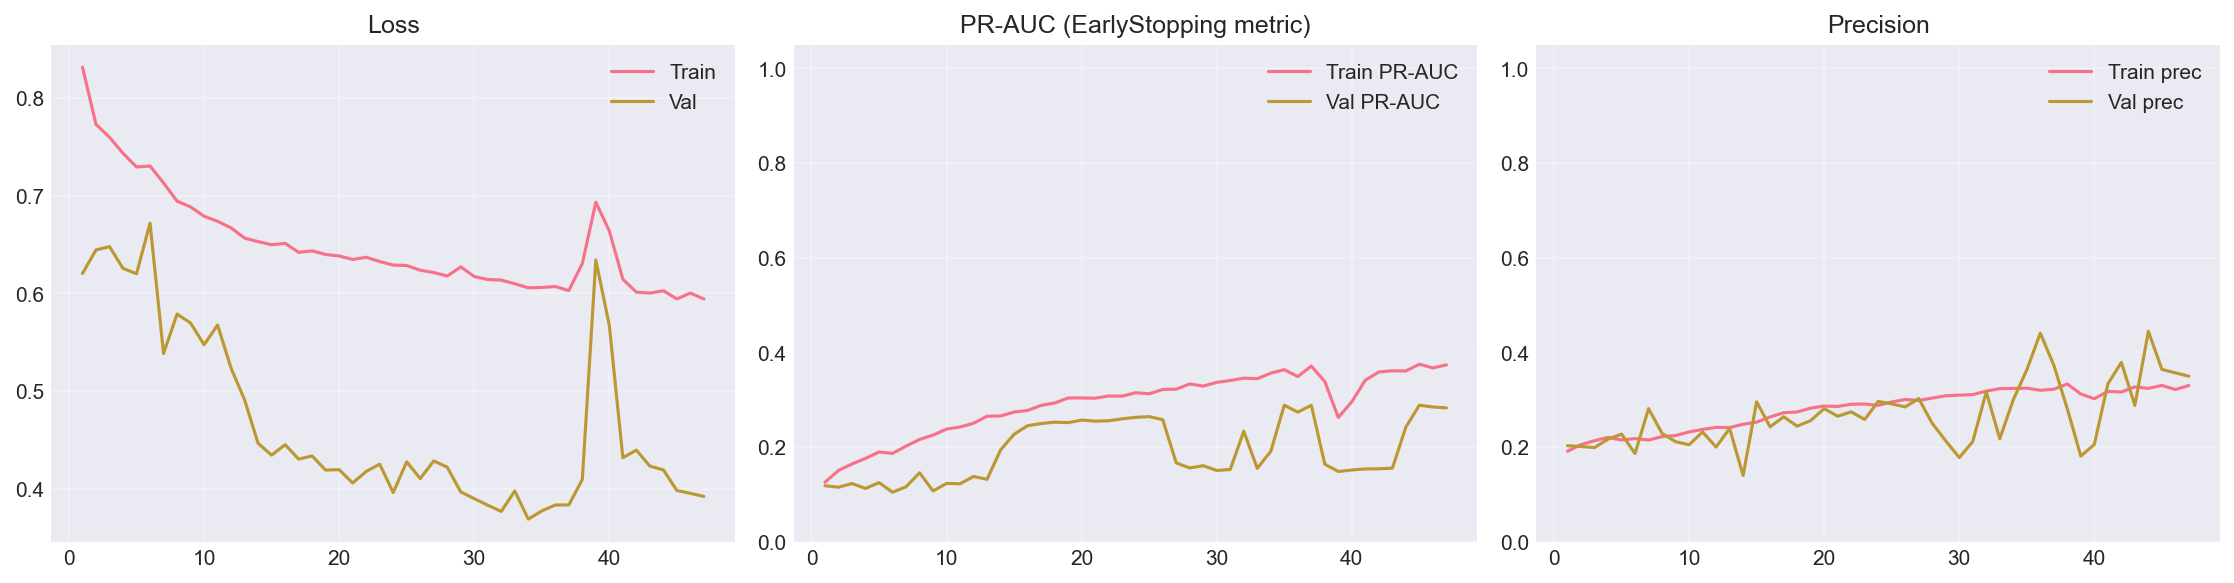

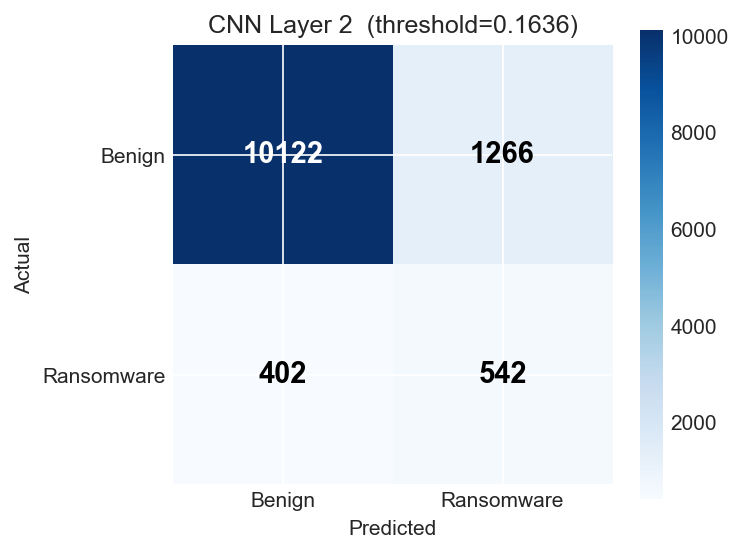


Validation threshold-mode report:


,threshold,recall,precision,f1,fpr,specificity,mode_floor,order_ok
sensitive,0.05067,0.848008,0.173048,0.28744,0.337583,0.662417,0.05,True
balanced,0.163635,0.573375,0.290032,0.385211,0.116923,0.883077,0.12,True
strict,0.2,0.416143,0.325677,0.365393,0.071778,0.928222,0.2,True



Classification Report — Improved CNN Layer 2:
              precision    recall  f1-score   support

      Benign     0.9618    0.8888    0.9239     11388
  Ransomware     0.2998    0.5742    0.3939       944

    accuracy                         0.8647     12332
   macro avg     0.6308    0.7315    0.6589     12332
weighted avg     0.9111    0.8647    0.8833     12332

✓ Improved CNN registered in all_metrics


In [125]:
# ── 17.4 Visualise and register CNN metrics ─────────────────────────────────
if CNN_TRAINED:
    hist_path = os.path.join(PLOTS_DIR, 'cnn_training_history_improved.png')
    cnn.plot_training_history(save_path=hist_path)
    plt.close('all')
    show(hist_path)

    cm_path = os.path.join(PLOTS_DIR, 'cnn_confusion_matrix_improved.png')
    cnn.plot_confusion_matrix(save_path=cm_path)
    plt.close('all')
    show(cm_path)

    from sklearn.metrics import classification_report

    if cnn_results.get('threshold_modes'):
        threshold_modes_df = pd.DataFrame(cnn_results['threshold_modes']).T
        print('\nValidation threshold-mode report:')
        display(threshold_modes_df)
    y_pred_cnn = (cnn_results['test_proba'] >= cnn.threshold).astype(int)
    print('\nClassification Report — Improved CNN Layer 2:')
    print(classification_report(
        cnn_results['y_test'], y_pred_cnn,
        target_names=['Benign', 'Ransomware'],
        digits=4,
        zero_division=0,
    ))

    try:
        m_cnn = security_metrics(
            cnn_results['y_test'], y_pred_cnn, cnn_results['test_proba'],
            'CNN Layer2 Improved (behavioral)'
        )
        # Add metrics returned by the improved CNN that security_metrics may not include.
        for extra_key in ['pr_auc', 'fpr', 'specificity', 'balanced_accuracy']:
            m_cnn[extra_key] = cnn_results.get(extra_key)

        if 'all_metrics' in globals():
            all_metrics = [m for m in all_metrics if m.get('model') != 'CNN Layer2 Improved (behavioral)']
            all_metrics.append(m_cnn)
            print('✓ Improved CNN registered in all_metrics')
    except Exception as e:
        print(f'Could not register CNN in all_metrics: {e}')
else:
    print('CNN not trained — visualisation skipped.')


### 14.5 — Hybrid EDR Orchestrator V8

In [126]:
# ── 17.5 Build improved EDR orchestrator ────────────────────────────────────
import importlib
import src.engine.edr_orchestrator as _edr_mod
importlib.reload(_edr_mod)
EDROrchestrator = _edr_mod.EDROrchestrator
RiskState       = _edr_mod.RiskState

EDR_OK = False
orchestrator = None

if CNN_TRAINED:
    # Prefer the tuned RF from earlier notebook cells. Fall back to standard RF.
    static_model_for_edr = globals().get('rf_tuned', None) or globals().get('rf', None)

    if static_model_for_edr is None:
        print('⚠ No trained Layer 1 static model found in memory. Run RF sections first.')
    else:
        # Ensure feature schema is available for the orchestrator feature_dict path.
        static_model_for_edr.feature_names = list(X.columns)
        print('Layer 1 model selected for EDR:', type(static_model_for_edr).__name__)
        print(f'  feature count : {len(static_model_for_edr.feature_names)}')
        print(f'  threshold     : {getattr(static_model_for_edr, "threshold", 0.5):.4f}')

        try:
            orchestrator = EDROrchestrator(
                static_model               = static_model_for_edr,
                cnn_model                  = cnn,
                l1_threshold               = None,  # use trained static model threshold when available
                n_consecutive              = CNN_N_CONSECUTIVE,
                suspend_threshold          = CNN_SUSPEND_THRESHOLD,
                kill_threshold             = CNN_KILL_THRESHOLD,
                l1_watch_threshold         = 0.10,
                l1_suspicious_threshold    = 0.35,
                l1_high_threshold          = 0.75,
                l1_critical_threshold      = 0.90,
                min_cnn_threshold          = 0.20,
                adaptive_alpha             = 0.35,
                require_encryption_evidence= REQUIRE_ENCRYPTION_EVIDENCE,
                non_overlapping_strikes    = NON_OVERLAPPING_STRIKES,
                l1_decay_tau_seconds       = 60.0,
                l1_decay_floor             = 0.10,
                evidence_thresholds        = EVIDENCE_THRESHOLDS,
                risk_decay                 = L2_RISK_DECAY,
                risk_soft_threshold        = L2_RISK_SOFT_THRESHOLD,
                evidence_persistence_windows = L2_EVIDENCE_PERSISTENCE_WINDOWS,
                strong_evidence_hits       = L2_STRONG_EVIDENCE_HITS,
                policy_mode                = EDR_POLICY_MODE,
                history_max_steps          = 20,
                verbose                    = True,
            )
            EDR_OK = True
            print('\n✓ EDR Orchestrator v8 ready')
            print(f'  L1 decision threshold       : {orchestrator.l1_threshold:.4f}')
            print(f'  base CNN threshold          : {cnn.threshold:.6f}')
            print(f'  non-overlapping strikes     : {orchestrator.non_overlapping_strikes}')
            print(f'  encryption evidence required: {orchestrator.require_encryption_evidence}')
            print(f'  suspend / kill thresholds   : {orchestrator.suspend_threshold} / {orchestrator.kill_threshold}')
            print(f'  risk accumulator            : decay={orchestrator.risk_decay}, soft_thr={orchestrator.risk_soft_threshold}')
            print(f'  EDR policy mode             : {orchestrator.policy_mode}')
            print(f'  CNN threshold modes         : {getattr(cnn, "threshold_modes", {})}')
        except Exception as e:
            import traceback; traceback.print_exc()
else:
    print('CNN not trained — run cells 17.2 and 17.3 first.')



Layer 1 model selected for EDR: RansomwareRandomForest
  feature count : 69
  threshold     : 0.1500

✓ EDR Orchestrator v8 ready
  L1 decision threshold       : 0.1500
  base CNN threshold          : 0.163635
  non-overlapping strikes     : True
  encryption evidence required: True
  suspend / kill thresholds   : 0.85 / 0.97
  risk accumulator            : decay=0.85, soft_thr=0.5
  EDR policy mode             : balanced
  CNN threshold modes         : {'sensitive': {'threshold': 0.0506699220601838, 'recall': 0.8480083857442348, 'precision': 0.17304812834224598, 'f1': 0.2874400426363475, 'fpr': 0.3375829549423681, 'specificity': 0.6624170450576319, 'mode_floor': 0.05, 'order_ok': True}, 'balanced': {'threshold': 0.1636353333311982, 'recall': 0.5733752620545073, 'precision': 0.2900318133616119, 'f1': 0.3852112676056338, 'fpr': 0.11692280824310164, 'specificity': 0.8830771917568984, 'mode_floor': 0.12, 'order_ok': True}, 'strict': {'threshold': 0.2, 'recall': 0.4161425576519916, 'precis

### 14.6 — Orchestrator Regression Tests and Process-Level Outcomes

In [127]:
# ── 17.6 Helper functions for orchestrator tests ─────────────────────────────
from src.models.data_loader import RAW_FEATURE_COLUMNS, engineer_features

def print_event(event, title='SystemEvent'):
    print('\n' + '='*72)
    print(title)
    print('='*72)
    print(f'alert       : {event.alert}')
    print(f'severity    : {event.severity}')
    print(f'source      : {event.model_source}')
    print(f'confidence  : {event.confidence}')
    print(f'actions     : {event.recommended_actions}')
    print(f'description : {event.description}')
    if getattr(event, 'features', None):
        print('features summary:')
        for k, v in list(event.features.items())[:16]:
            if isinstance(v, float):
                print(f'  {k:<28}: {v:.4f}')
            else:
                print(f'  {k:<28}: {v}')


def make_static_vector(base='median', raw_overrides=None):
    """Create a schema-consistent Layer 1 vector aligned to X.columns."""
    raw_overrides = raw_overrides or {}
    if base == 'low':
        raw = X[RAW_FEATURE_COLUMNS].quantile(0.25).to_frame().T
    elif base == 'high':
        raw = X[RAW_FEATURE_COLUMNS].quantile(0.75).to_frame().T
    else:
        raw = X[RAW_FEATURE_COLUMNS].median().to_frame().T

    for col, val in raw_overrides.items():
        if col in raw.columns:
            raw.loc[raw.index[0], col] = float(val)
        else:
            print(f'  warning: raw feature {col} not found; ignored')

    engineered = engineer_features(raw)
    # Align to the exact training/inference schema.
    for col in X.columns:
        if col not in engineered.columns:
            engineered[col] = 0.0
    return engineered[X.columns].iloc[0].astype(float).values


def benign_notepad_stream(n=48, seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(n):
        rows.append({
            'cpu_percent'          : float(rng.uniform(0.5, 5.0)),
            'memory_rss_mb'        : float(rng.uniform(40, 90)),
            'memory_vms_mb'        : float(rng.uniform(160, 260)),
            'io_read_bytes_delta'  : float(rng.uniform(0, 2_000)),
            'io_write_bytes_delta' : float(rng.uniform(0, 2_000)),
            'net_bytes_sent_delta' : float(rng.uniform(0, 100)),
            'num_open_files'       : float(rng.integers(0, 4)),
        })
    return rows


def ransomware_behavior_stream(n=56, encrypt_start=12, seed=7):
    rng = np.random.default_rng(seed)
    rows = []
    for i in range(n):
        encrypting = i >= encrypt_start
        rows.append({
            'cpu_percent'          : float(rng.uniform(82, 99) if encrypting else rng.uniform(1, 5)),
            'memory_rss_mb'        : float(rng.uniform(120, 260)),
            'memory_vms_mb'        : float(rng.uniform(350, 750)),
            'io_read_bytes_delta'  : float(rng.uniform(2_000_000, 8_000_000) if encrypting else rng.uniform(0, 5_000)),
            'io_write_bytes_delta' : float(rng.uniform(4_000_000, 15_000_000) if encrypting else rng.uniform(0, 4_000)),
            'net_bytes_sent_delta' : float(rng.uniform(0, 500)),
            'num_open_files'       : float(rng.integers(80, 200) if encrypting else rng.integers(1, 5)),
        })
    return rows



def extract_process_metrics(event):
    """Convert one SystemEvent into compact process-level metrics.

    V8.4: Always returns both `action` and `actions` for compatibility, and
    carries evidence/risk fields needed by hard-benign and ransomware-specific
    analysis.
    """
    feats = getattr(event, 'features', {}) or {}
    actions_list = list(getattr(event, 'recommended_actions', []) or [])
    action_text = '+'.join(actions_list)
    return {
        'alert': bool(event.alert),
        'severity': event.severity,
        'source': event.model_source,
        'confidence': event.confidence,
        'action': action_text,
        'actions': action_text,
        'max_l2_probability': feats.get('max_l2_probability', feats.get('l2_probability', event.confidence if str(event.model_source).startswith('EDR_Layer2') else np.nan)),
        'max_l2_risk_score': feats.get('max_l2_risk_score', feats.get('l2_risk_score', np.nan)),
        'max_evidence_streak': feats.get('max_evidence_streak', feats.get('evidence_streak', np.nan)),
        'risk_state': feats.get('risk_state', 'unknown'),
        'trigger_reason': feats.get('trigger_reason', 'none'),
        'evidence_hits': feats.get('evidence_hits', np.nan),
        'ransomware_specific_evidence': feats.get('ransomware_specific_evidence', feats.get('ransomware_specific_passed', np.nan)),
        'ransomware_specific_score': feats.get('ransomware_specific_score', np.nan),
        'ransomware_specific_core_present': feats.get('ransomware_specific_core_present', np.nan),
        'ransomware_specific_sustained': feats.get('ransomware_specific_sustained', np.nan),
        'avg_write_bytes': feats.get('avg_write_bytes', np.nan),
        'avg_read_bytes': feats.get('avg_read_bytes', np.nan),
        'max_write_read_ratio': feats.get('max_write_read_ratio', np.nan),
        'max_cpu_x_write': feats.get('max_cpu_x_write', np.nan),
        'max_io_write_intensity': feats.get('max_io_write_intensity', np.nan),
        'avg_cpu_percent': feats.get('avg_cpu_percent', np.nan),
        'max_open_files': feats.get('max_open_files', np.nan),
    }


def print_risk_timeline(event, title='Risk timeline tail'):
    rows = (getattr(event, 'features', {}) or {}).get('risk_timeline_tail', [])
    print('\n' + title)
    if not rows:
        print('  no timeline stored')
        return
    display(pd.DataFrame(rows).tail(12))


In [128]:
# ── TEST 1: benign Notepad-like activity ────────────────────────────────────
if EDR_OK:
    benign_static = make_static_vector(base='low')
    result_notepad = orchestrator.evaluate(
        static_features  = benign_static,
        telemetry_stream = benign_notepad_stream(),
        pid              = 4444,
        process_name     = 'notepad.exe',
        feature_cols      = CNN_FEATURE_COLS,
    )
    print_event(result_notepad, 'TEST 1 — Benign Notepad-like process')

    hard_actions = {'kill_process', 'block_network', 'snapshot_directory'}
    if hard_actions.intersection(set(result_notepad.recommended_actions)):
        print('\n✗ REGRESSION: benign process received hard mitigation.')
    else:
        print('\n✓ PASS: benign process was not hard-blocked.')
else:
    print('EDR not ready — run previous cells first.')


  [L1 Static] P=0.3313 state=WATCH l1_threshold=0.1500
  [L2 CNN] step=  8 P=0.3836 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step=  9 P=0.3845 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 10 P=0.3805 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 11 P=0.3802 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 12 P=0.3790 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 13 P=0.3781 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 14 P=0.3809 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 15 P=0.3780 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 16 P=0.3810 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 17 P=0.378

In [129]:
# ── TEST 2: behavioral ransomware with clean/neutral memory ─────────────────
if EDR_OK:
    clean_memory_static = make_static_vector(base='median')
    result_behavior = orchestrator.evaluate(
        static_features  = clean_memory_static,
        telemetry_stream = ransomware_behavior_stream(),
        pid              = 5555,
        process_name     = 'unknown_encryptor.exe',
        feature_cols      = CNN_FEATURE_COLS,
    )
    print_event(result_behavior, 'TEST 2 — Dynamic encryption behavior')

    print_risk_timeline(result_behavior, 'TEST 2 risk timeline tail')
    if result_behavior.alert and 'suspend_process' in result_behavior.recommended_actions:
        print('\n✓ PASS: dynamic behavior produced a safe SOFT_BLOCK path.')
    elif result_behavior.alert:
        print('\n✓ PASS: dynamic behavior produced an alert. Check whether action is expected.')
    else:
        print('\n⚠ No alert. Inspect CNN threshold modes, evidence thresholds, and risk accumulator.')
else:
    print('EDR not ready — run previous cells first.')


  [L1 Static] P=0.1096 state=WATCH l1_threshold=0.1500
  [L2 CNN] step=  8 P=0.3858 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step=  9 P=0.3890 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 10 P=0.3886 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 11 P=0.3856 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 12 P=0.3818 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 13 P=0.0057 thr=0.2000 state=WATCH evidence=True strikes=0/3 risk=0.107 ev_streak=1
  [L2 CNN] step= 14 P=0.0057 thr=0.2000 state=WATCH evidence=True strikes=0/3 risk=0.220 ev_streak=2
  [L2 CNN] step= 15 P=0.0057 thr=0.2000 state=WATCH evidence=True strikes=0/3 risk=0.315 ev_streak=3
  [L2 CNN] step= 16 P=0.0057 thr=0.2000 state=WATCH evidence=True strikes=0/3 risk=0.397 ev_streak=4
  [L2 CNN] step= 17 P=0.0057 th

,step,l2_probability,cnn_threshold,threshold_mode,evidence_present,evidence_hits,ransomware_specific_evidence,risk_score,evidence_streak,counted_strikes
0,8.0,0.385784,0.2,strict,0.0,1.0,0.0,0.000000,0.0,0.0
1,9.0,0.389039,0.2,strict,0.0,1.0,0.0,0.000000,0.0,0.0
2,10.0,0.388615,0.2,strict,0.0,1.0,0.0,0.000000,0.0,0.0
3,11.0,0.385608,0.2,strict,0.0,1.0,0.0,0.000000,0.0,0.0
4,12.0,0.381806,0.2,strict,0.0,1.0,0.0,0.000000,0.0,0.0
5,13.0,0.005688,0.2,strict,1.0,5.0,0.0,0.107143,1.0,0.0
6,14.0,0.005688,0.2,strict,1.0,6.0,0.0,0.219643,2.0,0.0
7,15.0,0.005688,0.2,strict,1.0,6.0,0.0,0.315268,3.0,0.0
8,16.0,0.005688,0.2,strict,1.0,6.0,0.0,0.396549,4.0,0.0
9,17.0,0.005688,0.2,strict,1.0,6.0,0.0,0.465638,5.0,0.0



✓ PASS: dynamic behavior produced a safe SOFT_BLOCK path.


In [130]:
# ── TEST 3: memory-forensics ransomware signal with engineered features recomputed ──
if EDR_OK:
    memory_overrides = {
        'malfind.ninjections'     : 15.0,
        'malfind.commitCharge'    : 90.0,
        'malfind.uniqueInjections': 10.0,
        'ldrmodules.not_in_load'  : 30.0,
        'ldrmodules.not_in_mem'   : 20.0,
        'psxview.not_in_pslist'   : 5.0,
        'handles.nfile'           : 2500.0,
        'handles.nhandles'        : 12000.0,
    }
    suspicious_static = make_static_vector(base='median', raw_overrides=memory_overrides)
    quiet_stream = benign_notepad_stream(n=24, seed=123)

    result_memory = orchestrator.evaluate(
        static_features  = suspicious_static,
        telemetry_stream = quiet_stream,
        pid              = 6666,
        process_name     = 'memory_suspicious.exe',
        feature_cols      = CNN_FEATURE_COLS,
    )
    print_event(result_memory, 'TEST 3 — Static memory-forensics signal')

    print('\nNote: this synthetic test recomputes engineered features from raw overrides.')
    print('It is a better Layer 1 test than manually assigning inconsistent engineered values.')
else:
    print('EDR not ready — run previous cells first.')


  [L1 Static] P=0.1458 state=WATCH l1_threshold=0.1500
  [L2 CNN] step=  8 P=0.3767 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step=  9 P=0.3767 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 10 P=0.3791 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 11 P=0.3801 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 12 P=0.3804 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 13 P=0.3818 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 14 P=0.3805 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 15 P=0.3797 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 16 P=0.3788 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 17 P=0.380

In [131]:
# ── TEST 4: real ransomware memory row sanity check ─────────────────────────
# This is stronger than the synthetic memory override test because it uses a real
# MalMem ransomware feature vector with the exact trained feature schema.
if EDR_OK:
    try:
        y_arr = np.asarray(y).astype(int)
        ran_indices = np.where(y_arr == 1)[0]
        if len(ran_indices) == 0:
            print('No ransomware rows available for real memory-row test.')
        else:
            # Choose a strongly scored real ransomware row from a small deterministic sample.
            sample_indices = ran_indices[:min(200, len(ran_indices))]
            scored = []
            for ix in sample_indices:
                vec = X.iloc[ix].values.astype(np.float32)
                try:
                    p = orchestrator._l1_prob(vec, pid=7777, process_name='real_memory_row.exe')
                except Exception:
                    p = np.nan
                scored.append((p, ix))
            scored = [(p, ix) for p, ix in scored if np.isfinite(p)]
            if not scored:
                print('Could not score real ransomware rows.')
            else:
                p_best, ix_best = max(scored, key=lambda t: t[0])
                real_static = X.iloc[ix_best].values.astype(np.float32)
                result_real_memory = orchestrator.evaluate(
                    static_features  = real_static,
                    telemetry_stream = benign_notepad_stream(n=24, seed=404),
                    pid              = 7777,
                    process_name     = 'real_ransomware_memory_row.exe',
                    feature_cols      = CNN_FEATURE_COLS,
                )
                print_event(result_real_memory, 'TEST 4 — Real ransomware memory row')
                print(f'Chosen row index: {ix_best} | pre-score L1 probability: {p_best:.4f}')
                print('Expected: SUSPICIOUS/HIGH_RISK/CRITICAL memory state, or at least WATCH if the row is borderline.')
    except Exception as e:
        import traceback; traceback.print_exc()
else:
    print('EDR not ready — run previous cells first.')


  [L1 Static] P=1.0000 state=CRITICAL l1_threshold=0.1500

TEST 4 — Real ransomware memory row
alert       : True
severity    : CRITICAL
source      : EDR_Layer1_Static_CRITICAL
confidence  : 1.0
actions     : ['kill_process', 'snapshot_directory', 'send_alert', 'block_network']
description : HARD BLOCK BY LAYER 1 — static memory probability 100.0% ≥ critical threshold 90%. Latency=31.6ms.
features summary:
  l1_probability              : 1.0000
  risk_state                  : CRITICAL
Chosen row index: 29336 | pre-score L1 probability: 1.0000
Expected: SUSPICIOUS/HIGH_RISK/CRITICAL memory state, or at least WATCH if the row is borderline.


### 14.7 — Process-Level Metrics and Detection Latency

Window-level metrics are useful, but EDR decisions happen at the process level. The improved notebook therefore reports both CNN window-level metrics and orchestrator process-level behavior in the synthetic regression tests above.


In [132]:
# ── 17.7 Window-level + process-level summary, hard-benign tests, regression ──
print('='*72)
print('IMPROVED LAYER 2 / EDR SUMMARY — V8.4 BALANCED MODE')
print('='*72)

if CNN_TRAINED:
    print('Window-level CNN metrics:')
    for k in ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc', 'fpr', 'specificity', 'balanced_accuracy', 'threshold', 'calibration_method']:
        print(f'  {k:<18}: {cnn_results.get(k)}')

    if cnn_results.get('threshold_modes'):
        print('\nThreshold modes available to the orchestrator:')
        threshold_modes_df = pd.DataFrame(cnn_results['threshold_modes']).T
        display(threshold_modes_df)

    if hasattr(cnn, 'probability_diagnostics'):
        print('\nCNN calibrated score distribution:')
        display(pd.DataFrame(cnn.probability_diagnostics()).T)

    # Hard-benign window-level metrics if hard-benign windows landed in the test split.
    if 'test_window_sample_type' in cnn_data and cnn_results.get('test_proba') is not None:
        sample_type = np.asarray(cnn_data['test_window_sample_type']).astype(str)
        y_test_arr = np.asarray(cnn_results['y_test']).astype(int)
        p_test_arr = np.asarray(cnn_results['test_proba'], dtype=float)
        rows = []
        for group_name, mask in [
            ('normal_benign_windows', (y_test_arr == 0) & (sample_type != 'hard_benign')),
            ('hard_benign_windows', sample_type == 'hard_benign'),
            ('ransomware_windows', y_test_arr == 1),
        ]:
            if mask.sum() == 0:
                continue
            for mode_name, row in cnn_results.get('threshold_modes', {'balanced': {'threshold': cnn.threshold}}).items():
                thr = float(row.get('threshold', cnn.threshold)) if isinstance(row, dict) else float(cnn.threshold)
                pred = (p_test_arr[mask] >= thr).astype(int)
                if group_name.endswith('benign_windows'):
                    metric = float(pred.mean())
                    metric_name = 'FPR_at_mode_threshold'
                else:
                    metric = float(pred.mean())
                    metric_name = 'recall_at_mode_threshold'
                rows.append({
                    'group': group_name,
                    'mode': mode_name,
                    'n_windows': int(mask.sum()),
                    'threshold': thr,
                    metric_name: metric,
                    'mean_score': float(np.mean(p_test_arr[mask])),
                    'p95_score': float(np.quantile(p_test_arr[mask], 0.95)),
                })
        if rows:
            print('\nWindow subgroup metrics, including hard-benign if present in test split:')
            subgroup_df = pd.DataFrame(rows)
            display(subgroup_df)
    else:
        print('\nNo window-level sample_type metadata available; rebuild cache with V8.1 if needed.')

    print('\nImportant interpretation:')
    print('  CNN probability is only a behavioral suspicion score.')
    print('  EDR mitigation requires state + persistence/risk accumulation + encryption evidence.')
    print('  Hard-benign process-level tests are more important than raw CNN window FPR.')
else:
    print('CNN was not trained in this run.')

process_rows = []
if EDR_OK:
    for label, name in [('Notepad benign', 'result_notepad'), ('Behavior ransomware', 'result_behavior'), ('Static memory synthetic', 'result_memory'), ('Real ransomware memory row', 'result_real_memory')]:
        if name in globals():
            row = {'test': label}
            row.update(extract_process_metrics(globals()[name]))
            process_rows.append(row)

if process_rows:
    process_df = pd.DataFrame(process_rows)
    print('\nProcess-level regression results:')
    display(process_df)

# ── Hard-benign process-level evaluation ─────────────────────────────────────
def find_hard_benign_paths():
    paths = []
    for folder in [os.path.join(BEHAVIORAL_RAW_DIR, 'data'), HARD_BENIGN_DIR, BENIGN_HARD_DIR]:
        if os.path.isdir(folder):
            for p in sorted(_glob.glob(os.path.join(folder, '*.csv'))):
                if is_hard_benign_path(p):
                    paths.append(p)
    # deterministic unique
    out, seen = [], set()
    for p in paths:
        ap = os.path.abspath(p)
        if ap not in seen:
            seen.add(ap); out.append(p)
    return out

def csv_to_telemetry_stream(path, feature_cols):
    df = pd.read_csv(path)
    if 'step_number' in df.columns:
        df = df.sort_values('step_number')
    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0.0
    stream = []
    for _, row in df.iterrows():
        tick = {c: float(row[c]) for c in feature_cols if c in row}
        if EDR_OK:
            tick = orchestrator._ensure_tick_features(tick, feature_cols)
        stream.append(tick)
    return stream

hard_benign_results = []
if EDR_OK:
    hard_paths = find_hard_benign_paths()
    print('\nHard-benign negative controls:')
    print(f'  discovered files: {len(hard_paths)}')
    for path in hard_paths:
        try:
            stream = csv_to_telemetry_stream(path, CNN_FEATURE_COLS)
            if len(stream) < CNN_WINDOW_SIZE:
                print(f'  skip {os.path.basename(path)} — too few rows')
                continue
            event = orchestrator.evaluate(
                static_features  = make_static_vector(base='median'),
                telemetry_stream = stream,
                pid              = 7000 + len(hard_benign_results),
                process_name     = os.path.basename(path),
                feature_cols      = CNN_FEATURE_COLS,
            )
            row = {'file': os.path.basename(path), 'n_ticks': len(stream)}
            row.update(extract_process_metrics(event))
            hard_benign_results.append(row)
        except Exception as e:
            hard_benign_results.append({'file': os.path.basename(path), 'error': str(e)})

    if hard_benign_results:
        hard_benign_df = pd.DataFrame(hard_benign_results)
        display(hard_benign_df)
        hard_actions = {'kill_process', 'block_network', 'snapshot_directory'}
        n = len(hard_benign_df)
        alert_series = hard_benign_df.get('alert', pd.Series([False]*n, index=hard_benign_df.index)).fillna(False).astype(bool)

        # V8.4 fix: extract_process_metrics() returns `action` singular, while
        # some legacy cells used `actions` plural. Normalize both into one series
        # before counting alert-only, soft-block, and hard-block outcomes.
        if 'action' in hard_benign_df.columns:
            action_series = hard_benign_df['action'].fillna('').astype(str)
        elif 'actions' in hard_benign_df.columns:
            action_series = hard_benign_df['actions'].fillna('').astype(str)
        else:
            action_series = pd.Series(['']*n, index=hard_benign_df.index)

        hard_mask = action_series.apply(lambda x: any(a in x for a in hard_actions))
        soft_mask = action_series.str.contains('suspend_process', regex=False)
        alert_only_mask = alert_series & ~soft_mask & ~hard_mask

        alert_rate = float(alert_series.mean())
        alert_only = int(alert_only_mask.sum())
        soft_blocks = int(soft_mask.sum())
        hard_blocks = int(hard_mask.sum())

        # Store normalized decision class for later summary cells.
        hard_benign_df['decision_class'] = 'safe'
        hard_benign_df.loc[alert_only_mask, 'decision_class'] = 'alert_only'
        hard_benign_df.loc[soft_mask, 'decision_class'] = 'soft_block'
        hard_benign_df.loc[hard_mask, 'decision_class'] = 'hard_block'

        print('\nHard-benign process summary:')
        print(f'  files tested       : {n}')
        print(f'  alert rate         : {alert_rate:.1%}')
        print(f'  alert-only count   : {alert_only}')
        print(f'  soft-block count   : {soft_blocks}')
        print(f'  hard-block count   : {hard_blocks}')
    else:
        print('  No hard-benign files found. Add benign_021.csv–benign_031.csv or use hard_benign/.')

# ── Regression checks ────────────────────────────────────────────────────────
if process_rows:
    hard_actions = {'kill_process', 'block_network', 'snapshot_directory'}
    checks = {
        'Notepad has no alert': not globals().get('result_notepad').alert if 'result_notepad' in globals() else False,
        'Notepad has no hard action': not hard_actions.intersection(set(globals().get('result_notepad').recommended_actions)) if 'result_notepad' in globals() else False,
        'Behavior ransomware alerts': globals().get('result_behavior').alert if 'result_behavior' in globals() else False,
        'Behavior ransomware soft-blocks': ('suspend_process' in globals().get('result_behavior').recommended_actions) if 'result_behavior' in globals() else False,
        'Behavior ransomware does not hard-kill while L1 is WATCH/SAFE': ('kill_process' not in globals().get('result_behavior').recommended_actions) if 'result_behavior' in globals() else False,
        'Synthetic memory is at least WATCH': (globals().get('result_memory').features.get('risk_state') in ['WATCH','SUSPICIOUS','HIGH_RISK','CRITICAL']) if 'result_memory' in globals() else False,
        'Real ransomware memory row is at least WATCH': (globals().get('result_real_memory').features.get('risk_state') in ['WATCH','SUSPICIOUS','HIGH_RISK','CRITICAL']) if 'result_real_memory' in globals() else True,
    }
    if 'hard_benign_df' in globals() and len(hard_benign_df):
        if 'action' in hard_benign_df.columns:
            _hb_action_series = hard_benign_df['action'].fillna('').astype(str)
        elif 'actions' in hard_benign_df.columns:
            _hb_action_series = hard_benign_df['actions'].fillna('').astype(str)
        else:
            _hb_action_series = pd.Series(['']*len(hard_benign_df), index=hard_benign_df.index)
        checks['Hard benign has no hard-blocks'] = not _hb_action_series.apply(lambda x: any(a in x for a in hard_actions)).any()
        checks['Hard benign has no suspensions'] = not _hb_action_series.str.contains('suspend_process', regex=False).any()
    print('\nRegression checks:')
    for k, v in checks.items():
        print(f'  {"✓" if v else "✗"} {k}')


IMPROVED LAYER 2 / EDR SUMMARY — V8.4 BALANCED MODE
Window-level CNN metrics:
  recall            : 0.5742
  precision         : 0.2998
  f1                : 0.3939
  roc_auc           : 0.8476
  pr_auc            : 0.3522
  fpr               : 0.1112
  specificity       : 0.8888
  balanced_accuracy : 0.7315
  threshold         : 0.163635
  calibration_method: platt

Threshold modes available to the orchestrator:


,threshold,recall,precision,f1,fpr,specificity,mode_floor,order_ok
sensitive,0.05067,0.848008,0.173048,0.28744,0.337583,0.662417,0.05,True
balanced,0.163635,0.573375,0.290032,0.385211,0.116923,0.883077,0.12,True
strict,0.2,0.416143,0.325677,0.365393,0.071778,0.928222,0.2,True



CNN calibrated score distribution:


,count,mean,median,p90,p95,max
benign,11388.0,0.066248,0.030738,0.171227,0.219407,0.717242
ransomware,944.0,0.215265,0.184675,0.377229,0.436701,0.941441



Window subgroup metrics, including hard-benign if present in test split:


...


Important interpretation:
  CNN probability is only a behavioral suspicion score.
  EDR mitigation requires state + persistence/risk accumulation + encryption evidence.
  Hard-benign process-level tests are more important than raw CNN window FPR.

Process-level regression results:


,test,alert,severity,source,confidence,action,actions,max_l2_probability,max_l2_risk_score,max_evidence_streak,risk_state,trigger_reason,evidence_hits,ransomware_specific_evidence,ransomware_specific_score,ransomware_specific_core_present,ransomware_specific_sustained,avg_write_bytes,avg_read_bytes,max_write_read_ratio,max_cpu_x_write,max_io_write_intensity,avg_cpu_percent,max_open_files
0,Notepad benign,False,NONE,EDR_SAFE,0.3868,log_event,log_event,0.386775,0.000000,0.0,WATCH,none,1.0,0.0,1.0,0.0,0.0,1.199739e+03,6.309313e+02,8.157414,3.487639e+03,0.027740,1.687069,3.0
1,Behavior ransomware,True,HIGH,EDR_Layer2_CNN_SOFT_...,0.5244,suspend_process+send...,suspend_process+send...,0.524364,0.524364,6.0,WATCH,risk_accumulator_evi...,6.0,1.0,6.0,1.0,1.0,7.235239e+06,3.756870e+06,6.047417,1.197028e+09,84.979820,70.593994,186.0
2,Static memory synthetic,False,NONE,EDR_SAFE,0.3818,log_event,log_event,0.381755,0.000000,0.0,WATCH,none,1.0,0.0,1.0,0.0,0.0,9.950552e+02,1.102831e+03,4.361898,5.285643e+03,0.025554,2.185282,3.0
3,Real ransomware memo...,True,CRITICAL,EDR_Layer1_Static_CR...,1.0000,kill_process+snapsho...,kill_process+snapsho...,NaN,NaN,NaN,CRITICAL,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Hard-benign negative controls:
  discovered files: 11
  [L1 Static] P=0.1096 state=WATCH l1_threshold=0.1500
  [L2 CNN] step=  8 P=0.9414 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step=  9 P=0.9414 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 10 P=0.9414 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 11 P=0.3043 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 12 P=0.4715 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 13 P=0.8073 thr=0.2000 state=WATCH evidence=False strikes=0/3 risk=0.000 ev_streak=0
  [L2 CNN] step= 14 P=0.9414 thr=0.2000 state=WATCH evidence=True strikes=0/3 risk=0.141 ev_streak=1
  [L2 CNN] step= 15 P=0.9414 thr=0.2000 state=WATCH evidence=True strikes=0/3 risk=0.261 ev_streak=2
  [L2 CNN] step= 16 P=0.9414 thr=0.2000 state=WATCH evidence=True strikes=0/

,file,n_ticks,alert,severity,source,confidence,action,actions,max_l2_probability,max_l2_risk_score,max_evidence_streak,risk_state,trigger_reason,evidence_hits,ransomware_specific_evidence,ransomware_specific_score,ransomware_specific_core_present,ransomware_specific_sustained,avg_write_bytes,avg_read_bytes,max_write_read_ratio,max_cpu_x_write,max_io_write_intensity,avg_cpu_percent,max_open_files
0,benign_021.csv,1009,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,send_alert+log_event,0.941441,0.523719,5.0,WATCH,generic_high_io_aler...,3.0,0.0,2.0,0.0,1.0,8714393.000,24930928.00,0.0,0.0,0.0,0.0,20.0
1,benign_022.csv,1170,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.7930,send_alert+log_event,send_alert+log_event,0.792957,0.501433,5.0,WATCH,generic_high_io_aler...,3.0,0.0,1.0,0.0,1.0,671109.625,5553404.00,0.0,0.0,0.0,0.0,20.0
2,benign_023.csv,900,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,send_alert+log_event,0.941441,0.527068,5.0,WATCH,generic_high_io_aler...,3.0,0.0,2.0,0.0,1.0,4389573.000,1512202.25,0.0,0.0,0.0,0.0,10.0
3,benign_024.csv,1043,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,send_alert+log_event,0.941441,0.533062,5.0,WATCH,generic_high_io_aler...,3.0,0.0,2.0,0.0,1.0,4421399.000,1515431.25,0.0,0.0,0.0,0.0,10.0
4,benign_025.csv,2218,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,send_alert+log_event,0.941441,0.575185,5.0,WATCH,generic_high_io_aler...,3.0,0.0,2.0,0.0,1.0,4441962.000,1518660.25,0.0,0.0,0.0,0.0,10.0
5,benign_026.csv,1036,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,send_alert+log_event,0.941441,0.599024,5.0,WATCH,generic_high_io_aler...,3.0,0.0,2.0,0.0,1.0,8719846.000,24819836.00,0.0,0.0,0.0,0.0,8.0
6,benign_027.csv,1166,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,send_alert+log_event,0.941441,0.672215,5.0,WATCH,generic_high_io_aler...,3.0,0.0,2.0,0.0,1.0,8719972.000,24822438.00,0.0,0.0,0.0,0.0,8.0
7,benign_028.csv,1157,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,send_alert+log_event,0.941441,0.587525,5.0,WATCH,generic_high_io_aler...,3.0,0.0,2.0,0.0,1.0,8719972.000,24822438.00,0.0,0.0,0.0,0.0,8.0
8,benign_029.csv,1305,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,send_alert+log_event,0.941441,0.523719,5.0,WATCH,generic_high_io_aler...,3.0,0.0,2.0,0.0,1.0,8744994.000,24883962.00,0.0,0.0,0.0,0.0,20.0
9,benign_030.csv,1208,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,send_alert+log_event,0.941441,0.523719,5.0,WATCH,generic_high_io_aler...,3.0,0.0,2.0,0.0,1.0,4988946.500,1897116.00,0.0,0.0,0.0,0.0,33.0



Hard-benign process summary:
  files tested       : 11
  alert rate         : 100.0%
  alert-only count   : 11
  soft-block count   : 0
  hard-block count   : 0

Regression checks:
  ✓ Notepad has no alert
  ✓ Notepad has no hard action
  ✓ Behavior ransomware alerts
  ✓ Behavior ransomware soft-blocks
  ✓ Behavior ransomware does not hard-kill while L1 is WATCH/SAFE
  ✓ Synthetic memory is at least WATCH
  ✓ Real ransomware memory row is at least WATCH
  ✓ Hard benign has no hard-blocks
  ✓ Hard benign has no suspensions


## 15 — Explainability: Layer 1 Static Explanation and Layer 2 Occlusion

In [133]:
# ── 18.1 Layer 2 CNN occlusion explanation ─────────────────────────────────
if CNN_TRAINED:
    from src.explainability.edr_explain import cnn_occlusion_explanation, select_explainable_windows

    # Prefer a real validation/test window if possible. Synthetic windows are a fallback.
    chosen_window = None
    chosen_prob = None
    chosen_source = None

    # We only have scaled X_test in cnn_data. For raw-window occlusion, use synthetic windows unless
    # a separate raw window source is added later. Select a non-saturated synthetic window.
    for seed in range(90, 240):
        raw_stream = ransomware_behavior_stream(n=28, encrypt_start=4, seed=seed)
        raw_window = []
        for tick in raw_stream[4:4 + CNN_WINDOW_SIZE]:
            tick2 = orchestrator._ensure_tick_features(tick, CNN_FEATURE_COLS) if EDR_OK else tick
            raw_window.append([float(tick2[col]) for col in CNN_FEATURE_COLS])
        candidate = np.array(raw_window, dtype=np.float32)
        prob = cnn.predict_proba_raw_window(candidate, scaler=cnn.scaler)
        if 0.60 <= prob <= 0.95:
            chosen_window = candidate
            chosen_prob = prob
            chosen_source = f'synthetic_seed_{seed}'
            break

    if chosen_window is None:
        print('No non-saturated synthetic window found; using a fixed ransomware window with caution.')
        raw_stream = ransomware_behavior_stream(n=20, encrypt_start=4, seed=99)
        chosen_window = []
        for tick in raw_stream[4:4 + CNN_WINDOW_SIZE]:
            tick2 = orchestrator._ensure_tick_features(tick, CNN_FEATURE_COLS) if EDR_OK else tick
            chosen_window.append([float(tick2[col]) for col in CNN_FEATURE_COLS])
        chosen_window = np.array(chosen_window, dtype=np.float32)
        chosen_prob = cnn.predict_proba_raw_window(chosen_window, scaler=cnn.scaler)
        chosen_source = 'synthetic_seed_99_saturated_fallback'

    print(f'Occlusion selected window source: {chosen_source}')
    occ = cnn_occlusion_explanation(
        cnn_model    = cnn,
        window_raw   = chosen_window,
        feature_cols = CNN_FEATURE_COLS,
        scaler       = cnn.scaler,
        baseline     = 'scaler_center',
        top_k        = 10,
        coherent     = True,
    )
    occ_df = pd.DataFrame(occ)
    if len(occ_df) and 'original_probability' in occ_df.columns:
        chosen_prob = float(occ_df['original_probability'].iloc[0])
    print(f'Occlusion selected window source: {chosen_source}')
    print(f'Occlusion selected original probability: {chosen_prob:.4f}')
    print('Top CNN coherent occlusion explanations:')
    print('  Positive probability_drop means the feature contributed to the ransomware score.')
    display(occ_df)
else:
    print('CNN not trained — occlusion skipped.')


Occlusion selected window source: synthetic_seed_90
Occlusion selected window source: synthetic_seed_90
Occlusion selected original probability: 0.9414
Top CNN coherent occlusion explanations:
  Positive probability_drop means the feature contributed to the ransomware score.


,feature,feature_type,original_probability,occluded_probability,probability_drop,used_calibrated_prediction
0,io_write_bytes_delta,base,0.941441,0.939982,0.00146,True
1,cpu_percent,base,0.941441,0.941441,0.00000,True
2,memory_rss_mb,base,0.941441,0.941441,0.00000,True
3,memory_vms_mb,base,0.941441,0.941441,0.00000,True
4,io_read_bytes_delta,base,0.941441,0.941441,0.00000,True
5,net_bytes_sent_delta,base,0.941441,0.941441,0.00000,True
6,num_open_files,base,0.941441,0.941441,0.00000,True
7,write_read_ratio,derived,0.941441,0.941441,0.00000,True
8,cpu_x_write,derived,0.941441,0.941441,0.00000,True
9,io_write_intensity,derived,0.941441,0.941441,0.00000,True


In [134]:
# ── 18.2 Layer 1 static explanation ─────────────────────────────────────────
if EDR_OK:
    from src.explainability.edr_explain import static_shap_explanation

    static_model_for_explain = orchestrator.static_model
    feature_dict = dict(zip(static_model_for_explain.feature_names, suspicious_static)) if 'suspicious_static' in globals() else dict(zip(static_model_for_explain.feature_names, make_static_vector()))

    static_exp = static_shap_explanation(static_model_for_explain, feature_dict, top_k=12)
    if static_exp:
        print('Top Layer 1 memory explanation features:')
        display(pd.DataFrame(static_exp))
    else:
        print('No SHAP/feature-importance explanation available for this static model object.')
else:
    print('EDR not ready — Layer 1 explanation skipped.')


Top Layer 1 memory explanation features:


,feature,value,importance
0,dlllist.avg_dlls_per...,42.615088,0.071352
1,feat_handles_per_proc,292.682927,0.055117
2,feat_dlls_per_proc,41.878049,0.055111
3,feat_events_per_proc,76.170732,0.052562
4,pslist.avg_handlers,243.136364,0.051569
5,feat_sections_per_proc,5.024390,0.037805
6,handles.avg_handles_...,245.230829,0.037270
7,svcscan.shared_proce...,116.000000,0.033774
8,handles.nsection,206.000000,0.030620
9,handles.nsemaphore,678.000000,0.028413


## 16 — Counterfactual Validation (Experimental Diagnostic)

In [135]:
# ── 19.1 Counterfactual tests for encryption behavior ───────────────────────
if CNN_TRAINED:
    from src.evaluation.counterfactual_tests import run_counterfactual_pair

    # Ransomware-like window: evaluate suppression direction.
    ran_stream = ransomware_behavior_stream(n=18, encrypt_start=4, seed=202)
    ran_window = []
    for tick in ran_stream[4:4 + CNN_WINDOW_SIZE]:
        tick2 = orchestrator._ensure_tick_features(tick, CNN_FEATURE_COLS) if EDR_OK else tick
        ran_window.append([float(tick2[col]) for col in CNN_FEATURE_COLS])
    ran_window = np.array(ran_window, dtype=np.float32)

    # Benign-like window: evaluate injection direction.
    ben_stream = benign_notepad_stream(n=16, seed=303)
    ben_window = []
    for tick in ben_stream[:CNN_WINDOW_SIZE]:
        tick2 = orchestrator._ensure_tick_features(tick, CNN_FEATURE_COLS) if EDR_OK else tick
        ben_window.append([float(tick2[col]) for col in CNN_FEATURE_COLS])
    ben_window = np.array(ben_window, dtype=np.float32)

    cf_ran = run_counterfactual_pair(cnn, ran_window, CNN_FEATURE_COLS, scaler=cnn.scaler)
    cf_ben = run_counterfactual_pair(cnn, ben_window, CNN_FEATURE_COLS, scaler=cnn.scaler)

    cf_df = pd.DataFrame([
        {'window': 'ransomware_like', 'primary_test': 'suppression', **cf_ran},
        {'window': 'benign_like', 'primary_test': 'injection', **cf_ben},
    ])
    display(cf_df)

    print('Interpretation (experimental):')
    print('  ransomware_like: use suppression_drop and valid_suppression_direction.')
    print('  benign_like: use injection_increase and valid_injection_direction.')
    print('  Do not mark saturated ransomware injection as failure; injection is not interpretable when original_probability is already near 1.0.')
else:
    print('CNN not trained — counterfactual tests skipped.')


,window,primary_test,original_probability,suppressed_probability,suppression_drop,injected_probability,injection_increase,valid_suppression_direction,valid_injection_direction,saturated_high,saturated_low,suppression_interpretable,injection_interpretable
0,ransomware_like,suppression,0.941441,0.606219,0.335223,0.941441,0.000000,True,False,False,False,True,True
1,benign_like,injection,0.376123,0.227626,0.148496,0.005688,-0.370435,True,False,False,False,True,True


Interpretation (experimental):
  ransomware_like: use suppression_drop and valid_suppression_direction.
  benign_like: use injection_increase and valid_injection_direction.
  Do not mark saturated ransomware injection as failure; injection is not interpretable when original_probability is already near 1.0.


## 17 — V8.4 Research Hardening: Reproducibility, Contracts, Calibration, and Final Reporting

This section consolidates the final notebook into a research-grade report format. It does not replace the core models; it adds reproducibility, artifact checks, calibration diagnostics, canonical summary tables, process-level metrics, hard-benign analysis, and safety assertions.

In [136]:
# ── 17.1 Reproducibility and environment report ─────────────────────────────
import platform, subprocess, json, os, sys

def _version_of(pkg_name, import_name=None):
    try:
        mod = __import__(import_name or pkg_name)
        return getattr(mod, '__version__', 'unknown')
    except Exception:
        return 'not installed'

repro_info = {
    'python': sys.version.split()[0],
    'platform': platform.platform(),
    'processor': platform.processor(),
    'random_seed': globals().get('RANDOM_STATE', globals().get('RANDOM_SEED', None)),
    'numpy': _version_of('numpy'),
    'pandas': _version_of('pandas'),
    'scikit_learn': _version_of('sklearn'),
    'tensorflow': _version_of('tensorflow'),
    'xgboost': _version_of('xgboost'),
    'lightgbm': _version_of('lightgbm'),
    'imbalanced_learn': _version_of('imblearn'),
    'optuna': _version_of('optuna'),
}
print('Reproducibility report:')
display(pd.DataFrame(repro_info.items(), columns=['item', 'value']))

os.makedirs(REPORTS_DIR, exist_ok=True)
with open(os.path.join(REPORTS_DIR, 'reproducibility_v8_4.json'), 'w', encoding='utf-8') as f:
    json.dump(repro_info, f, indent=2)


Reproducibility report:


,item,value
0,python,3.10.20
1,platform,Windows-10-10.0.2263...
2,processor,AMD64 Family 23 Mode...
3,random_seed,42
4,numpy,2.2.6
5,pandas,2.3.3
6,scikit_learn,1.7.2
7,tensorflow,2.21.0
8,xgboost,3.2.0
9,lightgbm,4.6.0


In [137]:
# ── 17.2 Model artifact contract checks ─────────────────────────────────────
# These checks catch silent deployment bugs: wrong scaler, wrong feature count,
# missing model artifacts, or incompatible threshold metadata.
from pathlib import Path

contract_rows = []

def add_contract(name, expected, actual, status=None, note=''):
    ok = bool(status) if status is not None else (expected == actual)
    contract_rows.append({
        'artifact': name,
        'expected': expected,
        'actual': actual,
        'status': 'PASS' if ok else 'FAIL',
        'note': note,
    })

# CNN contract
if 'cnn' in globals() and cnn is not None:
    add_contract('CNN window_size', CNN_WINDOW_SIZE, getattr(cnn, 'window_size', None))
    add_contract('CNN n_features', len(CNN_FEATURE_COLS), getattr(cnn, 'n_features', None))
    add_contract('CNN scaler feature count', len(CNN_FEATURE_COLS), getattr(getattr(cnn, 'scaler', None), 'n_features_in_', None))
    add_contract('CNN feature_cols', CNN_FEATURE_COLS, list(getattr(cnn, 'feature_cols', []) or []), list(getattr(cnn, 'feature_cols', []) or []) == list(CNN_FEATURE_COLS))
    add_contract('CNN threshold modes present', 'sensitive/balanced/strict', sorted(list(getattr(cnn, 'threshold_modes', {}).keys())), all(k in getattr(cnn, 'threshold_modes', {}) for k in ['sensitive','balanced','strict']))

# Layer 1 contract
if 'rf_tuned' in globals():
    add_contract('RF tuned feature count', X.shape[1], len(getattr(rf_tuned, 'feature_names', [])))
    add_contract('RF tuned scaler feature count', X.shape[1], getattr(getattr(rf_tuned, 'scaler', None), 'n_features_in_', None))
    add_contract('RF tuned threshold present', 'float', type(getattr(rf_tuned, 'threshold', None)).__name__, isinstance(getattr(rf_tuned, 'threshold', None), (float, np.floating)))

if any(k in globals() for k in ['ens_default_v8_results','ens_results']):
    add_contract('V8 ensemble default/balanced results', 'available', 'available', True)
if any(k in globals() for k in ['ens_best_v8_results','ens_best_results']):
    add_contract('V8 ensemble high-recall results', 'available', 'available', True)

# Saved files (best-effort)
for path_name, p in {
    'CNN model dir': globals().get('CNN_SAVE_DIR', os.path.join(MODELS_DIR, 'cnn')),
    'CNN scaler': globals().get('CNN_SCALER_PATH', os.path.join(MODELS_DIR, 'cnn_scaler.pkl')),
    'AE scaler': os.path.join(MODELS_DIR, 'ae_scaler.pkl'),
}.items():
    add_contract(path_name, 'exists', os.path.exists(p), bool(os.path.exists(p)), str(p))

contract_df = pd.DataFrame(contract_rows)
print('Model artifact contract check:')
display(contract_df)
contract_df.to_csv(os.path.join(REPORTS_DIR, 'artifact_contract_v8_4.csv'), index=False)

if (contract_df['status'] == 'FAIL').any():
    print('WARNING: Some artifact contract checks failed. Review before claiming deployment readiness.')


Model artifact contract check:


,artifact,expected,actual,status,note
0,CNN window_size,8,8,PASS,
1,CNN n_features,10,10,PASS,
2,CNN scaler feature c...,10,10,PASS,
3,CNN feature_cols,"[cpu_percent, memory...","[cpu_percent, memory...",PASS,
4,CNN threshold modes ...,sensitive/balanced/s...,"[balanced, sensitive...",PASS,
5,RF tuned feature count,69,69,PASS,
6,RF tuned scaler feat...,69,69,PASS,
7,RF tuned threshold p...,float,float,PASS,
8,V8 ensemble default/...,available,available,PASS,
9,V8 ensemble high-rec...,available,available,PASS,


In [138]:
# ── 17.3 Layer 1 calibration reliability curves ──────────────────────────────
# Reliability curves verify whether calibrated probabilities are meaningful.
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

layer1_calibration_sources = []
for name, res in [
    ('RF tuned', globals().get('rf_tuned_results')),
    ('XGBoost tuned v2', globals().get('xgb_tuned_v2_results', globals().get('xgb_tuned_results'))),
    ('LightGBM tuned', globals().get('lgb_tuned_results')),
]:
    if res and 'test_proba' in res and 'y_test' in res:
        y_cal = np.asarray(res['y_test']).astype(int)
        p_cal = np.asarray(res['test_proba'], dtype=float)
        if len(np.unique(y_cal)) > 1 and len(p_cal) == len(y_cal):
            layer1_calibration_sources.append((name, y_cal, p_cal))

if layer1_calibration_sources:
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    for name, y_cal, p_cal in layer1_calibration_sources:
        frac_pos, mean_pred = calibration_curve(y_cal, p_cal, n_bins=10, strategy='quantile')
        ax.plot(mean_pred, frac_pos, marker='o', label=name)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Observed ransomware frequency')
    ax.set_title('Layer 1 reliability curves')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    fig.savefig(os.path.join(PLOTS_DIR, 'layer1_reliability_curves_v8_4.png'), dpi=150, bbox_inches='tight')
else:
    print('No Layer 1 calibrated probability arrays available for reliability curves.')


In [139]:
# ── 17.4 Canonical model registration and consolidated final summary ─────────
# One canonical summary replaces older legacy/experimental comparison tables.

def canonical_metrics_from_result(name, res, model_obj=None, threshold=None):
    if not res:
        return None
    y_t = np.asarray(res.get('y_test', []))
    if len(y_t) == 0:
        return None
    if 'test_scores' in res and 'test_proba' not in res:
        raw_sc = np.asarray(res['test_scores'])
        p = np.clip(-raw_sc, 0, 1)
        thr = float(threshold if threshold is not None else getattr(model_obj, 'threshold', 0.0))
        pred = (raw_sc < thr).astype(int)
    else:
        p = np.asarray(res.get('test_proba', []), dtype=float)
        if len(p) == 0:
            return None
        if threshold is None:
            if 'ae_normalized_threshold' in res:
                thr = float(res['ae_normalized_threshold'])
            else:
                thr = float(getattr(model_obj, 'threshold', res.get('threshold', 0.5)) if model_obj is not None else res.get('threshold', 0.5))
        else:
            thr = float(threshold)
        pred = (p >= thr).astype(int)
    m = security_metrics(y_t, pred, p, name)
    m['threshold'] = thr
    return m

layer1_rows = []
for name, res, obj in [
    ('RF default', globals().get('rf_results'), globals().get('rf')),
    ('RF tuned', globals().get('rf_tuned_results'), globals().get('rf_tuned')),
    ('XGBoost default', globals().get('xgb_results'), globals().get('xgb_model')),
    ('XGBoost tuned v2', globals().get('xgb_tuned_v2_results', globals().get('xgb_tuned_results')), globals().get('xgb_tuned_v2', globals().get('xgb_tuned'))),
    ('LightGBM default', globals().get('lgb_results'), globals().get('lgb_model')),
    ('LightGBM tuned', globals().get('lgb_tuned_results'), globals().get('lgb_tuned')),
]:
    row = canonical_metrics_from_result(name, res, obj)
    if row:
        layer1_rows.append(row)

anomaly_rows = []
for name, res, obj in [
    ('Isolation Forest', globals().get('if_results'), globals().get('iso')),
    ('Autoencoder', globals().get('ae_results'), globals().get('ae')),
]:
    row = canonical_metrics_from_result(name, res, obj)
    if row:
        anomaly_rows.append(row)

ensemble_rows = []
for name, res, obj in [
    ('Ensemble default/V8.4', globals().get('ens_default_v8_results', globals().get('ens_results')), globals().get('ens_default_v8', globals().get('ens'))),
    ('Ensemble high-recall/V8.4', globals().get('ens_best_v8_results', globals().get('ens_best_results')), globals().get('ens_best_v8', globals().get('ens_best'))),
]:
    row = canonical_metrics_from_result(name, res, obj)
    if row:
        ensemble_rows.append(row)

cnn_rows = []
if 'cnn_results' in globals() and cnn_results:
    cnn_rows.append({
        'model': 'Layer 2 CNN (balanced threshold)',
        'recall': cnn_results.get('recall'),
        'precision': cnn_results.get('precision'),
        'f1': cnn_results.get('f1'),
        'roc_auc': cnn_results.get('roc_auc'),
        'pr_auc': cnn_results.get('pr_auc'),
        'fpr': cnn_results.get('fpr'),
        'specificity': cnn_results.get('specificity'),
        'threshold': cnn_results.get('threshold'),
        'calibration_method': cnn_results.get('calibration_method'),
    })

summary_tables = {
    'Layer 1 supervised models': pd.DataFrame(layer1_rows),
    'Layer 1 ensemble modes': pd.DataFrame(ensemble_rows),
    'Layer 1 anomaly support': pd.DataFrame(anomaly_rows),
    'Layer 2 CNN': pd.DataFrame(cnn_rows),
}

for title, df in summary_tables.items():
    print('\n' + '='*72)
    print(title)
    print('='*72)
    if len(df):
        display(df)
        safe_name = title.lower().replace(' ', '_').replace('/', '_') + '_v8_4.csv'
        df.to_csv(os.path.join(REPORTS_DIR, safe_name), index=False)
    else:
        print('No data available.')



Layer 1 supervised models


,model,recall,precision,f1,roc_auc,avg_precision,brier_score,miss_rate,fpr,threshold_90r,meets_target,threshold
0,RF default,0.911134,0.560830,0.694299,0.954171,0.785340,0.062723,0.088866,0.140656,0.160,True,0.16
1,RF tuned,0.925434,0.527204,0.671733,0.952341,0.780194,0.064438,0.074566,0.163613,0.150,True,0.15
2,XGBoost default,0.899898,0.567655,0.696168,0.949604,0.768247,0.066139,0.100102,0.135119,0.190,True,0.23
3,XGBoost tuned v2,0.899387,0.508078,0.649336,0.938012,0.717860,0.073576,0.100613,0.171667,0.115,True,0.17
4,LightGBM default,0.923902,0.547684,0.687702,0.955519,0.800827,0.061487,0.076098,0.150423,0.155,True,0.15
5,LightGBM tuned,0.926966,0.387407,0.546440,0.886254,0.542290,0.095417,0.073034,0.288965,0.190,True,0.19



Layer 1 ensemble modes


,model,recall,precision,f1,roc_auc,avg_precision,brier_score,miss_rate,fpr,threshold_90r,meets_target,threshold
0,Ensemble default/V8.4,0.876915,0.611685,0.720672,0.957375,0.811962,0.060671,0.123085,0.109746,0.190,False,0.235
1,Ensemble high-recall...,0.852400,0.570014,0.683176,0.944507,0.765468,0.072212,0.147600,0.126762,0.235,False,0.285



Layer 1 anomaly support


,model,recall,precision,f1,roc_auc,avg_precision,brier_score,miss_rate,fpr,threshold_90r,meets_target,threshold
0,Isolation Forest,0.946374,0.335932,0.495852,0.797975,0.318138,0.252659,0.053626,0.368808,0.61,True,-0.610000
1,Autoencoder,0.993871,0.339320,0.505914,0.824363,0.376324,0.170231,0.006129,0.381494,0.10,True,0.000104



Layer 2 CNN


,model,recall,precision,f1,roc_auc,pr_auc,fpr,specificity,threshold,calibration_method
0,Layer 2 CNN (balance...,0.5742,0.2998,0.3939,0.8476,0.3522,0.1112,0.8888,0.163635,platt


In [140]:
# ── 17.5 Process-level EDR confusion matrix, traces, and hard-benign analysis ─
# EDR actions happen at process/session level, so these metrics are more useful
# for deployment than raw CNN window FPR alone.

def _action_text_from_row(row):
    if 'action' in row and pd.notna(row['action']):
        return str(row['action'])
    if 'actions' in row and pd.notna(row['actions']):
        return str(row['actions'])
    return ''

def _decision_class(row):
    action_text = _action_text_from_row(row)
    if any(a in action_text for a in ['kill_process','block_network','snapshot_directory']):
        return 'hard_block'
    if 'suspend_process' in action_text:
        return 'soft_block'
    if bool(row.get('alert', False)):
        return 'alert_only'
    return 'safe'

def _scenario_type(name):
    n = str(name).lower()
    if 'hard benign' in n or 'benign_0' in n:
        return 'hard_benign'
    if 'notepad' in n or 'benign' in n:
        return 'benign'
    if 'behavior' in n or 'ransomware' in n:
        return 'ransomware'
    if 'memory' in n:
        return 'memory_test'
    return 'other'

all_process_eval = []
if 'process_df' in globals() and isinstance(process_df, pd.DataFrame):
    tmp = process_df.copy()
    tmp['scenario_type'] = tmp['test'].map(_scenario_type)
    all_process_eval.append(tmp)
if 'hard_benign_df' in globals() and isinstance(hard_benign_df, pd.DataFrame) and len(hard_benign_df):
    tmp = hard_benign_df.copy()
    tmp['test'] = tmp.get('file', 'hard_benign')
    tmp['scenario_type'] = 'hard_benign'
    all_process_eval.append(tmp)

if all_process_eval:
    process_eval_df = pd.concat(all_process_eval, ignore_index=True, sort=False)
    process_eval_df['decision_class'] = process_eval_df.apply(_decision_class, axis=1)
    print('Process-level EDR outcomes:')
    display(process_eval_df)
    process_eval_df.to_csv(os.path.join(REPORTS_DIR, 'edr_process_outcomes_v8_4.csv'), index=False)

    confusion = pd.crosstab(process_eval_df['scenario_type'], process_eval_df['decision_class'], dropna=False)
    print('\nEDR process-level outcome matrix:')
    display(confusion)
    confusion.to_csv(os.path.join(REPORTS_DIR, 'edr_process_confusion_v8_4.csv'))

    decision_cols = [c for c in ['test','file','scenario_type','alert','severity','source','confidence','action','risk_state','max_l2_probability','max_l2_risk_score','max_evidence_streak','trigger_reason','decision_class'] if c in process_eval_df.columns]
    print('\nDecision trace table:')
    display(process_eval_df[decision_cols])

    # Safety assertions
    unsafe_hard = (process_eval_df[(process_eval_df['risk_state'].isin(['SAFE','WATCH'])) & (process_eval_df['decision_class'] == 'hard_block')] if 'risk_state' in process_eval_df.columns else pd.DataFrame())
    assert len(unsafe_hard) == 0, 'Safety violation: hard block while Layer 1 was SAFE/WATCH.'
    if 'hard_benign_df' in globals() and len(hard_benign_df):
        hb_decisions = process_eval_df[process_eval_df['scenario_type'] == 'hard_benign']
        assert not (hb_decisions['decision_class'] == 'hard_block').any(), 'Hard benign received hard block.'
        print('\nHard-benign regression: no hard block ✓')
        if (hb_decisions['decision_class'] == 'soft_block').any():
            print('WARNING: Some hard-benign cases still soft-block. Review evidence thresholds/policy.')
        else:
            print('Hard-benign regression: no suspension ✓')
else:
    print('No process-level EDR result tables found yet. Run Section 14.6–14.7 first.')


Process-level EDR outcomes:


,test,alert,severity,source,confidence,action,actions,max_l2_probability,max_l2_risk_score,max_evidence_streak,risk_state,trigger_reason,evidence_hits,ransomware_specific_evidence,ransomware_specific_score,ransomware_specific_core_present,ransomware_specific_sustained,avg_write_bytes,avg_read_bytes,max_write_read_ratio,max_cpu_x_write,max_io_write_intensity,avg_cpu_percent,max_open_files,scenario_type,file,n_ticks,decision_class
0,Notepad benign,False,NONE,EDR_SAFE,0.3868,log_event,log_event,0.386775,0.000000,0.0,WATCH,none,1.0,0.0,1.0,0.0,0.0,1.199739e+03,6.309313e+02,8.157414,3.487639e+03,0.027740,1.687069,3.0,benign,NaN,NaN,safe
1,Behavior ransomware,True,HIGH,EDR_Layer2_CNN_SOFT_...,0.5244,suspend_process+send...,suspend_process+send...,0.524364,0.524364,6.0,WATCH,risk_accumulator_evi...,6.0,1.0,6.0,1.0,1.0,7.235239e+06,3.756870e+06,6.047417,1.197028e+09,84.979820,70.593994,186.0,ransomware,NaN,NaN,soft_block
2,Static memory synthetic,False,NONE,EDR_SAFE,0.3818,log_event,log_event,0.381755,0.000000,0.0,WATCH,none,1.0,0.0,1.0,0.0,0.0,9.950552e+02,1.102831e+03,4.361898,5.285643e+03,0.025554,2.185282,3.0,memory_test,NaN,NaN,safe
3,Real ransomware memo...,True,CRITICAL,EDR_Layer1_Static_CR...,1.0000,kill_process+snapsho...,kill_process+snapsho...,NaN,NaN,NaN,CRITICAL,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ransomware,NaN,NaN,hard_block
4,benign_021.csv,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,send_alert+log_event,0.941441,0.523719,5.0,WATCH,generic_high_io_aler...,3.0,0.0,2.0,0.0,1.0,8.714393e+06,2.493093e+07,0.000000,0.000000e+00,0.000000,0.000000,20.0,hard_benign,benign_021.csv,1009.0,alert_only
5,benign_022.csv,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.7930,send_alert+log_event,send_alert+log_event,0.792957,0.501433,5.0,WATCH,generic_high_io_aler...,3.0,0.0,1.0,0.0,1.0,6.711096e+05,5.553404e+06,0.000000,0.000000e+00,0.000000,0.000000,20.0,hard_benign,benign_022.csv,1170.0,alert_only
6,benign_023.csv,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,send_alert+log_event,0.941441,0.527068,5.0,WATCH,generic_high_io_aler...,3.0,0.0,2.0,0.0,1.0,4.389573e+06,1.512202e+06,0.000000,0.000000e+00,0.000000,0.000000,10.0,hard_benign,benign_023.csv,900.0,alert_only
7,benign_024.csv,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,send_alert+log_event,0.941441,0.533062,5.0,WATCH,generic_high_io_aler...,3.0,0.0,2.0,0.0,1.0,4.421399e+06,1.515431e+06,0.000000,0.000000e+00,0.000000,0.000000,10.0,hard_benign,benign_024.csv,1043.0,alert_only
8,benign_025.csv,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,send_alert+log_event,0.941441,0.575185,5.0,WATCH,generic_high_io_aler...,3.0,0.0,2.0,0.0,1.0,4.441962e+06,1.518660e+06,0.000000,0.000000e+00,0.000000,0.000000,10.0,hard_benign,benign_025.csv,2218.0,alert_only
9,benign_026.csv,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,send_alert+log_event,0.941441,0.599024,5.0,WATCH,generic_high_io_aler...,3.0,0.0,2.0,0.0,1.0,8.719846e+06,2.481984e+07,0.000000,0.000000e+00,0.000000,0.000000,8.0,hard_benign,benign_026.csv,1036.0,alert_only



EDR process-level outcome matrix:


decision_class,alert_only,hard_block,safe,soft_block
scenario_type,,,,
benign,0,0,1,0
hard_benign,11,0,0,0
memory_test,0,0,1,0
ransomware,0,1,0,1



Decision trace table:


,test,file,scenario_type,alert,severity,source,confidence,action,risk_state,max_l2_probability,max_l2_risk_score,max_evidence_streak,trigger_reason,decision_class
0,Notepad benign,NaN,benign,False,NONE,EDR_SAFE,0.3868,log_event,WATCH,0.386775,0.000000,0.0,none,safe
1,Behavior ransomware,NaN,ransomware,True,HIGH,EDR_Layer2_CNN_SOFT_...,0.5244,suspend_process+send...,WATCH,0.524364,0.524364,6.0,risk_accumulator_evi...,soft_block
2,Static memory synthetic,NaN,memory_test,False,NONE,EDR_SAFE,0.3818,log_event,WATCH,0.381755,0.000000,0.0,none,safe
3,Real ransomware memo...,NaN,ransomware,True,CRITICAL,EDR_Layer1_Static_CR...,1.0000,kill_process+snapsho...,CRITICAL,NaN,NaN,NaN,none,hard_block
4,benign_021.csv,benign_021.csv,hard_benign,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,WATCH,0.941441,0.523719,5.0,generic_high_io_aler...,alert_only
5,benign_022.csv,benign_022.csv,hard_benign,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.7930,send_alert+log_event,WATCH,0.792957,0.501433,5.0,generic_high_io_aler...,alert_only
6,benign_023.csv,benign_023.csv,hard_benign,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,WATCH,0.941441,0.527068,5.0,generic_high_io_aler...,alert_only
7,benign_024.csv,benign_024.csv,hard_benign,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,WATCH,0.941441,0.533062,5.0,generic_high_io_aler...,alert_only
8,benign_025.csv,benign_025.csv,hard_benign,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,WATCH,0.941441,0.575185,5.0,generic_high_io_aler...,alert_only
9,benign_026.csv,benign_026.csv,hard_benign,True,MEDIUM,EDR_Layer2_ALERT_ONL...,0.9414,send_alert+log_event,WATCH,0.941441,0.599024,5.0,generic_high_io_aler...,alert_only



Hard-benign regression: no hard block ✓
Hard-benign regression: no suspension ✓


In [141]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score
import numpy as np
import pandas as pd

# ── 17.6 CNN threshold sensitivity analysis ─────────────────────────────────
# Shows how recall/FPR/precision trade off under different probability thresholds.
if CNN_TRAINED and cnn_results.get('test_proba') is not None:
    y_te = np.asarray(cnn_results['y_test']).astype(int)
    p_te = np.asarray(cnn_results['test_proba'], dtype=float)
    rows = []
    candidate_thresholds = sorted(set(
        [float(cnn_results.get('threshold', 0.5))]
        + [float(v.get('threshold')) for v in cnn_results.get('threshold_modes', {}).values() if isinstance(v, dict) and 'threshold' in v]
        + list(np.round(np.linspace(0.05, 0.95, 19), 3))
    ))
    for thr in candidate_thresholds:
        pred = (p_te >= thr).astype(int)
        cm = confusion_matrix(y_te, pred, labels=[0,1])
        tn, fp, fn, tp = cm.ravel()
        rows.append({
            'threshold': thr,
            'recall': recall_score(y_te, pred, zero_division=0),
            'precision': precision_score(y_te, pred, zero_division=0),
            'f1': f1_score(y_te, pred, zero_division=0),
            'fpr': fp / max(fp + tn, 1),
            'specificity': tn / max(tn + fp, 1),
        })
    threshold_sensitivity_df = pd.DataFrame(rows).sort_values('threshold')
    print('CNN threshold sensitivity table:')
    display(threshold_sensitivity_df)
    threshold_sensitivity_df.to_csv(os.path.join(REPORTS_DIR, 'cnn_threshold_sensitivity_v8_4.csv'), index=False)

    fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(threshold_sensitivity_df['threshold'], threshold_sensitivity_df['recall'], marker='o', label='recall')
    ax.plot(threshold_sensitivity_df['threshold'], threshold_sensitivity_df['fpr'], marker='o', label='FPR')
    ax.plot(threshold_sensitivity_df['threshold'], threshold_sensitivity_df['precision'], marker='o', label='precision')
    ax.set_xlabel('CNN threshold')
    ax.set_ylabel('Metric')
    ax.set_title('CNN threshold sensitivity')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    fig.savefig(os.path.join(PLOTS_DIR, 'cnn_threshold_sensitivity_v8_4.png'), dpi=150, bbox_inches='tight')
else:
    print('CNN threshold sensitivity skipped.')


CNN threshold sensitivity table:


,threshold,recall,precision,f1,fpr,specificity
0,0.050000,0.891949,0.179493,0.298846,0.337987,0.662013
1,0.050670,0.891949,0.180881,0.300768,0.334826,0.665174
2,0.100000,0.754237,0.236388,0.359960,0.201967,0.798033
3,0.150000,0.633475,0.282876,0.391105,0.133123,0.866877
4,0.163635,0.574153,0.299779,0.393895,0.111170,0.888830
5,0.163635,0.574153,0.299779,0.393895,0.111170,0.888830
6,0.200000,0.440678,0.342951,0.385721,0.069986,0.930014
7,0.250000,0.314619,0.450000,0.370324,0.031876,0.968124
8,0.300000,0.242585,0.449902,0.315210,0.024587,0.975413
9,0.350000,0.204449,0.492347,0.288922,0.017475,0.982525


In [142]:
# ── 17.7 Hard-benign reason analysis ────────────────────────────────────────
# Helps diagnose whether hard-benign alerts are caused by generic high I/O or
# ransomware-specific evidence.
if 'hard_benign_df' in globals() and isinstance(hard_benign_df, pd.DataFrame) and len(hard_benign_df):
    reason_cols = [c for c in [
        'file','alert','severity','source','action','risk_state','trigger_reason',
        'max_l2_probability','max_l2_risk_score','max_evidence_streak',
        'avg_write_bytes','avg_read_bytes','max_write_read_ratio','max_cpu_x_write',
        'max_io_write_intensity','avg_cpu_percent','max_open_files',
        'evidence_hits','ransomware_specific_evidence'
    ] if c in hard_benign_df.columns]
    print('Hard-benign reason analysis:')
    display(hard_benign_df[reason_cols])
    hard_benign_df[reason_cols].to_csv(os.path.join(REPORTS_DIR, 'hard_benign_reason_analysis_v8_4.csv'), index=False)
else:
    print('No hard-benign results available yet.')


Hard-benign reason analysis:


,file,alert,severity,source,action,risk_state,trigger_reason,max_l2_probability,max_l2_risk_score,max_evidence_streak,avg_write_bytes,avg_read_bytes,max_write_read_ratio,max_cpu_x_write,max_io_write_intensity,avg_cpu_percent,max_open_files,evidence_hits,ransomware_specific_evidence
0,benign_021.csv,True,MEDIUM,EDR_Layer2_ALERT_ONL...,send_alert+log_event,WATCH,generic_high_io_aler...,0.941441,0.523719,5.0,8714393.000,24930928.00,0.0,0.0,0.0,0.0,20.0,3.0,0.0
1,benign_022.csv,True,MEDIUM,EDR_Layer2_ALERT_ONL...,send_alert+log_event,WATCH,generic_high_io_aler...,0.792957,0.501433,5.0,671109.625,5553404.00,0.0,0.0,0.0,0.0,20.0,3.0,0.0
2,benign_023.csv,True,MEDIUM,EDR_Layer2_ALERT_ONL...,send_alert+log_event,WATCH,generic_high_io_aler...,0.941441,0.527068,5.0,4389573.000,1512202.25,0.0,0.0,0.0,0.0,10.0,3.0,0.0
3,benign_024.csv,True,MEDIUM,EDR_Layer2_ALERT_ONL...,send_alert+log_event,WATCH,generic_high_io_aler...,0.941441,0.533062,5.0,4421399.000,1515431.25,0.0,0.0,0.0,0.0,10.0,3.0,0.0
4,benign_025.csv,True,MEDIUM,EDR_Layer2_ALERT_ONL...,send_alert+log_event,WATCH,generic_high_io_aler...,0.941441,0.575185,5.0,4441962.000,1518660.25,0.0,0.0,0.0,0.0,10.0,3.0,0.0
5,benign_026.csv,True,MEDIUM,EDR_Layer2_ALERT_ONL...,send_alert+log_event,WATCH,generic_high_io_aler...,0.941441,0.599024,5.0,8719846.000,24819836.00,0.0,0.0,0.0,0.0,8.0,3.0,0.0
6,benign_027.csv,True,MEDIUM,EDR_Layer2_ALERT_ONL...,send_alert+log_event,WATCH,generic_high_io_aler...,0.941441,0.672215,5.0,8719972.000,24822438.00,0.0,0.0,0.0,0.0,8.0,3.0,0.0
7,benign_028.csv,True,MEDIUM,EDR_Layer2_ALERT_ONL...,send_alert+log_event,WATCH,generic_high_io_aler...,0.941441,0.587525,5.0,8719972.000,24822438.00,0.0,0.0,0.0,0.0,8.0,3.0,0.0
8,benign_029.csv,True,MEDIUM,EDR_Layer2_ALERT_ONL...,send_alert+log_event,WATCH,generic_high_io_aler...,0.941441,0.523719,5.0,8744994.000,24883962.00,0.0,0.0,0.0,0.0,20.0,3.0,0.0
9,benign_030.csv,True,MEDIUM,EDR_Layer2_ALERT_ONL...,send_alert+log_event,WATCH,generic_high_io_aler...,0.941441,0.523719,5.0,4988946.500,1897116.00,0.0,0.0,0.0,0.0,33.0,3.0,0.0


In [143]:
# ── 17.8 SHAP summary / beeswarm for Layer 1 (optional) ─────────────────────
# This is more informative than mean feature importance because it shows feature
# direction and magnitude across samples. It is optional because SHAP may not be
# installed in every environment.
try:
    import shap
    shap_available = True
except Exception as e:
    shap_available = False
    print(f'SHAP not available: {e}')

if shap_available and 'rf_tuned' in globals():
    try:
        # Use a small sample for speed in class/demo environments.
        X_shap = X.sample(n=min(500, len(X)), random_state=RANDOM_SEED)
        model_for_shap = getattr(rf_tuned, 'model', rf_tuned)
        scaler_for_shap = getattr(rf_tuned, 'scaler', None)
        X_shap_in = scaler_for_shap.transform(X_shap) if scaler_for_shap is not None else X_shap.values
        explainer = shap.TreeExplainer(model_for_shap)
        shap_values = explainer.shap_values(X_shap_in)
        # Binary tree models may return a list; class 1 is ransomware.
        sv = shap_values[1] if isinstance(shap_values, list) and len(shap_values) > 1 else shap_values
        shap.summary_plot(sv, X_shap, show=False, max_display=20)
        plt.title('Layer 1 RF tuned SHAP summary')
        plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIR, 'layer1_rf_shap_summary_v8_4.png'), dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f'SHAP summary skipped: {e}')
else:
    print('SHAP summary skipped. Install shap to enable this plot.')


SHAP not available: No module named 'shap'
SHAP summary skipped. Install shap to enable this plot.


## 18 — Demo Safety Policy, Deployment Policy, Limitations, and Future Work

In [144]:
# ── 18.1 Safe demo mode and protected-process policy ────────────────────────
PROTECTED_WINDOWS_PROCESSES = [
    'system', 'registry', 'smss.exe', 'csrss.exe', 'wininit.exe', 'winlogon.exe',
    'services.exe', 'lsass.exe', 'svchost.exe', 'explorer.exe', 'dwm.exe',
]
PROTECTED_LINUX_PROCESSES = [
    'init', 'systemd', 'sshd', 'bash', 'zsh', 'gnome-shell', 'xorg', 'wayland',
]

demo_safety_policy = pd.DataFrame([
    {'mode': 'dry-run', 'behavior': 'Print WOULD SUSPEND/WOULD KILL, do not perform mitigation', 'recommended_for': 'presentation and normal testing'},
    {'mode': 'demo-only mitigation', 'behavior': 'May suspend/terminate only processes launched by the demo runner', 'recommended_for': 'controlled VM demonstration'},
    {'mode': 'full mitigation', 'behavior': 'Can suspend/kill allowed non-system processes', 'recommended_for': 'isolated VM only'},
])
print('Safe demo policy:')
display(demo_safety_policy)
print('Protected Windows process examples:', PROTECTED_WINDOWS_PROCESSES)
print('Protected Linux process examples:', PROTECTED_LINUX_PROCESSES)


Safe demo policy:


,mode,behavior,recommended_for
0,dry-run,Print WOULD SUSPEND/...,presentation and nor...
1,demo-only mitigation,May suspend/terminat...,controlled VM demons...
2,full mitigation,Can suspend/kill all...,isolated VM only


Protected Windows process examples: ['system', 'registry', 'smss.exe', 'csrss.exe', 'wininit.exe', 'winlogon.exe', 'services.exe', 'lsass.exe', 'svchost.exe', 'explorer.exe', 'dwm.exe']
Protected Linux process examples: ['init', 'systemd', 'sshd', 'bash', 'zsh', 'gnome-shell', 'xorg', 'wayland']


In [145]:
# ── 18.2 Recommended deployment decision policy ─────────────────────────────
deployment_policy_df = pd.DataFrame([
    {'Layer 1 state': 'SAFE', 'Layer 2 evidence': 'low/no evidence', 'action': 'log_event', 'rationale': 'No meaningful threat signal'},
    {'Layer 1 state': 'SAFE/WATCH', 'Layer 2 evidence': 'generic high I/O only', 'action': 'alert_only + log_event', 'rationale': 'Avoid blocking backup/compression/copy workloads'},
    {'Layer 1 state': 'SAFE/WATCH', 'Layer 2 evidence': 'ransomware-specific persistent evidence', 'action': 'suspend_process + alert', 'rationale': 'Contain possible encryption while preserving safety'},
    {'Layer 1 state': 'SUSPICIOUS/HIGH_RISK', 'Layer 2 evidence': 'persistent encryption evidence', 'action': 'hard block allowed', 'rationale': 'Both memory and behavior support ransomware verdict'},
    {'Layer 1 state': 'CRITICAL', 'Layer 2 evidence': 'not required', 'action': 'hard block allowed', 'rationale': 'Static memory forensics is already critical'},
])
print('Recommended EDR deployment policy:')
display(deployment_policy_df)
deployment_policy_df.to_csv(os.path.join(REPORTS_DIR, 'recommended_deployment_policy_v8_4.csv'), index=False)


Recommended EDR deployment policy:


,Layer 1 state,Layer 2 evidence,action,rationale
0,SAFE,low/no evidence,log_event,No meaningful threat...
1,SAFE/WATCH,generic high I/O only,alert_only + log_event,Avoid blocking backu...
2,SAFE/WATCH,ransomware-specific ...,suspend_process + alert,Contain possible enc...
3,SUSPICIOUS/HIGH_RISK,persistent encryptio...,hard block allowed,Both memory and beha...
4,CRITICAL,not required,hard block allowed,Static memory forens...


### 18.3 — Final Consolidated System Results (V8.4)

This cell gathers the final results in one place so the notebook reads like a complete report rather than a development log. It summarizes Layer 1, Layer 2, process-level EDR outcomes, hard-benign controls, and regression checks.

In [146]:
print('='*80)
print('FINAL CONSOLIDATED SYSTEM RESULTS — V8.4')
print('='*80)

# 1) Layer 1 supervised and ensemble summaries
for title, varname in [
    ('Layer 1 supervised models', 'layer1_rows'),
    ('Layer 1 ensemble modes', 'ensemble_rows'),
    ('Layer 1 anomaly support', 'anomaly_rows'),
]:
    print('\n' + title)
    rows = globals().get(varname, [])
    df = pd.DataFrame(rows)
    if len(df):
        display(df)
    else:
        print('  No data available yet.')

# 2) CNN summary
print('\nLayer 2 CNN window-level metrics')
if 'cnn_results' in globals() and cnn_results:
    cnn_final_df = pd.DataFrame([{
        'recall': cnn_results.get('recall'),
        'precision': cnn_results.get('precision'),
        'f1': cnn_results.get('f1'),
        'roc_auc': cnn_results.get('roc_auc'),
        'pr_auc': cnn_results.get('pr_auc'),
        'fpr': cnn_results.get('fpr'),
        'specificity': cnn_results.get('specificity'),
        'threshold': cnn_results.get('threshold'),
        'calibration_method': cnn_results.get('calibration_method'),
    }])
    display(cnn_final_df)
else:
    print('  CNN results not available yet.')

# 3) Process-level EDR outcome matrix
print('\nProcess-level EDR outcomes')
if 'process_eval_df' in globals() and isinstance(process_eval_df, pd.DataFrame) and len(process_eval_df):
    cols = [c for c in ['test','file','scenario_type','alert','severity','source','confidence','action','risk_state','trigger_reason','decision_class','max_l2_risk_score','max_evidence_streak','ransomware_specific_score'] if c in process_eval_df.columns]
    display(process_eval_df[cols])
    display(pd.crosstab(process_eval_df['scenario_type'], process_eval_df['decision_class'], dropna=False))
else:
    print('  Process-level results not available yet.')

# 4) Hard-benign summary
print('\nHard-benign negative controls')
if 'hard_benign_df' in globals() and isinstance(hard_benign_df, pd.DataFrame) and len(hard_benign_df):
    hb_actions = hard_benign_df['action'].fillna('').astype(str) if 'action' in hard_benign_df.columns else hard_benign_df.get('actions', pd.Series(['']*len(hard_benign_df))).fillna('').astype(str)
    hb_summary = pd.DataFrame([{
        'files_tested': len(hard_benign_df),
        'alert_rate': float(hard_benign_df.get('alert', pd.Series([False]*len(hard_benign_df))).fillna(False).astype(bool).mean()),
        'alert_only_count': int((hard_benign_df.get('decision_class', pd.Series(['']*len(hard_benign_df))) == 'alert_only').sum()),
        'soft_block_count': int(hb_actions.str.contains('suspend_process', regex=False).sum()),
        'hard_block_count': int(hb_actions.apply(lambda x: any(a in x for a in ['kill_process','block_network','snapshot_directory'])).sum()),
    }])
    display(hb_summary)
else:
    print('  Hard-benign results not available yet.')

# 5) Final regression checklist
print('\nFinal regression checklist')
if 'final_regression_df' in globals() and isinstance(final_regression_df, pd.DataFrame) and len(final_regression_df):
    display(final_regression_df)
else:
    print('  Final regression checklist not available yet.')

print('\nPresentation framing: Hybrid EDR research prototype, not production antivirus.')


FINAL CONSOLIDATED SYSTEM RESULTS — V8.4

Layer 1 supervised models


,model,recall,precision,f1,roc_auc,avg_precision,brier_score,miss_rate,fpr,threshold_90r,meets_target,threshold
0,RF default,0.911134,0.560830,0.694299,0.954171,0.785340,0.062723,0.088866,0.140656,0.160,True,0.16
1,RF tuned,0.925434,0.527204,0.671733,0.952341,0.780194,0.064438,0.074566,0.163613,0.150,True,0.15
2,XGBoost default,0.899898,0.567655,0.696168,0.949604,0.768247,0.066139,0.100102,0.135119,0.190,True,0.23
3,XGBoost tuned v2,0.899387,0.508078,0.649336,0.938012,0.717860,0.073576,0.100613,0.171667,0.115,True,0.17
4,LightGBM default,0.923902,0.547684,0.687702,0.955519,0.800827,0.061487,0.076098,0.150423,0.155,True,0.15
5,LightGBM tuned,0.926966,0.387407,0.546440,0.886254,0.542290,0.095417,0.073034,0.288965,0.190,True,0.19



Layer 1 ensemble modes


,model,recall,precision,f1,roc_auc,avg_precision,brier_score,miss_rate,fpr,threshold_90r,meets_target,threshold
0,Ensemble default/V8.4,0.876915,0.611685,0.720672,0.957375,0.811962,0.060671,0.123085,0.109746,0.190,False,0.235
1,Ensemble high-recall...,0.852400,0.570014,0.683176,0.944507,0.765468,0.072212,0.147600,0.126762,0.235,False,0.285



Layer 1 anomaly support


...


Hard-benign negative controls


,files_tested,alert_rate,alert_only_count,soft_block_count,hard_block_count
0,11,1.0,11,0,0



Final regression checklist


,check,status,note
0,Notepad must not alert,PASS,['log_event']
1,Behavioral ransomwar...,PASS,"['send_alert', 'log_..."
2,Behavioral ransomwar...,FAIL,"['send_alert', 'log_..."
3,Layer 2 cannot hard-...,PASS,"['send_alert', 'log_..."
4,Layer 1 default ense...,PASS,recall=0.91777323799...
5,Hard benign must not...,PASS,['send_alert+log_eve...
6,Hard benign should n...,PASS,['send_alert+log_eve...



Presentation framing: Hybrid EDR research prototype, not production antivirus.


### Known Limitations

- The system is a research prototype, not a production commercial EDR.
- Layer 2 CNN window-level false positives remain a challenge; the orchestrator is required to prevent unsafe mitigation.
- Hard-benign workloads are difficult because compression, backup, and file-copy operations can resemble ransomware I/O.
- V8.4 separates generic high-I/O from ransomware-specific sustained behavior using a scoring gate, but these thresholds still require additional validation on more real workloads.
- Live Layer 1 memory-forensics extraction is represented through prepared memory-feature rows in the demo; full live Volatility-style extraction would require a heavier endpoint sensor.
- Counterfactual and occlusion explanations are diagnostic and should be interpreted carefully, especially for saturated windows near probability 1.0.
- More real-world benign and ransomware telemetry is needed for stronger deployment claims.


In [147]:
# ── 18.3 Final regression checklist ─────────────────────────────────────────
final_checks = []
def add_check(name, passed, note=''):
    final_checks.append({'check': name, 'status': 'PASS' if bool(passed) else 'FAIL', 'note': note})

if 'result_notepad' in globals():
    add_check('Notepad must not alert', not result_notepad.alert, str(result_notepad.recommended_actions))
if 'result_behavior' in globals():
    add_check('Behavioral ransomware must alert', result_behavior.alert, str(result_behavior.recommended_actions))
    add_check('Behavioral ransomware must soft-block', 'suspend_process' in result_behavior.recommended_actions, str(result_behavior.recommended_actions) + ' | trigger=' + str((getattr(result_behavior, 'features', {}) or {}).get('trigger_reason')))
    add_check('Layer 2 cannot hard-kill when L1 SAFE/WATCH', 'kill_process' not in result_behavior.recommended_actions, str(result_behavior.recommended_actions))
_ens_default_res = globals().get('ens_default_v8_results', globals().get('ens_results', {}))
if _ens_default_res:
    add_check('Layer 1 default ensemble recall >= 90%', _ens_default_res.get('recall', 0) >= 0.90, f"recall={_ens_default_res.get('recall')}")
if 'hard_benign_df' in globals() and len(hard_benign_df):
    _acts = hard_benign_df.get('action', hard_benign_df.get('actions', pd.Series(['']*len(hard_benign_df)))).astype(str)
    add_check('Hard benign must not hard-block', not _acts.apply(lambda x: any(a in x for a in ['kill_process','block_network','snapshot_directory'])).any(), str(_acts.tolist()[:3]))
    add_check('Hard benign should not suspend', not _acts.str.contains('suspend_process').any(), str(_acts.tolist()[:3]))

final_regression_df = pd.DataFrame(final_checks)
print('Final regression checklist:')
display(final_regression_df)
final_regression_df.to_csv(os.path.join(REPORTS_DIR, 'final_regression_checklist_v8_4.csv'), index=False)


Final regression checklist:


,check,status,note
0,Notepad must not alert,PASS,['log_event']
1,Behavioral ransomwar...,PASS,"['suspend_process', ..."
2,Behavioral ransomwar...,PASS,"['suspend_process', ..."
3,Layer 2 cannot hard-...,PASS,"['suspend_process', ..."
4,Layer 1 default ense...,PASS,recall=0.91777323799...
5,Hard benign must not...,PASS,['send_alert+log_eve...
6,Hard benign should n...,PASS,['send_alert+log_eve...
